# 08 - Experiment Contracts and Region Policy

**Origin:** New Notebook; incorporates the methodological responsibility of Previous Notebook 26  
**Refactor status:** Finished          
**Validation status:** Finished          
**Completion gate passed:** Yes        
**Output root:** `outputs/08_experiment_contracts_and_region_policy/`  
**Depends on:** Notebooks 01–07

## Purpose

Create the authoritative cross-experiment case registry, formalize model eligibility, and establish the metric-region policy used by all restoration, evaluation, analysis, reporting, and dashboard notebooks.

This notebook normalizes four completed Controlled-300 experiment branches:

- 1,500 canonical missing-region cases;
- 245 damage-size sensitivity cases;
- 525 mask-robustness cases;
- 1,155 synthetic-degradation cases.

The unified registry therefore contains 3,425 unique cases.

For every case, this notebook records an explicit methodological eligibility decision for:

- OpenCV Telea;
- LaMa;
- Stable Diffusion Inpainting;
- SDXL Inpainting;
- HINT Places2.

The resulting eligibility table contains 17,125 case-model decisions. Each model has 2,620 methodologically eligible cases.

Methodological eligibility does not imply that every eligible case will be executed by every model. In particular, SDXL remains a bounded 35-case feasibility study, while HINT is the selected additional learned method for full eligible-population execution in Notebook 12A.

## Region-policy responsibility

This notebook defines:

- full image;
- painting-content region;
- exact masked pixels;
- mask-bounding-box crop;
- inner boundary band;
- outer boundary band;
- symmetric boundary ring;
- outside-mask content;
- outside spillover ring;
- degradation-support region;
- patch/sliding-window regions.

It also defines valid and invalid metric-region combinations for classical, structural, perceptual, feature, texture, colour, seam, uncertainty, spatial, and semantic evidence.

Sparse masked-pixel SSIM is explicitly prohibited.

## Methodological boundary

Binary missing-region restoration and non-binary degradation correction remain separate experimental interpretations.

Only localized stain, dirt, partial-transparency, and combined stain/dirt degradations are eligible for supplementary inpainting-style diagnostics. This does not imply that inpainting represents a physical conservation treatment.

Repeated-seed uncertainty applies only where repeated stochastic candidates exist. Method eligibility, runtime feasibility, restoration quality, and conservation suitability remain separate concepts.

## Batch 1 - Contract, Initialization, and Dependency Preflight

This batch:

- initializes the Notebook 08 execution identity;
- loads the approved Controlled-300 configuration;
- reads the refreshed inventory and project-path registry;
- loads run and artifact manifests for Notebooks 01–07;
- verifies that every upstream dependency is a completed Controlled-300 producer;
- loads and validates all direct normalized input tables;
- declares the complete input and output contracts;
- verifies the 3,425-case, 17,125-decision, and 143-policy-row design;
- verifies all five model identities, including selected HINT;
- checks output ownership and completed legacy cleanup;
- creates only the approved Notebook 08 output directories.

No scientific CSV, JSON, figure, report, run manifest, artifact manifest, or validation CSV is written in this batch.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.experiment_contracts import (
    EXPERIMENT_CONTRACTS_MODULE_VERSION,
    build_case_registry,
    build_model_eligibility,
    build_region_policy,
    build_schema_registry_payload,
    load_evaluation_contract_config,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
    REGION_SCHEMA_VERSION,
    build_standard_regions,
    effect_support_region,
    patch_regions,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CANONICAL_DAMAGE_CASES_SCHEMA,
    CANONICAL_MASKS_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    DAMAGE_SIZE_CASES_SCHEMA,
    MASK_ROBUSTNESS_CASES_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    REGION_POLICY_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    SYNTHETIC_DEGRADATION_CASES_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
    validate_dataframe,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "08"
NOTEBOOK_STEM = "08_experiment_contracts_and_region_policy"
NOTEBOOK_NAME = "Experiment Contracts and Region Policy"

ORIGIN = (
    "New Notebook; incorporates the methodological "
    "responsibility of Previous Notebook 26"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "regions": REGIONS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "experiment_contracts": EXPERIMENT_CONTRACTS_MODULE_VERSION,
}

print("Notebook:", f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PyYAML:", yaml.__version__)
print("Experiment-contract helper:", EXPERIMENT_CONTRACTS_MODULE_VERSION)
print("Canonical-region helper:", REGIONS_MODULE_VERSION)

Notebook: 08 - Experiment Contracts and Region Policy
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-09-11T02:38:14.686758Z
Python: 3.12.6
pandas: 2.3.3
NumPy: 1.26.4
Matplotlib: 3.11.0
PyYAML: 6.0.3
Experiment-contract helper: 1.1.0
Canonical-region helper: 1.1.0


In [17]:
# ---------------------------------------------------------------------------
# Approved Notebook 08 configuration
# ---------------------------------------------------------------------------

EVALUATION_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "evaluation_contract.yaml"
)

EXPERIMENT_CONTRACT_HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "experiment_contracts.py"
)

REGION_HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "regions.py"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "08_experiment_contracts_and_region_policy.ipynb"
)

evaluation_config = load_evaluation_contract_config(
    EVALUATION_CONFIG_PATH
)

EXPECTED_COUNTS = evaluation_config["expected_counts"]


# ---------------------------------------------------------------------------
# Current inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_file:
    inventory_run = json.load(inventory_file)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

inventory_relative_paths = set(
    inventory_df["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)


# ---------------------------------------------------------------------------
# Complete upstream dependency manifests
# ---------------------------------------------------------------------------

UPSTREAM_NOTEBOOK_STEMS = (
    "01_dataset_verification",
    "02_image_preprocessing",
    "03_canonical_mask_generation",
    "04_canonical_damaged_image_generation",
    "05_damage_size_sensitivity_dataset_generation",
    "06_mask_robustness_dataset_generation",
    "07_synthetic_degradation_dataset_generation",
)

UPSTREAM_RUN_MANIFEST_PATHS = {
    stem: (
        PROJECT_ROOT
        / "outputs"
        / stem
        / "manifests"
        / "run_manifest.json"
    )
    for stem in UPSTREAM_NOTEBOOK_STEMS
}

UPSTREAM_ARTIFACT_MANIFEST_PATHS = {
    stem: (
        PROJECT_ROOT
        / "outputs"
        / stem
        / "manifests"
        / "artifacts.csv"
    )
    for stem in UPSTREAM_NOTEBOOK_STEMS
}

upstream_run_manifests = {
    stem: json.loads(
        path.read_text(
            encoding="utf-8-sig"
        )
    )
    for stem, path in UPSTREAM_RUN_MANIFEST_PATHS.items()
    if path.is_file()
}

upstream_artifact_manifests = {
    stem: pd.read_csv(path)
    for stem, path in UPSTREAM_ARTIFACT_MANIFEST_PATHS.items()
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Direct normalized input paths and tables
# ---------------------------------------------------------------------------

UPSTREAM_GEOMETRY_PATH = (
    PROJECT_ROOT
    / evaluation_config["inputs"]["geometry_path"]
)

CANONICAL_MASKS_PATH = (
    PROJECT_ROOT
    / evaluation_config["inputs"]["canonical_masks_path"]
)

SOURCE_CONFIG_BY_EXPERIMENT = {
    source["experiment_id"]: source
    for source in evaluation_config["inputs"]["sources"]
}

SOURCE_CASE_PATHS = {
    experiment_id: (
        PROJECT_ROOT
        / source["cases_path"]
    )
    for experiment_id, source
    in SOURCE_CONFIG_BY_EXPERIMENT.items()
}

SOURCE_RUN_MANIFEST_PATHS = {
    experiment_id: (
        PROJECT_ROOT
        / source["run_manifest_path"]
    )
    for experiment_id, source
    in SOURCE_CONFIG_BY_EXPERIMENT.items()
}

preprocessed_df = pd.read_csv(
    UPSTREAM_GEOMETRY_PATH
)

canonical_masks_df = pd.read_csv(
    CANONICAL_MASKS_PATH
)

source_cases_by_experiment = {
    experiment_id: pd.read_csv(
        source_path,
        low_memory=False,
    )
    for experiment_id, source_path
    in SOURCE_CASE_PATHS.items()
}


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

configured_output = evaluation_config["output"]

OUTPUT_PATHS = {
    "case_registry": (
        OUTPUT_ROOT
        / configured_output["case_registry_path"]
    ),
    "model_eligibility": (
        OUTPUT_ROOT
        / configured_output["model_eligibility_path"]
    ),
    "region_policy": (
        OUTPUT_ROOT
        / configured_output["region_policy_path"]
    ),
    "schema_registry": (
        OUTPUT_ROOT
        / configured_output["schema_registry_path"]
    ),
    "region_definitions": (
        OUTPUT_ROOT
        / configured_output["region_figure_path"]
    ),
    "evaluation_contract": (
        OUTPUT_ROOT
        / configured_output["evaluation_contract_path"]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}


# ---------------------------------------------------------------------------
# Normalized input contract
# ---------------------------------------------------------------------------

input_contract_records = [
    {
        "input_key": "evaluation_contract_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            EVALUATION_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": evaluation_config[
            "config_schema_version"
        ],
        "expected_cardinality": 1,
        "applicability": "all_cases",
    },
    {
        "input_key": "project_inventory",
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            PROJECT_FILE_INVENTORY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": "project_file_inventory.v1",
        "expected_cardinality": len(inventory_df),
        "applicability": "repository",
    },
    {
        "input_key": "inventory_run",
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INVENTORY_RUN_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    {
        "input_key": "project_paths_registry",
        "producer": "validated notebook handoffs",
        "relative_path": to_repo_relative(
            PROJECT_PATHS_JSON_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    {
        "input_key": "preprocessed_geometry",
        "producer": "02_image_preprocessing",
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "expected_cardinality": 300,
        "applicability": "all_cases",
    },
    {
        "input_key": "canonical_masks",
        "producer": "03_canonical_mask_generation",
        "relative_path": to_repo_relative(
            CANONICAL_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": CANONICAL_MASKS_SCHEMA.version,
        "expected_cardinality": 1500,
        "applicability": "canonical_missing_region",
    },
]

for experiment_id, source in SOURCE_CONFIG_BY_EXPERIMENT.items():
    input_contract_records.extend(
        [
            {
                "input_key": f"{experiment_id}_cases",
                "producer": Path(
                    source["run_manifest_path"]
                ).parts[1],
                "relative_path": source["cases_path"],
                "required": True,
                "format": "csv",
                "schema_version": {
                    "canonical_missing_region": (
                        CANONICAL_DAMAGE_CASES_SCHEMA.version
                    ),
                    "damage_size_sensitivity": (
                        DAMAGE_SIZE_CASES_SCHEMA.version
                    ),
                    "mask_robustness": (
                        MASK_ROBUSTNESS_CASES_SCHEMA.version
                    ),
                    "synthetic_degradation": (
                        SYNTHETIC_DEGRADATION_CASES_SCHEMA.version
                    ),
                }[experiment_id],
                "expected_cardinality": source["expected_rows"],
                "applicability": experiment_id,
            },
            {
                "input_key": f"{experiment_id}_run_manifest",
                "producer": Path(
                    source["run_manifest_path"]
                ).parts[1],
                "relative_path": source["run_manifest_path"],
                "required": True,
                "format": "json",
                "schema_version": "run_manifest.v1",
                "expected_cardinality": 1,
                "applicability": experiment_id,
            },
        ]
    )

INPUT_CONTRACT = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Normalized output contract
# ---------------------------------------------------------------------------

OUTPUT_CONTRACT = pd.DataFrame(
    [
        {
            "output_key": key,
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "format": output_format,
            "schema_version": schema_version,
            "expected_cardinality": cardinality,
            "artifact_role": role,
            "downstream_consumers": consumers,
        }
        for (
            key,
            path,
            output_format,
            schema_version,
            cardinality,
            role,
            consumers,
        ) in [
            (
                "case_registry",
                OUTPUT_PATHS["case_registry"],
                "csv",
                CASE_REGISTRY_SCHEMA.version,
                EXPECTED_COUNTS["case_registry_rows"],
                "primary_cross_experiment_registry",
                "Notebooks 09-36, including 12A",
            ),
            (
                "model_eligibility",
                OUTPUT_PATHS["model_eligibility"],
                "csv",
                MODEL_ELIGIBILITY_SCHEMA.version,
                EXPECTED_COUNTS["model_eligibility_rows"],
                "authoritative_model_routing",
                "Notebooks 09-12, 12A, and all later analyses",
            ),
            (
                "region_policy",
                OUTPUT_PATHS["region_policy"],
                "csv",
                REGION_POLICY_SCHEMA.version,
                EXPECTED_COUNTS["region_policy_rows"],
                "authoritative_metric_region_policy",
                "Notebooks 13-36",
            ),
            (
                "schema_registry",
                OUTPUT_PATHS["schema_registry"],
                "json",
                "schema_registry.v1",
                1,
                "machine_readable_schema_handoff",
                "Notebooks 09-36",
            ),
            (
                "region_definitions",
                OUTPUT_PATHS["region_definitions"],
                "png",
                "figure.region_definitions.v1",
                1,
                "methodology_visualization",
                "thesis and dashboard",
            ),
            (
                "evaluation_contract",
                OUTPUT_PATHS["evaluation_contract"],
                "markdown",
                "evaluation_contract.v1",
                1,
                "methodology_report",
                "thesis, dashboard, and downstream notebooks",
            ),
            (
                "validation_checks",
                OUTPUT_PATHS["validation_checks"],
                "csv",
                VALIDATION_CHECKS_SCHEMA.version,
                1,
                "validation_evidence",
                "all downstream consumers",
            ),
            (
                "artifact_manifest",
                OUTPUT_PATHS["artifact_manifest"],
                "csv",
                ARTIFACT_MANIFEST_SCHEMA.version,
                7,
                "handoff",
                "inventory and downstream notebooks",
            ),
            (
                "run_manifest",
                OUTPUT_PATHS["run_manifest"],
                "json",
                "run_manifest.v1",
                1,
                "reproducibility",
                "inventory and downstream notebooks",
            ),
        ]
    ]
)

print("Loaded inventory rows:", len(inventory_df))
print("Loaded upstream run manifests:", len(upstream_run_manifests))
print("Loaded upstream artifact manifests:", len(upstream_artifact_manifests))
print(
    "Loaded source rows:",
    {
        experiment_id: len(frame)
        for experiment_id, frame
        in source_cases_by_experiment.items()
    },
)

Loaded inventory rows: 25652
Loaded upstream run manifests: 7
Loaded upstream artifact manifests: 7
Loaded source rows: {'canonical_missing_region': 1500, 'damage_size_sensitivity': 245, 'mask_robustness': 525, 'synthetic_degradation': 1155}


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 consolidated validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Supported runtime
# ---------------------------------------------------------------------------

observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    check_id="supported_python_runtime",
    description="Python minor version is approved for the refactor.",
    expected=sorted(SUPPORTED_PYTHON_MINORS),
    observed=observed_python_minor,
    passed=observed_python_minor in SUPPORTED_PYTHON_MINORS,
)


# ---------------------------------------------------------------------------
# 2. Configuration identity
# ---------------------------------------------------------------------------

config_identity = {
    "schema": evaluation_config["config_schema_version"],
    "version": evaluation_config["config_version"],
    "notebook_stem": evaluation_config["output"]["notebook_stem"],
    "dataset_scope": evaluation_config["dataset"]["dataset_scope"],
}

expected_config_identity = {
    "schema": "evaluation_contract_config.v1",
    "version": "2.0.0",
    "notebook_stem": NOTEBOOK_STEM,
    "dataset_scope": "controlled_300",
}

add_batch_1_check(
    check_id="configuration_identity",
    description="The approved Notebook 08 configuration is loaded.",
    expected=expected_config_identity,
    observed=config_identity,
    passed=config_identity == expected_config_identity,
)


# ---------------------------------------------------------------------------
# 3. Approved contract cardinalities
# ---------------------------------------------------------------------------

configured_model_ids = [
    row["model_id"]
    for row in evaluation_config["models"]
]

configured_region_ids = [
    row["region_id"]
    for row in evaluation_config["regions"]["definitions"]
]

configured_metric_families = [
    row["metric_family"]
    for row in evaluation_config["metric_families"]
]

observed_contract_counts = {
    "models": len(configured_model_ids),
    "regions": len(configured_region_ids),
    "metric_families": len(configured_metric_families),
    "region_policy_rows": (
        len(configured_region_ids)
        * len(configured_metric_families)
    ),
}

expected_contract_counts = {
    "models": EXPECTED_COUNTS["model_count"],
    "regions": EXPECTED_COUNTS["region_count"],
    "metric_families": EXPECTED_COUNTS["metric_family_count"],
    "region_policy_rows": EXPECTED_COUNTS["region_policy_rows"],
}

add_batch_1_check(
    check_id="approved_contract_cardinalities",
    description=(
        "Configured model, region, metric-family, and policy counts "
        "match the approved contract."
    ),
    expected=expected_contract_counts,
    observed=observed_contract_counts,
    passed=observed_contract_counts == expected_contract_counts,
)


# ---------------------------------------------------------------------------
# 4. Required helper and schema versions
# ---------------------------------------------------------------------------

version_contract = {
    "experiment_contracts_module": (
        EXPERIMENT_CONTRACTS_MODULE_VERSION
    ),
    "regions_module": REGIONS_MODULE_VERSION,
    "region_schema": REGION_SCHEMA_VERSION,
    "case_registry_schema": CASE_REGISTRY_SCHEMA.version,
    "model_eligibility_schema": MODEL_ELIGIBILITY_SCHEMA.version,
    "region_policy_schema": REGION_POLICY_SCHEMA.version,
}

expected_version_contract = {
    "experiment_contracts_module": "1.1.0",
    "regions_module": "1.1.0",
    "region_schema": "region.v1",
    "case_registry_schema": "case_registry.v1",
    "model_eligibility_schema": "model_eligibility.v1",
    "region_policy_schema": "region_policy.v1",
}

add_batch_1_check(
    check_id="helper_and_schema_versions",
    description="Notebook 08 uses the approved helper and schema APIs.",
    expected=expected_version_contract,
    observed=version_contract,
    passed=version_contract == expected_version_contract,
)


# ---------------------------------------------------------------------------
# 5. Inventory health
# ---------------------------------------------------------------------------

inventory_health = {
    "status": inventory_run["status"],
    "file_count": inventory_run["summary"]["file_count"],
    "read_error_file_count": (
        inventory_run["summary"]["read_error_file_count"]
    ),
    "read_error_count": (
        inventory_run["summary"]["read_error_count"]
    ),
}

add_batch_1_check(
    check_id="inventory_health",
    description="The refreshed project inventory completed without errors.",
    expected={
        "status": "completed",
        "read_error_file_count": 0,
        "read_error_count": 0,
    },
    observed=inventory_health,
    passed=(
        inventory_health["status"] == "completed"
        and inventory_health["read_error_file_count"] == 0
        and inventory_health["read_error_count"] == 0
    ),
)


# ---------------------------------------------------------------------------
# 6. Project-path registry validity
# ---------------------------------------------------------------------------

project_paths_errors = validate_project_paths_registry(
    project_paths_registry
)

add_batch_1_check(
    check_id="project_paths_registry",
    description="The normalized project-path registry is valid.",
    expected={"validation_errors": 0},
    observed={"validation_errors": len(project_paths_errors)},
    passed=not project_paths_errors,
    details=project_paths_errors,
)


# ---------------------------------------------------------------------------
# 7. Upstream manifest presence
# ---------------------------------------------------------------------------

missing_run_manifests = sorted(
    set(UPSTREAM_NOTEBOOK_STEMS)
    - set(upstream_run_manifests)
)

missing_artifact_manifests = sorted(
    set(UPSTREAM_NOTEBOOK_STEMS)
    - set(upstream_artifact_manifests)
)

add_batch_1_check(
    check_id="upstream_manifest_presence",
    description=(
        "Run and artifact manifests exist for every dependency "
        "from Notebook 01 through Notebook 07."
    ),
    expected={
        "run_manifests": 7,
        "artifact_manifests": 7,
        "missing": 0,
    },
    observed={
        "run_manifests": len(upstream_run_manifests),
        "artifact_manifests": len(upstream_artifact_manifests),
        "missing_run": missing_run_manifests,
        "missing_artifact": missing_artifact_manifests,
    },
    passed=(
        not missing_run_manifests
        and not missing_artifact_manifests
    ),
)


# ---------------------------------------------------------------------------
# 8. Upstream completion gates and dataset scope
# ---------------------------------------------------------------------------

expected_upstream_dataset_scope = evaluation_config[
    "dataset"
][
    "dataset_scope"
]

upstream_completion_failures = []

for stem, manifest in upstream_run_manifests.items():
    manifest_dataset_scope = (
        manifest
        .get(
            "dataset_versions",
            {},
        )
        .get(
            "dataset_scope"
        )
    )

    if not (
        manifest.get("run_status") == "completed"
        and manifest.get("validation_status") == "passed"
        and bool(
            manifest.get(
                "completion_gate_passed"
            )
        )
        and manifest_dataset_scope
        == expected_upstream_dataset_scope
    ):
        upstream_completion_failures.append(
            {
                "notebook": stem,
                "run_status": manifest.get(
                    "run_status"
                ),
                "validation_status": manifest.get(
                    "validation_status"
                ),
                "completion_gate_passed": manifest.get(
                    "completion_gate_passed"
                ),
                "dataset_scope": (
                    manifest_dataset_scope
                ),
                "expected_dataset_scope": (
                    expected_upstream_dataset_scope
                ),
            }
        )

add_batch_1_check(
    check_id="upstream_completion_gates",
    description=(
        "Every upstream notebook is completed, validated, "
        "and recorded under the controlled_300 dataset scope."
    ),
    expected={
        "failed_dependencies": 0,
        "dataset_scope": (
            expected_upstream_dataset_scope
        ),
    },
    observed={
        "failed_dependencies": len(
            upstream_completion_failures
        ),
        "dataset_scope": (
            expected_upstream_dataset_scope
        ),
    },
    passed=not upstream_completion_failures,
    details=upstream_completion_failures,
)


# ---------------------------------------------------------------------------
# 9. Direct input schemas
# ---------------------------------------------------------------------------

DIRECT_SCHEMA_CONTRACTS = {
    "preprocessed_geometry": (
        preprocessed_df,
        PREPROCESSED_IMAGES_SCHEMA,
    ),
    "canonical_masks": (
        canonical_masks_df,
        CANONICAL_MASKS_SCHEMA,
    ),
    "canonical_missing_region": (
        source_cases_by_experiment[
            "canonical_missing_region"
        ],
        CANONICAL_DAMAGE_CASES_SCHEMA,
    ),
    "damage_size_sensitivity": (
        source_cases_by_experiment[
            "damage_size_sensitivity"
        ],
        DAMAGE_SIZE_CASES_SCHEMA,
    ),
    "mask_robustness": (
        source_cases_by_experiment[
            "mask_robustness"
        ],
        MASK_ROBUSTNESS_CASES_SCHEMA,
    ),
    "synthetic_degradation": (
        source_cases_by_experiment[
            "synthetic_degradation"
        ],
        SYNTHETIC_DEGRADATION_CASES_SCHEMA,
    ),
}

direct_schema_results = {
    input_key: validate_dataframe(
        dataframe,
        schema,
        allow_extra_columns=False,
    )
    for input_key, (dataframe, schema)
    in DIRECT_SCHEMA_CONTRACTS.items()
}

failed_direct_schemas = {
    input_key: result.to_dict()
    for input_key, result
    in direct_schema_results.items()
    if not result.passed
}

add_batch_1_check(
    check_id="direct_input_schemas",
    description=(
        "Every direct normalized input satisfies its registered schema."
    ),
    expected={"failed_schemas": 0},
    observed={
        "validated_schemas": len(direct_schema_results),
        "failed_schemas": len(failed_direct_schemas),
    },
    passed=not failed_direct_schemas,
    details=failed_direct_schemas,
)


# ---------------------------------------------------------------------------
# 10. Source row counts
# ---------------------------------------------------------------------------

observed_source_counts = {
    experiment_id: len(dataframe)
    for experiment_id, dataframe
    in source_cases_by_experiment.items()
}

expected_source_counts = {
    experiment_id: source["expected_rows"]
    for experiment_id, source
    in SOURCE_CONFIG_BY_EXPERIMENT.items()
}

add_batch_1_check(
    check_id="source_row_counts",
    description="All four source experiments have approved row counts.",
    expected=expected_source_counts,
    observed=observed_source_counts,
    passed=observed_source_counts == expected_source_counts,
)


# ---------------------------------------------------------------------------
# 11. Stable source identifiers, scopes, and statuses
# ---------------------------------------------------------------------------

all_source_case_ids = pd.concat(
    [
        dataframe[
            [
                "case_id",
                "dataset_scope",
                "status",
            ]
        ].assign(
            source_experiment=experiment_id
        )
        for experiment_id, dataframe
        in source_cases_by_experiment.items()
    ],
    ignore_index=True,
)

duplicate_source_case_ids = int(
    all_source_case_ids[
        "case_id"
    ]
    .duplicated(
        keep=False
    )
    .sum()
)

invalid_source_status_rows = int(
    (
        ~all_source_case_ids[
            "status"
        ]
        .astype(str)
        .str.lower()
        .isin(
            {
                "passed",
                "valid",
                "success",
                "ok",
            }
        )
    ).sum()
)

invalid_source_scope_rows = int(
    (
        all_source_case_ids[
            "dataset_scope"
        ]
        .astype(str)
        .ne(
            evaluation_config[
                "dataset"
            ][
                "dataset_scope"
            ]
        )
    ).sum()
)

add_batch_1_check(
    check_id="source_identifiers_and_status",
    description=(
        "Source case IDs are globally unique, use the "
        "controlled_300 scope, and have accepted statuses."
    ),
    expected={
        "rows": EXPECTED_COUNTS[
            "case_registry_rows"
        ],
        "duplicate_case_ids": 0,
        "invalid_status_rows": 0,
        "invalid_scope_rows": 0,
    },
    observed={
        "rows": len(
            all_source_case_ids
        ),
        "duplicate_case_ids": (
            duplicate_source_case_ids
        ),
        "invalid_status_rows": (
            invalid_source_status_rows
        ),
        "invalid_scope_rows": (
            invalid_source_scope_rows
        ),
    },
    passed=(
        len(
            all_source_case_ids
        )
        == EXPECTED_COUNTS[
            "case_registry_rows"
        ]
        and duplicate_source_case_ids == 0
        and invalid_source_status_rows == 0
        and invalid_source_scope_rows == 0
    ),
)

# ---------------------------------------------------------------------------
# 12. Required paths represented by the inventory
# ---------------------------------------------------------------------------

required_inventory_paths = {
    to_repo_relative(
        EVALUATION_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        EXPERIMENT_CONTRACT_HELPER_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        REGION_HELPER_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        NOTEBOOK_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        CANONICAL_MASKS_PATH,
        PROJECT_ROOT,
    ),
    *[
        to_repo_relative(path, PROJECT_ROOT)
        for path in SOURCE_CASE_PATHS.values()
    ],
    *[
        to_repo_relative(path, PROJECT_ROOT)
        for path in UPSTREAM_RUN_MANIFEST_PATHS.values()
    ],
    *[
        to_repo_relative(path, PROJECT_ROOT)
        for path in UPSTREAM_ARTIFACT_MANIFEST_PATHS.values()
    ],
}

missing_inventory_paths = sorted(
    required_inventory_paths
    - inventory_relative_paths
)

add_batch_1_check(
    check_id="required_inventory_paths",
    description=(
        "Every configuration, helper, notebook, table, and "
        "upstream manifest is represented in the refreshed inventory."
    ),
    expected={
        "required_paths": len(required_inventory_paths),
        "missing_paths": 0,
    },
    observed={
        "required_paths": len(required_inventory_paths),
        "missing_paths": len(missing_inventory_paths),
    },
    passed=not missing_inventory_paths,
    details=missing_inventory_paths,
)


# ---------------------------------------------------------------------------
# 13. Completed legacy cleanup and canonical Notebook 09 handoff
# ---------------------------------------------------------------------------

OLD_POLICY_NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "26_refined_metric_region_policy_cleaned.ipynb"
)

LEGACY_TELEA_NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "08_opencv_telea_restoration.ipynb"
)

LEGACY_TELEA_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "08_opencv_telea"
)

CANONICAL_TELEA_NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "09_opencv_telea_restoration.ipynb"
)

CANONICAL_TELEA_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "09_opencv_telea_restoration"
)

migration_state = {
    "old_policy_removed": (
        not OLD_POLICY_NOTEBOOK_PATH.exists()
    ),
    "legacy_telea_notebook_removed": (
        not LEGACY_TELEA_NOTEBOOK_PATH.exists()
    ),
    "legacy_telea_output_removed": (
        not LEGACY_TELEA_OUTPUT_ROOT.exists()
    ),
    "canonical_telea_notebook_present": (
        CANONICAL_TELEA_NOTEBOOK_PATH.is_file()
    ),
    "canonical_telea_output_present": (
        CANONICAL_TELEA_OUTPUT_ROOT.is_dir()
    ),
}

add_batch_1_check(
    check_id="legacy_migration_state",
    description=(
        "Obsolete policy and Telea locations are absent "
        "while the canonical Notebook 09 source and "
        "historical output remain available."
    ),
    expected={
        "old_policy_removed": True,
        "legacy_telea_notebook_removed": True,
        "legacy_telea_output_removed": True,
        "canonical_telea_notebook_present": True,
        "canonical_telea_output_present": True,
    },
    observed=migration_state,
    passed=all(
        migration_state.values()
    ),
)

# ---------------------------------------------------------------------------
# 14. Notebook-owned output containment
# ---------------------------------------------------------------------------

output_ownership_errors = []

for output_key, output_path in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as error:
        output_ownership_errors.append(
            {
                "output_key": output_key,
                "path": str(output_path),
                "error": str(error),
            }
        )

add_batch_1_check(
    check_id="output_path_ownership",
    description=(
        "Every declared output belongs to the exact Notebook 08 "
        "output root."
    ),
    expected={
        "output_artifacts": 9,
        "ownership_errors": 0,
    },
    observed={
        "output_artifacts": len(OUTPUT_PATHS),
        "ownership_errors": len(output_ownership_errors),
    },
    passed=(
        len(OUTPUT_PATHS) == 9
        and not output_ownership_errors
    ),
    details=output_ownership_errors,
)


# ---------------------------------------------------------------------------
# 15. Clean output-root preflight
# ---------------------------------------------------------------------------

APPROVED_OUTPUT_SUBDIRECTORIES = {
    "data",
    "figures",
    "reports",
    "manifests",
    "validation",
}

existing_output_entries = (
    sorted(
        path.name
        for path in OUTPUT_ROOT.iterdir()
    )
    if OUTPUT_ROOT.exists()
    else []
)

unexpected_output_entries = sorted(
    set(existing_output_entries)
    - APPROVED_OUTPUT_SUBDIRECTORIES
)

existing_scientific_files = (
    sorted(
        to_repo_relative(path, PROJECT_ROOT)
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

add_batch_1_check(
    check_id="clean_output_root",
    description=(
        "Notebook 08 begins without stale scientific files or "
        "unexpected top-level output entries."
    ),
    expected={
        "existing_files": 0,
        "unexpected_entries": 0,
    },
    observed={
        "existing_files": len(existing_scientific_files),
        "unexpected_entries": len(
            unexpected_output_entries
        ),
    },
    passed=(
        not existing_scientific_files
        and not unexpected_output_entries
    ),
    details={
        "existing_files": existing_scientific_files,
        "unexpected_entries": unexpected_output_entries,
    },
)


# ---------------------------------------------------------------------------
# Batch 1 gate and approved directory creation
# ---------------------------------------------------------------------------

BATCH_1_CHECK_COUNT = len(VALIDATION.checks)

if BATCH_1_CHECK_COUNT != 15:
    raise RuntimeError(
        "Batch 1 must contain exactly 15 checks; "
        f"observed {BATCH_1_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

CREATED_OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    sorted(APPROVED_OUTPUT_SUBDIRECTORIES),
    PROJECT_ROOT,
)

for directory_path in CREATED_OUTPUT_DIRECTORIES.values():
    require_notebook_output_path(
        directory_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

print("Batch 1 preflight passed.")
print("Blocking failures:", len(VALIDATION.blocking_failures))
print(
    "Created/verified output directories:",
    sorted(CREATED_OUTPUT_DIRECTORIES),
)
print("No scientific output artifact has been written.")

Batch 1 preflight passed.
Blocking failures: 0
Created/verified output directories: ['data', 'figures', 'manifests', 'reports', 'validation']
No scientific output artifact has been written.


In [4]:
batch_1_checks_df = VALIDATION.to_dataframe()

print("Batch 1 validation checks:")
display(
    batch_1_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nNormalized input contract:")
display(INPUT_CONTRACT)

print("\nNormalized output contract:")
display(OUTPUT_CONTRACT)

source_summary_df = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "source_kind": source[
                "source_kind"
            ],
            "source_rows": len(
                source_cases_by_experiment[
                    experiment_id
                ]
            ),
            "source_manifest": source[
                "run_manifest_path"
            ],
            "accepted_status_rows": int(
                source_cases_by_experiment[
                    experiment_id
                ]["status"]
                .astype(str)
                .str.lower()
                .isin(
                    {
                        "passed",
                        "valid",
                        "success",
                        "ok",
                    }
                )
                .sum()
            ),
        }
        for experiment_id, source
        in SOURCE_CONFIG_BY_EXPERIMENT.items()
    ]
)

print("\nApproved source experiments:")
display(source_summary_df)

model_contract_df = pd.DataFrame(
    evaluation_config["models"]
)

print("\nApproved model identities:")
display(model_contract_df)

region_contract_df = pd.DataFrame(
    evaluation_config[
        "regions"
    ][
        "definitions"
    ]
)

print("\nCanonical region identities:")
display(region_contract_df)

metric_family_contract_df = pd.DataFrame(
    [
        {
            "metric_family": row[
                "metric_family"
            ],
            "compatible_region_count": len(
                row[
                    "compatible_regions"
                ]
            ),
            "primary_regions": ", ".join(
                row[
                    "primary_regions"
                ]
            ),
        }
        for row in evaluation_config[
            "metric_families"
        ]
    ]
)

print("\nMetric-family contract:")
display(metric_family_contract_df)

print("\nBatch 1 completed successfully.")
print("Checks:", len(batch_1_checks_df))
print(
    "Passed:",
    int(batch_1_checks_df["passed"].sum()),
)
print(
    "Inventory run:",
    inventory_run["inventory_run_id"],
)
print(
    "Next approved stage: Batch 2 - "
    "normalized cross-experiment case registry."
)

Batch 1 validation checks:


,check_id,severity,expected,observed,passed
0,supported_python_runtime,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,configuration_identity,blocking,"{""dataset_scope"": ""controlled_300"", ""notebook_...","{""dataset_scope"": ""controlled_300"", ""notebook_...",True
2,approved_contract_cardinalities,blocking,"{""metric_families"": 13, ""models"": 5, ""region_p...","{""metric_families"": 13, ""models"": 5, ""region_p...",True
3,helper_and_schema_versions,blocking,"{""case_registry_schema"": ""case_registry.v1"", ""...","{""case_registry_schema"": ""case_registry.v1"", ""...",True
4,inventory_health,blocking,"{""read_error_count"": 0, ""read_error_file_count...","{""file_count"": 25652, ""read_error_count"": 0, ""...",True
5,project_paths_registry,blocking,"{""validation_errors"": 0}","{""validation_errors"": 0}",True
6,upstream_manifest_presence,blocking,"{""artifact_manifests"": 7, ""missing"": 0, ""run_m...","{""artifact_manifests"": 7, ""missing_artifact"": ...",True
7,upstream_completion_gates,blocking,"{""dataset_scope"": ""controlled_300"", ""failed_de...","{""dataset_scope"": ""controlled_300"", ""failed_de...",True
8,direct_input_schemas,blocking,"{""failed_schemas"": 0}","{""failed_schemas"": 0, ""validated_schemas"": 6}",True
9,source_row_counts,blocking,"{""canonical_missing_region"": 1500, ""damage_siz...","{""canonical_missing_region"": 1500, ""damage_siz...",True



Normalized input contract:


,input_key,producer,relative_path,required,format,schema_version,expected_cardinality,applicability
0,evaluation_contract_config,project configuration,config/experiments/evaluation_contract.yaml,True,yaml,evaluation_contract_config.v1,1,all_cases
1,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,True,csv,project_file_inventory.v1,25652,repository
2,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,True,json,inventory_run.v1,1,repository
3,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,True,json,project_paths.v1,1,repository
4,preprocessed_geometry,02_image_preprocessing,outputs/02_image_preprocessing/data/preprocess...,True,csv,preprocessed_images.v1,300,all_cases
5,canonical_masks,03_canonical_mask_generation,outputs/03_canonical_mask_generation/data/mask...,True,csv,canonical_masks.v1,1500,canonical_missing_region
6,canonical_missing_region_cases,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,True,csv,canonical_damage_cases.v1,1500,canonical_missing_region
7,canonical_missing_region_run_manifest,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,True,json,run_manifest.v1,1,canonical_missing_region
8,damage_size_sensitivity_cases,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,True,csv,damage_size_cases.v1,245,damage_size_sensitivity
9,damage_size_sensitivity_run_manifest,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,True,json,run_manifest.v1,1,damage_size_sensitivity



Normalized output contract:


...


Canonical region identities:


,region_id,region_type,spatial_support
0,full_image,full_image,rectangle
1,content_region,content,rectangle
2,masked_region,mask,irregular_pixels
3,mask_bbox_crop,mask_bbox,rectangle
4,inner_boundary_band,boundary,irregular_pixels
5,outer_boundary_band,boundary,irregular_pixels
6,boundary_ring,boundary,irregular_pixels
7,outside_mask_content,outside_mask,irregular_pixels
8,outside_boundary_ring,outside_boundary,irregular_pixels
9,degradation_support,degradation_effect,irregular_pixels



Metric-family contract:


,metric_family,compatible_region_count,primary_regions
0,classical_pixel,11,"content_region, masked_region, mask_bbox_crop,..."
1,ssim,4,"content_region, mask_bbox_crop"
2,lpips,4,"content_region, mask_bbox_crop"
3,clip,4,"content_region, mask_bbox_crop"
4,dinov2,4,"content_region, mask_bbox_crop"
5,spatial_diagnostics,11,"content_region, masked_region, boundary_ring, ..."
6,texture_descriptor,4,"content_region, mask_bbox_crop, patch_window"
7,texture_map,10,"masked_region, boundary_ring, outside_mask_con..."
8,colour,11,"content_region, masked_region, mask_bbox_crop,..."
9,seam,4,"boundary_ring, outside_boundary_ring"



Batch 1 completed successfully.
Checks: 15
Passed: 15
Inventory run: inventory_20260911T021343Z_10554e42
Next approved stage: Batch 2 - normalized cross-experiment case registry.


## Batch 2 - Normalized Cross-Experiment Case Registry

This batch creates the authoritative in-memory 3,425-row case registry by combining only the core cross-experiment fields from:

- 1,500 canonical missing-region cases;
- 245 damage-size sensitivity cases;
- 525 mask-robustness cases;
- 1,155 synthetic-degradation cases.

Experiment-specific parameters, seeds, morphology, degradation operators, and audit fields remain in their source tables. They are not copied into the normalized registry.

This batch validates:

- the exact `case_registry.v1` schema;
- 3,425 globally unique case IDs;
- stable mask/effect identities within each painting;
- one immediate source run manifest per accepted case;
- repository-relative and inventory-backed paths;
- existence of every input, clean-reference, and mask/effect file;
- binary and degradation fraction semantics;
- all 300 canonical zero controls;
- expected experiment and per-painting case counts;
- deterministic normalization;
- preservation of all 13 synthetic-degradation families.

No registry CSV, eligibility CSV, region-policy CSV, figure, report, manifest, or validation CSV is persisted in this batch.

In [5]:
from restoration_eval.paths import resolve_repo_path


# ---------------------------------------------------------------------------
# Normalize the four source experiments
# ---------------------------------------------------------------------------

source_manifest_paths_storage = {
    experiment_id: to_repo_relative(
        manifest_path,
        PROJECT_ROOT,
    )
    for experiment_id, manifest_path
    in SOURCE_RUN_MANIFEST_PATHS.items()
}

case_registry_df = build_case_registry(
    source_cases_by_experiment,
    source_manifest_paths=(
        source_manifest_paths_storage
    ),
    canonical_masks=canonical_masks_df,
)

# Independently repeat construction to test deterministic normalization.
case_registry_repeat_df = build_case_registry(
    source_cases_by_experiment,
    source_manifest_paths=(
        source_manifest_paths_storage
    ),
    canonical_masks=canonical_masks_df,
)

case_registry_schema_result = validate_dataframe(
    case_registry_df,
    CASE_REGISTRY_SCHEMA,
    allow_extra_columns=False,
)

registry_is_deterministic = (
    case_registry_df.equals(
        case_registry_repeat_df
    )
)


# ---------------------------------------------------------------------------
# Experiment and source-manifest summaries
# ---------------------------------------------------------------------------

case_registry_experiment_summary_df = (
    case_registry_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=("case_id", "size"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        input_file_count=(
            "input_image_path",
            "nunique",
        ),
        mask_or_effect_file_count=(
            "mask_or_effect_path",
            "nunique",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

source_trace_df = (
    case_registry_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=("case_id", "size"),
        source_manifest_count=(
            "source_manifest_path",
            "nunique",
        ),
        source_manifest_path=(
            "source_manifest_path",
            "first",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Per-painting experimental design
# ---------------------------------------------------------------------------

per_painting_design_df = (
    case_registry_df
    .groupby(
        [
            "experiment_id",
            "painting_id",
        ],
        as_index=False,
    )
    .agg(
        case_count=("case_id", "size"),
        mask_or_effect_count=(
            "mask_or_effect_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "experiment_id",
            "painting_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

per_experiment_design_summary_df = (
    per_painting_design_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        painting_count=(
            "painting_id",
            "nunique",
        ),
        minimum_cases_per_painting=(
            "case_count",
            "min",
        ),
        maximum_cases_per_painting=(
            "case_count",
            "max",
        ),
        total_cases=(
            "case_count",
            "sum",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Audit every referenced image and mask/effect path
# ---------------------------------------------------------------------------

PATH_COLUMN_CONTRACT = {
    "input_image": "input_image_path",
    "clean_image": "clean_image_path",
    "mask_or_effect": "mask_or_effect_path",
}

case_path_audit_records = []

for case in case_registry_df.to_dict(
    orient="records"
):
    for path_kind, column_name in (
        PATH_COLUMN_CONTRACT.items()
    ):
        relative_path = (
            str(case[column_name])
            .strip()
            .replace("\\", "/")
        )

        path_object = Path(relative_path)

        repository_relative = (
            bool(relative_path)
            and not path_object.is_absolute()
            and ".." not in path_object.parts
        )

        resolved_path = resolve_repo_path(
            relative_path,
            PROJECT_ROOT,
            must_exist=False,
        )

        case_path_audit_records.append(
            {
                "case_id": case["case_id"],
                "experiment_id": (
                    case["experiment_id"]
                ),
                "path_kind": path_kind,
                "relative_path": relative_path,
                "repository_relative": (
                    repository_relative
                ),
                "file_exists": (
                    resolved_path.is_file()
                ),
                "inventory_recorded": (
                    relative_path
                    in inventory_relative_paths
                ),
            }
        )

case_path_audit_df = pd.DataFrame(
    case_path_audit_records
)


# ---------------------------------------------------------------------------
# Fraction and zero-control summaries
# ---------------------------------------------------------------------------

binary_registry_df = case_registry_df[
    case_registry_df["experiment_id"].isin(
        {
            "canonical_missing_region",
            "damage_size_sensitivity",
            "mask_robustness",
        }
    )
].copy()

degradation_registry_df = case_registry_df[
    case_registry_df["experiment_id"]
    == "synthetic_degradation"
].copy()

zero_control_registry_df = (
    case_registry_df[
        case_registry_df["case_id"]
        .astype(str)
        .str.contains(
            "zero_control",
            regex=False,
        )
    ]
    .copy()
)

fraction_summary_df = pd.DataFrame(
    [
        {
            "case_semantics": (
                "binary_missing_region"
            ),
            "case_count": len(
                binary_registry_df
            ),
            "target_non_null": int(
                binary_registry_df[
                    "target_damage_fraction"
                ]
                .notna()
                .sum()
            ),
            "realized_non_null": int(
                binary_registry_df[
                    "realized_damage_fraction"
                ]
                .notna()
                .sum()
            ),
            "minimum_realized_fraction": float(
                binary_registry_df[
                    "realized_damage_fraction"
                ].min()
            ),
            "maximum_realized_fraction": float(
                binary_registry_df[
                    "realized_damage_fraction"
                ].max()
            ),
        },
        {
            "case_semantics": (
                "synthetic_degradation"
            ),
            "case_count": len(
                degradation_registry_df
            ),
            "target_non_null": int(
                degradation_registry_df[
                    "target_damage_fraction"
                ]
                .notna()
                .sum()
            ),
            "realized_non_null": int(
                degradation_registry_df[
                    "realized_damage_fraction"
                ]
                .notna()
                .sum()
            ),
            "minimum_realized_fraction": float(
                degradation_registry_df[
                    "realized_damage_fraction"
                ].min()
            ),
            "maximum_realized_fraction": float(
                degradation_registry_df[
                    "realized_damage_fraction"
                ].max()
            ),
        },
    ]
)

print(
    "Normalized registry rows:",
    len(case_registry_df),
)

print(
    "Unique case IDs:",
    case_registry_df[
        "case_id"
    ].nunique(),
)

print(
    "Path-audit rows:",
    len(case_path_audit_df),
)

print(
    "Deterministic rebuild:",
    registry_is_deterministic,
)

Normalized registry rows: 3425
Unique case IDs: 3425
Path-audit rows: 10275
Deterministic rebuild: True


In [6]:
# ---------------------------------------------------------------------------
# Rebuild the cumulative collector for safe Batch 2 reruns
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()

for validation_record in (
    batch_1_checks_df.to_dict(
        orient="records"
    )
):
    VALIDATION.add(
        **validation_record
    )


def add_batch_2_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage="batch_2_case_registry",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Registered schema
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="case_registry_schema",
    description=(
        "The normalized registry satisfies the exact "
        "case_registry.v1 schema."
    ),
    expected={
        "schema": CASE_REGISTRY_SCHEMA.version,
        "passed": True,
    },
    observed={
        "schema": (
            case_registry_schema_result.schema_version
        ),
        "passed": (
            case_registry_schema_result.passed
        ),
        "column_count": (
            case_registry_schema_result.column_count
        ),
    },
    passed=case_registry_schema_result.passed,
    details=case_registry_schema_result.to_dict(),
)


# ---------------------------------------------------------------------------
# 2. Total row count
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="registry_row_count",
    description=(
        "The unified registry contains exactly "
        f"{EXPECTED_COUNTS['case_registry_rows']:,} cases."
    ),
    expected=EXPECTED_COUNTS[
        "case_registry_rows"
    ],
    observed=len(case_registry_df),
    passed=(
        len(case_registry_df)
        == EXPECTED_COUNTS[
            "case_registry_rows"
        ]
    ),
)


# ---------------------------------------------------------------------------
# 3. Experiment row counts
# ---------------------------------------------------------------------------

expected_experiment_counts = {
    experiment_id: source[
        "expected_rows"
    ]
    for experiment_id, source
    in SOURCE_CONFIG_BY_EXPERIMENT.items()
}

observed_experiment_counts = (
    case_registry_df[
        "experiment_id"
    ]
    .value_counts()
    .sort_index()
    .astype(int)
    .to_dict()
)

add_batch_2_check(
    check_id="experiment_row_counts",
    description=(
        "Every source experiment contributes its approved number of cases."
    ),
    expected=expected_experiment_counts,
    observed=observed_experiment_counts,
    passed=(
        observed_experiment_counts
        == expected_experiment_counts
    ),
)


# ---------------------------------------------------------------------------
# 4. Globally unique case identifiers
# ---------------------------------------------------------------------------

duplicate_case_id_rows = int(
    case_registry_df[
        "case_id"
    ]
    .duplicated(
        keep=False
    )
    .sum()
)

add_batch_2_check(
    check_id="unique_case_identifiers",
    description="Every core case identifier is globally unique.",
    expected={"duplicate_rows": 0},
    observed={
        "duplicate_rows": duplicate_case_id_rows
    },
    passed=duplicate_case_id_rows == 0,
)


# ---------------------------------------------------------------------------
# 5. Stable painting/mask-or-effect identities
# ---------------------------------------------------------------------------

duplicate_spatial_identity_rows = int(
    case_registry_df
    .duplicated(
        [
            "painting_id",
            "mask_or_effect_id",
        ],
        keep=False,
    )
    .sum()
)

add_batch_2_check(
    check_id="stable_spatial_identifiers",
    description=(
        "Mask/effect identities are unique within each painting."
    ),
    expected={"duplicate_rows": 0},
    observed={
        "duplicate_rows": (
            duplicate_spatial_identity_rows
        )
    },
    passed=(
        duplicate_spatial_identity_rows
        == 0
    ),
)


# ---------------------------------------------------------------------------
# 6. Dataset identity and scope
# ---------------------------------------------------------------------------

observed_dataset_ids = sorted(
    case_registry_df[
        "dataset_id"
    ]
    .astype(str)
    .unique()
)

observed_dataset_scopes = sorted(
    case_registry_df[
        "dataset_scope"
    ]
    .astype(str)
    .unique()
)

add_batch_2_check(
    check_id="dataset_identity_and_scope",
    description=(
        "All registry rows belong to the approved dataset and scope."
    ),
    expected={
        "dataset_ids": [
            evaluation_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ],
        "dataset_scopes": [
            evaluation_config[
                "dataset"
            ][
                "dataset_scope"
            ]
        ],
    },
    observed={
        "dataset_ids": observed_dataset_ids,
        "dataset_scopes": (
            observed_dataset_scopes
        ),
    },
    passed=(
        observed_dataset_ids
        == [
            evaluation_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ]
        and observed_dataset_scopes
        == [
            evaluation_config[
                "dataset"
            ][
                "dataset_scope"
            ]
        ]
    ),
)


# ---------------------------------------------------------------------------
# 7. Accepted normalized status
# ---------------------------------------------------------------------------

observed_registry_statuses = sorted(
    case_registry_df[
        "status"
    ]
    .astype(str)
    .unique()
)

add_batch_2_check(
    check_id="normalized_status",
    description="Every accepted registry row has normalized passed status.",
    expected=["passed"],
    observed=observed_registry_statuses,
    passed=(
        observed_registry_statuses
        == ["passed"]
    ),
)


# ---------------------------------------------------------------------------
# 8. Immediate source-manifest traceability
# ---------------------------------------------------------------------------

expected_manifest_by_experiment = {
    experiment_id: [
        source_manifest_paths_storage[
            experiment_id
        ]
    ]
    for experiment_id
    in source_manifest_paths_storage
}

observed_manifest_by_experiment = {
    experiment_id: sorted(
        group[
            "source_manifest_path"
        ]
        .astype(str)
        .unique()
    )
    for experiment_id, group
    in case_registry_df.groupby(
        "experiment_id"
    )
}

add_batch_2_check(
    check_id="source_manifest_traceability",
    description=(
        "Every case traces to exactly one immediate source run manifest."
    ),
    expected=expected_manifest_by_experiment,
    observed=observed_manifest_by_experiment,
    passed=(
        observed_manifest_by_experiment
        == expected_manifest_by_experiment
        and (
            source_trace_df[
                "source_manifest_count"
            ]
            == 1
        ).all()
    ),
)


# ---------------------------------------------------------------------------
# 9. Deterministic normalization
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="deterministic_registry_build",
    description=(
        "Repeating normalization produces an identical ordered registry."
    ),
    expected=True,
    observed=registry_is_deterministic,
    passed=registry_is_deterministic,
)


# ---------------------------------------------------------------------------
# 10. One clean reference per painting
# ---------------------------------------------------------------------------

clean_paths_per_painting = (
    case_registry_df
    .groupby(
        "painting_id"
    )[
        "clean_image_path"
    ]
    .nunique()
)

maximum_clean_paths_per_painting = int(
    clean_paths_per_painting.max()
)

add_batch_2_check(
    check_id="clean_reference_consistency",
    description=(
        "Every painting resolves to exactly one canonical clean reference."
    ),
    expected={
        "maximum_paths_per_painting": 1
    },
    observed={
        "maximum_paths_per_painting": (
            maximum_clean_paths_per_painting
        )
    },
    passed=(
        maximum_clean_paths_per_painting
        == 1
    ),
)


# ---------------------------------------------------------------------------
# 11. Repository-relative storage paths
# ---------------------------------------------------------------------------

non_relative_path_rows = (
    case_path_audit_df[
        ~case_path_audit_df[
            "repository_relative"
        ]
    ]
)

add_batch_2_check(
    check_id="repository_relative_paths",
    description=(
        "All image and mask/effect paths are normalized "
        "repository-relative paths."
    ),
    expected={
        "audited_paths": (
            len(case_registry_df)
            * len(PATH_COLUMN_CONTRACT)
        ),
        "invalid_paths": 0,
    },
    observed={
        "audited_paths": len(
            case_path_audit_df
        ),
        "invalid_paths": len(
            non_relative_path_rows
        ),
    },
    passed=non_relative_path_rows.empty,
    details=(
        non_relative_path_rows
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 12. Referenced files exist
# ---------------------------------------------------------------------------

missing_case_files_df = (
    case_path_audit_df[
        ~case_path_audit_df[
            "file_exists"
        ]
    ]
)

add_batch_2_check(
    check_id="referenced_files_exist",
    description=(
        "Every input, clean-reference, and mask/effect file exists."
    ),
    expected={"missing_files": 0},
    observed={
        "missing_files": len(
            missing_case_files_df
        )
    },
    passed=missing_case_files_df.empty,
    details=(
        missing_case_files_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 13. Referenced files are inventory-backed
# ---------------------------------------------------------------------------

missing_inventory_case_paths_df = (
    case_path_audit_df[
        ~case_path_audit_df[
            "inventory_recorded"
        ]
    ]
)

add_batch_2_check(
    check_id="referenced_paths_in_inventory",
    description=(
        "Every input, clean-reference, and mask/effect path "
        "is represented in the refreshed inventory."
    ),
    expected={"missing_inventory_paths": 0},
    observed={
        "missing_inventory_paths": len(
            missing_inventory_case_paths_df
        )
    },
    passed=(
        missing_inventory_case_paths_df.empty
    ),
    details=(
        missing_inventory_case_paths_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 14. Fraction semantics
# ---------------------------------------------------------------------------

binary_fraction_policy_valid = bool(
    binary_registry_df[
        "target_damage_fraction"
    ].notna().all()
    and binary_registry_df[
        "realized_damage_fraction"
    ].notna().all()
    and binary_registry_df[
        "target_damage_fraction"
    ].between(
        0.0,
        1.0,
        inclusive="both",
    ).all()
    and binary_registry_df[
        "realized_damage_fraction"
    ].between(
        0.0,
        1.0,
        inclusive="both",
    ).all()
)

degradation_fraction_policy_valid = bool(
    degradation_registry_df[
        "target_damage_fraction"
    ].isna().all()
    and degradation_registry_df[
        "realized_damage_fraction"
    ].notna().all()
    and degradation_registry_df[
        "realized_damage_fraction"
    ].between(
        0.0,
        1.0,
        inclusive="both",
    ).all()
)

add_batch_2_check(
    check_id="fraction_semantics",
    description=(
        "Binary cases retain target/realized damage fractions, "
        "while degradation targets remain undefined."
    ),
    expected={
        "binary_policy_valid": True,
        "degradation_policy_valid": True,
    },
    observed={
        "binary_policy_valid": (
            binary_fraction_policy_valid
        ),
        "degradation_policy_valid": (
            degradation_fraction_policy_valid
        ),
    },
    passed=(
        binary_fraction_policy_valid
        and degradation_fraction_policy_valid
    ),
)


# ---------------------------------------------------------------------------
# 15. Canonical zero controls
# ---------------------------------------------------------------------------

expected_canonical_zero_controls = int(
    source_cases_by_experiment[
        "canonical_missing_region"
    ]["painting_id"].nunique()
)

zero_control_policy_valid = bool(
    len(zero_control_registry_df)
    == expected_canonical_zero_controls
    and (
        zero_control_registry_df[
            "experiment_id"
        ]
        == "canonical_missing_region"
    ).all()
    and (
        zero_control_registry_df[
            "target_damage_fraction"
        ]
        == 0.0
    ).all()
    and (
        zero_control_registry_df[
            "realized_damage_fraction"
        ]
        == 0.0
    ).all()
)

add_batch_2_check(
    check_id="canonical_zero_controls",
    description=(
        "Every canonical painting retains one zero control "
        "with zero target and realized damage fractions."
    ),
    expected={
        "zero_control_rows": (
            expected_canonical_zero_controls
        ),
        "policy_valid": True,
    },
    observed={
        "zero_control_rows": len(
            zero_control_registry_df
        ),
        "policy_valid": (
            zero_control_policy_valid
        ),
    },
    passed=zero_control_policy_valid,
)

# ---------------------------------------------------------------------------
# 16. Per-painting experimental design
# ---------------------------------------------------------------------------

expected_per_experiment_design = {
    "canonical_missing_region": {
        "painting_count": 300,
        "minimum_cases_per_painting": 5,
        "maximum_cases_per_painting": 5,
        "total_cases": expected_experiment_counts[
            "canonical_missing_region"
        ],
    },
    "damage_size_sensitivity": {
        "painting_count": 35,
        "minimum_cases_per_painting": 7,
        "maximum_cases_per_painting": 7,
        "total_cases": expected_experiment_counts[
            "damage_size_sensitivity"
        ],
    },
    "mask_robustness": {
        "painting_count": 35,
        "minimum_cases_per_painting": 15,
        "maximum_cases_per_painting": 15,
        "total_cases": expected_experiment_counts[
            "mask_robustness"
        ],
    },
    "synthetic_degradation": {
        "painting_count": 35,
        "minimum_cases_per_painting": 33,
        "maximum_cases_per_painting": 33,
        "total_cases": expected_experiment_counts[
            "synthetic_degradation"
        ],
    },
}

observed_per_experiment_design = {
    row["experiment_id"]: {
        "painting_count": int(
            row["painting_count"]
        ),
        "minimum_cases_per_painting": int(
            row[
                "minimum_cases_per_painting"
            ]
        ),
        "maximum_cases_per_painting": int(
            row[
                "maximum_cases_per_painting"
            ]
        ),
        "total_cases": int(
            row["total_cases"]
        ),
    }
    for row in (
        per_experiment_design_summary_df
        .to_dict(
            orient="records"
        )
    )
}

add_batch_2_check(
    check_id="per_painting_design",
    description=(
        "Each experiment retains its approved paintings and "
        "cases-per-painting design."
    ),
    expected=expected_per_experiment_design,
    observed=observed_per_experiment_design,
    passed=(
        observed_per_experiment_design
        == expected_per_experiment_design
    ),
)


# ---------------------------------------------------------------------------
# 17. Synthetic-degradation family preservation
# ---------------------------------------------------------------------------

source_degradation_family_counts = (
    source_cases_by_experiment[
        "synthetic_degradation"
    ][
        "degradation_family"
    ]
    .astype(str)
    .value_counts()
    .sort_index()
    .astype(int)
    .to_dict()
)

registry_degradation_family_counts = (
    degradation_registry_df[
        "damage_or_degradation_type"
    ]
    .astype(str)
    .value_counts()
    .sort_index()
    .astype(int)
    .to_dict()
)

add_batch_2_check(
    check_id="degradation_family_preservation",
    description=(
        "The normalized registry preserves all source degradation "
        "families without reinterpretation."
    ),
    expected=source_degradation_family_counts,
    observed=registry_degradation_family_counts,
    passed=(
        registry_degradation_family_counts
        == source_degradation_family_counts
        and len(
            registry_degradation_family_counts
        )
        == 13
    ),
)


# ---------------------------------------------------------------------------
# 18. Minimal normalized column contract
# ---------------------------------------------------------------------------

observed_registry_columns = list(
    case_registry_df.columns
)

expected_registry_columns = list(
    CASE_REGISTRY_SCHEMA.required_columns
)

add_batch_2_check(
    check_id="minimal_normalized_columns",
    description=(
        "The case registry contains only approved core fields "
        "and does not widen experiment-specific details."
    ),
    expected=expected_registry_columns,
    observed=observed_registry_columns,
    passed=(
        observed_registry_columns
        == expected_registry_columns
    ),
)


# ---------------------------------------------------------------------------
# Batch 2 completion gate
# ---------------------------------------------------------------------------

validation_checks_through_batch_2_df = (
    VALIDATION.to_dataframe()
)

batch_2_checks_df = (
    validation_checks_through_batch_2_df[
        validation_checks_through_batch_2_df[
            "validation_stage"
        ]
        == "batch_2_case_registry"
    ]
    .reset_index(drop=True)
)

if len(batch_2_checks_df) != 18:
    raise RuntimeError(
        "Batch 2 must contain exactly 18 checks; "
        f"observed {len(batch_2_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print("Batch 2 case-registry gate passed.")
print("Batch 2 checks:", len(batch_2_checks_df))
print(
    "Batch 2 passed:",
    int(batch_2_checks_df["passed"].sum()),
)
print(
    "Cumulative checks:",
    len(validation_checks_through_batch_2_df),
)
print("No output artifact has been persisted.")

Batch 2 case-registry gate passed.
Batch 2 checks: 18
Batch 2 passed: 18
Cumulative checks: 33
No output artifact has been persisted.


In [7]:
print("Batch 2 validation checks:")
display(
    batch_2_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nNormalized case-registry preview:")
display(
    case_registry_df.head(12)
)

print("\nExperiment summary:")
display(
    case_registry_experiment_summary_df
)

print("\nImmediate source-manifest trace:")
display(source_trace_df)

print("\nPer-experiment design:")
display(
    per_experiment_design_summary_df
)

print("\nFraction semantics:")
display(fraction_summary_df)

print("\nSynthetic-degradation family counts:")
display(
    pd.DataFrame(
        [
            {
                "degradation_family": family,
                "case_count": count,
            }
            for family, count
            in registry_degradation_family_counts.items()
        ]
    )
)

print("\nPath-audit summary:")
display(
    case_path_audit_df[
        [
            "repository_relative",
            "file_exists",
            "inventory_recorded",
        ]
    ]
    .value_counts()
    .rename("path_count")
    .reset_index()
)

print("\nBatch 2 completed successfully.")
print("Registry rows:", len(case_registry_df))
print(
    "Unique case IDs:",
    case_registry_df["case_id"].nunique(),
)
print(
    "Unique source manifests:",
    case_registry_df[
        "source_manifest_path"
    ].nunique(),
)
print(
    "Referenced path checks:",
    len(case_path_audit_df),
)
print(
    "Next approved stage: Batch 3 - "
    "explicit model eligibility and restoration semantics."
)

Batch 2 validation checks:


,check_id,expected,observed,passed
0,case_registry_schema,"{""passed"": true, ""schema"": ""case_registry.v1""}","{""column_count"": 14, ""passed"": true, ""schema"":...",True
1,registry_row_count,3425,3425,True
2,experiment_row_counts,"{""canonical_missing_region"": 1500, ""damage_siz...","{""canonical_missing_region"": 1500, ""damage_siz...",True
3,unique_case_identifiers,"{""duplicate_rows"": 0}","{""duplicate_rows"": 0}",True
4,stable_spatial_identifiers,"{""duplicate_rows"": 0}","{""duplicate_rows"": 0}",True
5,dataset_identity_and_scope,"{""dataset_ids"": [""painting_restoration_eval""],...","{""dataset_ids"": [""painting_restoration_eval""],...",True
6,normalized_status,"[""passed""]","[""passed""]",True
7,source_manifest_traceability,"{""canonical_missing_region"": [""outputs/04_cano...","{""canonical_missing_region"": [""outputs/04_cano...",True
8,deterministic_registry_build,True,True,True
9,clean_reference_consistency,"{""maximum_paths_per_painting"": 1}","{""maximum_paths_per_painting"": 1}",True



Normalized case-registry preview:


,case_id,dataset_id,dataset_scope,experiment_id,painting_id,input_image_path,clean_image_path,mask_or_effect_id,mask_or_effect_path,damage_or_degradation_type,target_damage_fraction,realized_damage_fraction,source_manifest_path,status
0,canonical__p001__loss_large,painting_restoration_eval,controlled_300,canonical_missing_region,p001,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p001__loss_large,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.125,0.139030,outputs/04_canonical_damaged_image_generation/...,passed
1,canonical__p001__loss_small,painting_restoration_eval,controlled_300,canonical_missing_region,p001,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p001__loss_small,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.045,0.034149,outputs/04_canonical_damaged_image_generation/...,passed
2,canonical__p001__mixed_damage,painting_restoration_eval,controlled_300,canonical_missing_region,p001,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p001__mixed_damage,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.115,0.094345,outputs/04_canonical_damaged_image_generation/...,passed
3,canonical__p001__scratch_thin,painting_restoration_eval,controlled_300,canonical_missing_region,p001,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p001__scratch_thin,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.020,0.021717,outputs/04_canonical_damaged_image_generation/...,passed
4,canonical__p001__zero_control,painting_restoration_eval,controlled_300,canonical_missing_region,p001,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p001__zero_control,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.000,0.000000,outputs/04_canonical_damaged_image_generation/...,passed
5,canonical__p002__loss_large,painting_restoration_eval,controlled_300,canonical_missing_region,p002,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p002__loss_large,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.125,0.128425,outputs/04_canonical_damaged_image_generation/...,passed
6,canonical__p002__loss_small,painting_restoration_eval,controlled_300,canonical_missing_region,p002,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p002__loss_small,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.045,0.054444,outputs/04_canonical_damaged_image_generation/...,passed
7,canonical__p002__mixed_damage,painting_restoration_eval,controlled_300,canonical_missing_region,p002,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p002__mixed_damage,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.115,0.118376,outputs/04_canonical_damaged_image_generation/...,passed
8,canonical__p002__scratch_thin,painting_restoration_eval,controlled_300,canonical_missing_region,p002,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p002__scratch_thin,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.020,0.024328,outputs/04_canonical_damaged_image_generation/...,passed
9,canonical__p002__zero_control,painting_restoration_eval,controlled_300,canonical_missing_region,p002,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,mask__canonical__p002__zero_control,outputs/03_canonical_mask_generation/images/ma...,binary_missing_region,0.000,0.000000,outputs/


Experiment summary:


...


Synthetic-degradation family counts:


,degradation_family,case_count
0,dirt_dust,105
1,discolouration,105
2,fading,105
3,fading_discolouration,35
4,gaussian_blur,105
5,gaussian_blur_fading,35
6,local_darkening,105
7,local_defocus,105
8,motion_blur,105
9,partial_transparency,105



Path-audit summary:


,repository_relative,file_exists,inventory_recorded,path_count
0,True,True,True,10275



Batch 2 completed successfully.
Registry rows: 3425
Unique case IDs: 3425
Unique source manifests: 4
Referenced path checks: 10275
Next approved stage: Batch 3 - explicit model eligibility and restoration semantics.


## Batch 3 - Model Eligibility and Restoration Semantics

This batch creates one explicit methodological routing decision for every combination of:

- 3,425 normalized cases;
- five roadmap restoration models.

The resulting in-memory table contains 17,125 unique case-model decisions.

All 2,270 binary missing-region cases are methodologically eligible for every model, including the 300 canonical zero controls. Zero controls use an identity/no-op restoration objective.

Synthetic-degradation eligibility is restricted to:

- water stain;
- dirt and dust;
- partial transparency;
- combined water stain and dirt.

These 350 cases per model are supplementary inpainting-style diagnostics. They must remain separate from missing-content restoration claims.

The other 805 synthetic-degradation cases per model remain in the table as explicit ineligible decisions with methodological reasons. They are not silently discarded.

Across the complete registry:

- each model receives 3,425 explicit decisions;
- each model has 2,620 methodologically eligible cases;
- each model has 805 methodologically ineligible cases;
- the complete table contains 13,100 eligible and 4,025 ineligible decisions.

Methodological eligibility does not imply full execution. SDXL remains a bounded 35-case feasibility study, while HINT is the selected learned method intended for full eligible-population execution.

This batch validates:

- complete case-model coverage;
- unique `(case_id, model_id)` keys;
- the exact five-model set;
- 2,620 eligible cases per model;
- 805 ineligible cases per model;
- explicit input, mask, and objective semantics;
- complete synthetic-family classification;
- zero-control identity policy;
- absence of vague “where applicable” routing;
- deterministic eligibility generation.

Runtime or hardware availability is not treated as methodological eligibility.

No eligibility CSV or other output artifact is persisted in this batch.

In [8]:
# ---------------------------------------------------------------------------
# Build the explicit model-eligibility table
# ---------------------------------------------------------------------------

model_eligibility_df = build_model_eligibility(
    case_registry_df,
    evaluation_config,
)

model_eligibility_repeat_df = (
    build_model_eligibility(
        case_registry_df,
        evaluation_config,
    )
)

model_eligibility_schema_result = (
    validate_dataframe(
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        allow_extra_columns=False,
    )
)

eligibility_is_deterministic = (
    model_eligibility_df.equals(
        model_eligibility_repeat_df
    )
)


# ---------------------------------------------------------------------------
# Attach minimal case context for in-memory auditing only
# ---------------------------------------------------------------------------

eligibility_audit_df = (
    model_eligibility_df
    .merge(
        case_registry_df[
            [
                "case_id",
                "experiment_id",
                "painting_id",
                "damage_or_degradation_type",
            ]
        ],
        on="case_id",
        how="left",
        validate="many_to_one",
    )
)

model_eligibility_summary_df = (
    eligibility_audit_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        decision_count=(
            "case_id",
            "size",
        ),
        eligible_count=(
            "eligible",
            "sum",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        experiment_count=(
            "experiment_id",
            "nunique",
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

model_eligibility_summary_df[
    "eligible_count"
] = (
    model_eligibility_summary_df[
        "eligible_count"
    ]
    .astype(int)
)

model_eligibility_summary_df[
    "ineligible_count"
] = (
    model_eligibility_summary_df[
        "decision_count"
    ]
    - model_eligibility_summary_df[
        "eligible_count"
    ]
)


# ---------------------------------------------------------------------------
# Experiment-level routing summary
# ---------------------------------------------------------------------------

model_experiment_eligibility_df = (
    eligibility_audit_df
    .groupby(
        [
            "model_id",
            "experiment_id",
        ],
        as_index=False,
    )
    .agg(
        decision_count=(
            "case_id",
            "size",
        ),
        eligible_count=(
            "eligible",
            "sum",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "model_id",
            "experiment_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

model_experiment_eligibility_df[
    "eligible_count"
] = (
    model_experiment_eligibility_df[
        "eligible_count"
    ]
    .astype(int)
)

model_experiment_eligibility_df[
    "ineligible_count"
] = (
    model_experiment_eligibility_df[
        "decision_count"
    ]
    - model_experiment_eligibility_df[
        "eligible_count"
    ]
)


# ---------------------------------------------------------------------------
# Synthetic-degradation family policy
# ---------------------------------------------------------------------------

synthetic_policy = evaluation_config[
    "eligibility"
][
    "synthetic_degradation"
]

eligible_synthetic_families = set(
    synthetic_policy[
        "eligible_families"
    ]
)

ineligible_reason_group_by_family = {}

for reason_group_id, reason_group in (
    synthetic_policy[
        "ineligible_reason_groups"
    ].items()
):
    for family in reason_group[
        "families"
    ]:
        if (
            family
            in ineligible_reason_group_by_family
        ):
            raise ValueError(
                "Synthetic family appears in more "
                "than one ineligible reason group: "
                f"{family}"
            )

        ineligible_reason_group_by_family[
            family
        ] = reason_group_id

source_synthetic_family_counts = (
    source_cases_by_experiment[
        "synthetic_degradation"
    ][
        "degradation_family"
    ]
    .astype(str)
    .value_counts()
    .sort_index()
)

synthetic_family_policy_records = []

for family, case_count in (
    source_synthetic_family_counts.items()
):
    expected_eligible = (
        family
        in eligible_synthetic_families
    )

    if expected_eligible:
        policy_group = (
            "eligible_supplementary_inpainting"
        )
        configured_reason = (
            "Approved supplementary localized "
            "degradation diagnostic."
        )
    else:
        policy_group = (
            ineligible_reason_group_by_family
            .get(
                family,
                "unclassified",
            )
        )

        configured_reason = (
            synthetic_policy[
                "ineligible_reason_groups"
            ]
            .get(
                policy_group,
                {},
            )
            .get(
                "reason",
                "",
            )
        )

    family_decisions_df = (
        eligibility_audit_df[
            (
                eligibility_audit_df[
                    "experiment_id"
                ]
                == "synthetic_degradation"
            )
            & (
                eligibility_audit_df[
                    "damage_or_degradation_type"
                ]
                == family
            )
        ]
    )

    synthetic_family_policy_records.append(
        {
            "degradation_family": family,
            "source_case_count": int(
                case_count
            ),
            "expected_decision_count": int(
                case_count
                * EXPECTED_COUNTS[
                    "model_count"
                ]
            ),
            "observed_decision_count": len(
                family_decisions_df
            ),
            "expected_eligible": (
                expected_eligible
            ),
            "observed_eligible_count": int(
                family_decisions_df[
                    "eligible"
                ].sum()
            ),
            "policy_group": policy_group,
            "configured_reason": (
                configured_reason
            ),
        }
    )

synthetic_family_policy_df = (
    pd.DataFrame(
        synthetic_family_policy_records
    )
    .sort_values(
        "degradation_family",
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Eligible and ineligible synthetic subsets
# ---------------------------------------------------------------------------

synthetic_eligibility_audit_df = (
    eligibility_audit_df[
        eligibility_audit_df[
            "experiment_id"
        ]
        == "synthetic_degradation"
    ]
    .copy()
)

eligible_synthetic_decisions_df = (
    synthetic_eligibility_audit_df[
        synthetic_eligibility_audit_df[
            "eligible"
        ]
    ]
    .copy()
)

ineligible_synthetic_decisions_df = (
    synthetic_eligibility_audit_df[
        ~synthetic_eligibility_audit_df[
            "eligible"
        ]
    ]
    .copy()
)

zero_control_eligibility_df = (
    eligibility_audit_df[
        eligibility_audit_df[
            "case_id"
        ]
        .astype(str)
        .str.contains(
            "zero_control",
            regex=False,
        )
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Eligibility-reason summary
# ---------------------------------------------------------------------------

eligibility_reason_summary_df = (
    model_eligibility_df
    .groupby(
        [
            "eligible",
            "eligibility_reason",
        ],
        as_index=False,
    )
    .agg(
        decision_count=(
            "case_id",
            "size",
        ),
        model_count=(
            "model_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "eligible",
            "decision_count",
        ],
        ascending=[
            False,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

print(
    "Eligibility rows:",
    len(model_eligibility_df),
)

print(
    "Eligible decisions:",
    int(
        model_eligibility_df[
            "eligible"
        ].sum()
    ),
)

print(
    "Ineligible decisions:",
    int(
        (
            ~model_eligibility_df[
                "eligible"
            ]
        ).sum()
    ),
)

print(
    "Deterministic rebuild:",
    eligibility_is_deterministic,
)

Eligibility rows: 17125
Eligible decisions: 13100
Ineligible decisions: 4025
Deterministic rebuild: True


In [9]:
# ---------------------------------------------------------------------------
# Rebuild cumulative validation for safe Batch 3 reruns
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()

for validation_record in (
    validation_checks_through_batch_2_df
    .to_dict(
        orient="records"
    )
):
    VALIDATION.add(
        **validation_record
    )


def add_batch_3_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage="batch_3_model_eligibility",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Registered schema
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="model_eligibility_schema",
    description=(
        "The eligibility table satisfies the exact "
        "model_eligibility.v1 schema."
    ),
    expected={
        "schema": (
            MODEL_ELIGIBILITY_SCHEMA.version
        ),
        "passed": True,
    },
    observed={
        "schema": (
            model_eligibility_schema_result
            .schema_version
        ),
        "passed": (
            model_eligibility_schema_result
            .passed
        ),
        "column_count": (
            model_eligibility_schema_result
            .column_count
        ),
    },
    passed=(
        model_eligibility_schema_result
        .passed
    ),
    details=(
        model_eligibility_schema_result
        .to_dict()
    ),
)


# ---------------------------------------------------------------------------
# 2. Total decision count
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="eligibility_row_count",
    description=(
        "Every case-model combination has one explicit decision."
    ),
    expected=EXPECTED_COUNTS[
        "model_eligibility_rows"
    ],
    observed=len(
        model_eligibility_df
    ),
    passed=(
        len(model_eligibility_df)
        == EXPECTED_COUNTS[
            "model_eligibility_rows"
        ]
    ),
)


# ---------------------------------------------------------------------------
# 3. Unique case-model keys
# ---------------------------------------------------------------------------

duplicate_case_model_rows = int(
    model_eligibility_df
    .duplicated(
        [
            "case_id",
            "model_id",
        ],
        keep=False,
    )
    .sum()
)

add_batch_3_check(
    check_id="unique_case_model_keys",
    description=(
        "Every case-model eligibility key is unique."
    ),
    expected={"duplicate_rows": 0},
    observed={
        "duplicate_rows": (
            duplicate_case_model_rows
        )
    },
    passed=(
        duplicate_case_model_rows
        == 0
    ),
)


# ---------------------------------------------------------------------------
# 4. Exact approved model set
# ---------------------------------------------------------------------------

observed_model_ids = sorted(
    model_eligibility_df[
        "model_id"
    ]
    .astype(str)
    .unique()
)

expected_model_ids = sorted(
    configured_model_ids
)

add_batch_3_check(
    check_id="approved_model_set",
    description=(
        "Eligibility is defined only for the five "
        "configuration-declared roadmap models."
    ),
    expected=expected_model_ids,
    observed=observed_model_ids,
    passed=(
        observed_model_ids
        == expected_model_ids
    ),
)


# ---------------------------------------------------------------------------
# 5. Five decisions per case
# ---------------------------------------------------------------------------

decisions_per_case = (
    model_eligibility_df
    .groupby(
        "case_id"
    )[
        "model_id"
    ]
    .nunique()
)

add_batch_3_check(
    check_id="complete_decisions_per_case",
    description=(
        "Every registry case has exactly five model decisions."
    ),
    expected={
        "minimum": EXPECTED_COUNTS[
            "model_count"
        ],
        "maximum": EXPECTED_COUNTS[
            "model_count"
        ],
    },
    observed={
        "minimum": int(
            decisions_per_case.min()
        ),
        "maximum": int(
            decisions_per_case.max()
        ),
    },
    passed=bool(
        (
            decisions_per_case
            == EXPECTED_COUNTS[
                "model_count"
            ]
        ).all()
    ),
)

# ---------------------------------------------------------------------------
# 6. Exact case-registry coverage
# ---------------------------------------------------------------------------

registry_case_ids = set(
    case_registry_df[
        "case_id"
    ]
    .astype(str)
)

eligibility_case_ids = set(
    model_eligibility_df[
        "case_id"
    ]
    .astype(str)
)

missing_eligibility_cases = sorted(
    registry_case_ids
    - eligibility_case_ids
)

orphan_eligibility_cases = sorted(
    eligibility_case_ids
    - registry_case_ids
)

add_batch_3_check(
    check_id="case_registry_coverage",
    description=(
        "Eligibility covers every registry case and introduces no orphans."
    ),
    expected={
        "missing_cases": 0,
        "orphan_cases": 0,
    },
    observed={
        "missing_cases": len(
            missing_eligibility_cases
        ),
        "orphan_cases": len(
            orphan_eligibility_cases
        ),
    },
    passed=(
        not missing_eligibility_cases
        and not orphan_eligibility_cases
    ),
    details={
        "missing_cases": (
            missing_eligibility_cases
        ),
        "orphan_cases": (
            orphan_eligibility_cases
        ),
    },
)


# ---------------------------------------------------------------------------
# 7. Per-model totals
# ---------------------------------------------------------------------------

observed_model_totals = {
    row["model_id"]: {
        "decisions": int(
            row["decision_count"]
        ),
        "eligible": int(
            row["eligible_count"]
        ),
        "ineligible": int(
            row["ineligible_count"]
        ),
    }
    for row in (
        model_eligibility_summary_df
        .to_dict(
            orient="records"
        )
    )
}

expected_model_totals = {
    model_id: {
        "decisions": EXPECTED_COUNTS[
            "case_registry_rows"
        ],
        "eligible": EXPECTED_COUNTS[
            "eligible_cases_per_model"
        ],
        "ineligible": (
            EXPECTED_COUNTS[
                "case_registry_rows"
            ]
            - EXPECTED_COUNTS[
                "eligible_cases_per_model"
            ]
        ),
    }
    for model_id in expected_model_ids
}

add_batch_3_check(
    check_id="per_model_eligibility_totals",
    description=(
        f"Every model has "
        f"{EXPECTED_COUNTS['case_registry_rows']:,} decisions, "
        f"{EXPECTED_COUNTS['eligible_cases_per_model']:,} "
        f"eligible cases, and "
        f"{EXPECTED_COUNTS['case_registry_rows'] - EXPECTED_COUNTS['eligible_cases_per_model']:,} "
        f"ineligible cases."
    ),
    expected=expected_model_totals,
    observed=observed_model_totals,
    passed=(
        observed_model_totals
        == expected_model_totals
    ),
)


# ---------------------------------------------------------------------------
# 8. Experiment-level decision counts
# ---------------------------------------------------------------------------

expected_synthetic_eligible_case_count = int(
    sum(
        int(case_count)
        for family, case_count
        in source_synthetic_family_counts.items()
        if family
        in eligible_synthetic_families
    )
)

expected_model_experiment_counts = {
    f"{model_id}::{experiment_id}": {
        "decisions": case_count,
        "eligible": (
            expected_synthetic_eligible_case_count
            if experiment_id
            == "synthetic_degradation"
            else case_count
        ),
    }
    for model_id in expected_model_ids
    for experiment_id, case_count
    in expected_experiment_counts.items()
}
        
observed_model_experiment_counts = {
    (
        f"{row['model_id']}::"
        f"{row['experiment_id']}"
    ): {
        "decisions": int(
            row["decision_count"]
        ),
        "eligible": int(
            row["eligible_count"]
        ),
    }
    for row in (
        model_experiment_eligibility_df
        .to_dict(
            orient="records"
        )
    )
}

add_batch_3_check(
    check_id="model_experiment_counts",
    description=(
        "Every model has the approved decision and eligibility "
        "count for every experiment."
    ),
    expected=expected_model_experiment_counts,
    observed=observed_model_experiment_counts,
    passed=(
        observed_model_experiment_counts
        == expected_model_experiment_counts
    ),
)


# ---------------------------------------------------------------------------
# 9. Binary cases are eligible
# ---------------------------------------------------------------------------

binary_eligibility_df = (
    eligibility_audit_df[
        eligibility_audit_df[
            "experiment_id"
        ].isin(
            {
                "canonical_missing_region",
                "damage_size_sensitivity",
                "mask_robustness",
            }
        )
    ]
)

expected_binary_decision_count = int(
    len(binary_registry_df)
    * EXPECTED_COUNTS["model_count"]
)

binary_eligibility_valid = bool(
    len(binary_eligibility_df)
    == expected_binary_decision_count
    and binary_eligibility_df[
        "eligible"
    ].all()
)

add_batch_3_check(
    check_id="binary_case_eligibility",
    description=(
        "All binary missing-region cases are eligible "
        "for every model."
    ),
    expected={
        "decision_count": (
            expected_binary_decision_count
        ),
        "all_eligible": True,
    },
    observed={
        "decision_count": len(
            binary_eligibility_df
        ),
        "all_eligible": bool(
            binary_eligibility_df[
                "eligible"
            ].all()
        ),
    },
    passed=binary_eligibility_valid,
)


# ---------------------------------------------------------------------------
# 10. Synthetic eligible-family policy
# ---------------------------------------------------------------------------

observed_eligible_synthetic_families = sorted(
    eligible_synthetic_decisions_df[
        "damage_or_degradation_type"
    ]
    .astype(str)
    .unique()
)

expected_eligible_synthetic_families = sorted(
    eligible_synthetic_families
)

expected_synthetic_decision_count = int(
    expected_experiment_counts[
        "synthetic_degradation"
    ]
    * EXPECTED_COUNTS["model_count"]
)

expected_eligible_synthetic_decision_count = int(
    expected_synthetic_eligible_case_count
    * EXPECTED_COUNTS["model_count"]
)

expected_ineligible_synthetic_decision_count = int(
    expected_synthetic_decision_count
    - expected_eligible_synthetic_decision_count
)

synthetic_eligible_policy_valid = bool(
    observed_eligible_synthetic_families
    == expected_eligible_synthetic_families
    and len(
        eligible_synthetic_decisions_df
    )
    == expected_eligible_synthetic_decision_count
    and len(
        ineligible_synthetic_decisions_df
    )
    == expected_ineligible_synthetic_decision_count
)

add_batch_3_check(
    check_id="synthetic_eligible_families",
    description=(
        "Only the four approved localized degradation "
        "families are eligible for supplementary "
        "inpainting diagnostics."
    ),
    expected={
        "families": (
            expected_eligible_synthetic_families
        ),
        "eligible_decisions": (
            expected_eligible_synthetic_decision_count
        ),
        "ineligible_decisions": (
            expected_ineligible_synthetic_decision_count
        ),
    },
    observed={
        "families": (
            observed_eligible_synthetic_families
        ),
        "eligible_decisions": len(
            eligible_synthetic_decisions_df
        ),
        "ineligible_decisions": len(
            ineligible_synthetic_decisions_df
        ),
    },
    passed=synthetic_eligible_policy_valid,
)


# ---------------------------------------------------------------------------
# 11. Every synthetic family is classified
# ---------------------------------------------------------------------------

unclassified_synthetic_families = (
    synthetic_family_policy_df[
        synthetic_family_policy_df[
            "policy_group"
        ]
        == "unclassified"
    ][
        "degradation_family"
    ]
    .astype(str)
    .tolist()
)

add_batch_3_check(
    check_id="synthetic_policy_exhaustive",
    description=(
        "Every source degradation family has an explicit "
        "eligible or ineligible policy classification."
    ),
    expected={
        "family_count": 13,
        "unclassified_families": 0,
    },
    observed={
        "family_count": len(
            synthetic_family_policy_df
        ),
        "unclassified_families": len(
            unclassified_synthetic_families
        ),
    },
    passed=(
        len(
            synthetic_family_policy_df
        )
        == 13
        and not unclassified_synthetic_families
    ),
    details=unclassified_synthetic_families,
)


# ---------------------------------------------------------------------------
# 12. Ineligible reasons match configured policy
# ---------------------------------------------------------------------------

ineligible_reason_mismatches = []

for family, reason_group_id in (
    ineligible_reason_group_by_family
    .items()
):
    expected_reason = (
        synthetic_policy[
            "ineligible_reason_groups"
        ][
            reason_group_id
        ][
            "reason"
        ]
    )

    family_reasons = set(
        ineligible_synthetic_decisions_df[
            ineligible_synthetic_decisions_df[
                "damage_or_degradation_type"
            ]
            == family
        ][
            "eligibility_reason"
        ]
        .astype(str)
    )

    if family_reasons != {
        expected_reason
    }:
        ineligible_reason_mismatches.append(
            {
                "degradation_family": family,
                "expected_reason": (
                    expected_reason
                ),
                "observed_reasons": sorted(
                    family_reasons
                ),
            }
        )

add_batch_3_check(
    check_id="configured_ineligibility_reasons",
    description=(
        "Every ineligible synthetic decision uses its explicit "
        "configured methodological reason."
    ),
    expected={"reason_mismatches": 0},
    observed={
        "reason_mismatches": len(
            ineligible_reason_mismatches
        )
    },
    passed=not ineligible_reason_mismatches,
    details=ineligible_reason_mismatches,
)


# ---------------------------------------------------------------------------
# 13. Zero-control identity objective
# ---------------------------------------------------------------------------

expected_zero_objective = (
    evaluation_config[
        "eligibility"
    ][
        "binary_missing_region"
    ][
        "zero_control_objective"
    ]
)

expected_zero_control_decision_count = int(
    expected_canonical_zero_controls
    * EXPECTED_COUNTS["model_count"]
)

zero_control_policy_valid = bool(
    len(
        zero_control_eligibility_df
    )
    == expected_zero_control_decision_count
    and zero_control_eligibility_df[
        "eligible"
    ].all()
    and (
        zero_control_eligibility_df[
            "restoration_objective"
        ]
        == expected_zero_objective
    ).all()
)

add_batch_3_check(
    check_id="zero_control_identity_policy",
    description=(
        "Every zero-control/model decision is eligible "
        "and uses the identity/no-op objective."
    ),
    expected={
        "decision_count": (
            expected_zero_control_decision_count
        ),
        "policy_valid": True,
    },
    observed={
        "decision_count": len(
            zero_control_eligibility_df
        ),
        "policy_valid": (
            zero_control_policy_valid
        ),
    },
    passed=zero_control_policy_valid,
)

# ---------------------------------------------------------------------------
# 14. Complete semantic fields
# ---------------------------------------------------------------------------

semantic_columns = [
    "eligibility_reason",
    "input_semantics",
    "mask_semantics",
    "restoration_objective",
]

empty_semantic_counts = {
    column: int(
        model_eligibility_df[
            column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column in semantic_columns
}

add_batch_3_check(
    check_id="complete_semantic_fields",
    description=(
        "Every decision explicitly records its reason, input, "
        "mask, and restoration-objective semantics."
    ),
    expected={
        column: 0
        for column in semantic_columns
    },
    observed=empty_semantic_counts,
    passed=all(
        count == 0
        for count
        in empty_semantic_counts.values()
    ),
)


# ---------------------------------------------------------------------------
# 15. No vague applicability language
# ---------------------------------------------------------------------------

combined_policy_text = (
    model_eligibility_df[
        semantic_columns
    ]
    .astype(str)
    .agg(
        " ".join,
        axis=1,
    )
)

vague_policy_rows = int(
    combined_policy_text
    .str.contains(
        "where applicable",
        case=False,
        regex=False,
    )
    .sum()
)

short_reason_rows = int(
    model_eligibility_df[
        "eligibility_reason"
    ]
    .astype(str)
    .str.len()
    .lt(20)
    .sum()
)

add_batch_3_check(
    check_id="auditable_policy_language",
    description=(
        "Eligibility decisions avoid vague applicability language "
        "and provide substantive reasons."
    ),
    expected={
        "vague_policy_rows": 0,
        "short_reason_rows": 0,
    },
    observed={
        "vague_policy_rows": (
            vague_policy_rows
        ),
        "short_reason_rows": (
            short_reason_rows
        ),
    },
    passed=(
        vague_policy_rows == 0
        and short_reason_rows == 0
    ),
)


# ---------------------------------------------------------------------------
# 16. Missing-region/degradation separation
# ---------------------------------------------------------------------------

synthetic_separation_valid = bool(
    eligible_synthetic_decisions_df[
        "eligibility_reason"
    ]
    .str.contains(
        "supplementary",
        case=False,
        regex=False,
    )
    .all()
    and eligible_synthetic_decisions_df[
        "restoration_objective"
    ]
    .str.contains(
        "supplementary",
        case=False,
        regex=False,
    )
    .all()
    and (
        ~ineligible_synthetic_decisions_df[
            "eligible"
        ]
    ).all()
)

add_batch_3_check(
    check_id="methodological_branch_separation",
    description=(
        "Eligible degradation cases are explicitly supplementary, "
        "and invalid degradation routes remain ineligible."
    ),
    expected=True,
    observed=synthetic_separation_valid,
    passed=synthetic_separation_valid,
)


# ---------------------------------------------------------------------------
# 17. Deterministic eligibility generation
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="deterministic_eligibility_build",
    description=(
        "Repeating eligibility generation produces an identical table."
    ),
    expected=True,
    observed=eligibility_is_deterministic,
    passed=eligibility_is_deterministic,
)


# ---------------------------------------------------------------------------
# 18. Minimal normalized output columns
# ---------------------------------------------------------------------------

observed_eligibility_columns = list(
    model_eligibility_df.columns
)

expected_eligibility_columns = list(
    MODEL_ELIGIBILITY_SCHEMA
    .required_columns
)

add_batch_3_check(
    check_id="minimal_eligibility_columns",
    description=(
        "The eligibility table contains only its approved "
        "normalized contract fields."
    ),
    expected=expected_eligibility_columns,
    observed=observed_eligibility_columns,
    passed=(
        observed_eligibility_columns
        == expected_eligibility_columns
    ),
)


# ---------------------------------------------------------------------------
# Batch 3 completion gate
# ---------------------------------------------------------------------------

validation_checks_through_batch_3_df = (
    VALIDATION.to_dataframe()
)

batch_3_checks_df = (
    validation_checks_through_batch_3_df[
        validation_checks_through_batch_3_df[
            "validation_stage"
        ]
        == "batch_3_model_eligibility"
    ]
    .reset_index(drop=True)
)

if len(batch_3_checks_df) != 18:
    raise RuntimeError(
        "Batch 3 must contain exactly 18 checks; "
        f"observed {len(batch_3_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print("Batch 3 model-eligibility gate passed.")
print("Batch 3 checks:", len(batch_3_checks_df))
print(
    "Batch 3 passed:",
    int(batch_3_checks_df["passed"].sum()),
)
print(
    "Cumulative checks:",
    len(
        validation_checks_through_batch_3_df
    ),
)
print("No output artifact has been persisted.")

Batch 3 model-eligibility gate passed.
Batch 3 checks: 18
Batch 3 passed: 18
Cumulative checks: 51
No output artifact has been persisted.


In [10]:
print("Batch 3 validation checks:")
display(
    batch_3_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nPer-model eligibility summary:")
display(
    model_eligibility_summary_df
)

print("\nModel-by-experiment eligibility:")
display(
    model_experiment_eligibility_df
)

print("\nSynthetic-family eligibility policy:")
display(
    synthetic_family_policy_df[
        [
            "degradation_family",
            "source_case_count",
            "expected_decision_count",
            "observed_decision_count",
            "expected_eligible",
            "observed_eligible_count",
            "policy_group",
        ]
    ]
)

print("\nEligibility-reason summary:")
display(
    eligibility_reason_summary_df
)

print("\nRepresentative eligible decisions:")
display(
    model_eligibility_df[
        model_eligibility_df[
            "eligible"
        ]
    ]
    .head(10)
)

print("\nRepresentative ineligible decisions:")
display(
    model_eligibility_df[
        ~model_eligibility_df[
            "eligible"
        ]
    ]
    .head(10)
)

print("\nBatch 3 completed successfully.")
print(
    "Eligibility rows:",
    len(model_eligibility_df),
)
print(
    "Eligible decisions:",
    int(
        model_eligibility_df[
            "eligible"
        ].sum()
    ),
)
print(
    "Ineligible decisions:",
    int(
        (
            ~model_eligibility_df[
                "eligible"
            ]
        ).sum()
    ),
)
print(
    "Eligible cases per model:",
    model_eligibility_summary_df
    .set_index(
        "model_id"
    )[
        "eligible_count"
    ]
    .astype(int)
    .to_dict(),
)
print(
    "Next approved stage: Batch 4 - "
    "metric-region compatibility and ablation policy."
)

Batch 3 validation checks:


,check_id,expected,observed,passed
0,model_eligibility_schema,"{""passed"": true, ""schema"": ""model_eligibility....","{""column_count"": 7, ""passed"": true, ""schema"": ...",True
1,eligibility_row_count,17125,17125,True
2,unique_case_model_keys,"{""duplicate_rows"": 0}","{""duplicate_rows"": 0}",True
3,approved_model_set,"[""hint_places2"", ""lama"", ""opencv_telea"", ""sdxl...","[""hint_places2"", ""lama"", ""opencv_telea"", ""sdxl...",True
4,complete_decisions_per_case,"{""maximum"": 5, ""minimum"": 5}","{""maximum"": 5, ""minimum"": 5}",True
5,case_registry_coverage,"{""missing_cases"": 0, ""orphan_cases"": 0}","{""missing_cases"": 0, ""orphan_cases"": 0}",True
6,per_model_eligibility_totals,"{""hint_places2"": {""decisions"": 3425, ""eligible...","{""hint_places2"": {""decisions"": 3425, ""eligible...",True
7,model_experiment_counts,"{""hint_places2::canonical_missing_region"": {""d...","{""hint_places2::canonical_missing_region"": {""d...",True
8,binary_case_eligibility,"{""all_eligible"": true, ""decision_count"": 11350}","{""all_eligible"": true, ""decision_count"": 11350}",True
9,synthetic_eligible_families,"{""eligible_decisions"": 1750, ""families"": [""dir...","{""eligible_decisions"": 1750, ""families"": [""dir...",True



Per-model eligibility summary:


,model_id,decision_count,eligible_count,painting_count,experiment_count,ineligible_count
0,hint_places2,3425,2620,300,4,805
1,lama,3425,2620,300,4,805
2,opencv_telea,3425,2620,300,4,805
3,sdxl_inpainting,3425,2620,300,4,805
4,stable_diffusion_inpainting,3425,2620,300,4,805



Model-by-experiment eligibility:


...


Representative eligible decisions:


,case_id,model_id,eligible,eligibility_reason,input_semantics,mask_semantics,restoration_objective
0,canonical__p001__loss_large,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
1,canonical__p001__loss_small,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
2,canonical__p001__mixed_damage,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
3,canonical__p001__scratch_thin,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
4,canonical__p001__zero_control,hint_places2,True,Approved identity/no-op zero control for the b...,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,identity/no-op control; preserve the input exa...
5,canonical__p002__loss_large,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
6,canonical__p002__loss_small,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
7,canonical__p002__mixed_damage,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
8,canonical__p002__scratch_thin,hint_places2,True,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content
9,canonical__p002__zero_control,hint_places2,True,Approved identity/no-op zero control for the b...,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,identity/no-op control; preserve the input exa...



Representative ineligible decisions:


,case_id,model_id,eligible,eligibility_reason,input_semantics,mask_semantics,restoration_objective
2273,synthetic_degradation__p001__discolouration__mild,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2274,synthetic_degradation__p001__discolouration__m...,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2275,synthetic_degradation__p001__discolouration__s...,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2276,synthetic_degradation__p001__fading__mild,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2277,synthetic_degradation__p001__fading__moderate,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2278,synthetic_degradation__p001__fading__severe,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2279,synthetic_degradation__p001__fading_discoloura...,hint_places2,False,Tonal or colour change is not a missing-region...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2280,synthetic_degradation__p001__gaussian_blur__mild,hint_places2,False,Blur or defocus is not missing content and req...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2281,synthetic_degradation__p001__gaussian_blur__mo...,hint_places2,False,Blur or defocus is not missing content and req...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...
2282,synthetic_degradation__p001__gaussian_blur__se...,hint_places2,False,Blur or defocus is not missing content and req...,rgb_image_with_controlled_synthetic_degradation,grayscale_effect_intensity; restoration target...,supplementary masked-removal diagnostic; not a...



Batch 3 completed successfully.
Eligibility rows: 17125
Eligible decisions: 13100
Ineligible decisions: 4025
Eligible cases per model: {'hint_places2': 2620, 'lama': 2620, 'opencv_telea': 2620, 'sdxl_inpainting': 2620, 'stable_diffusion_inpainting': 2620}
Next approved stage: Batch 4 - metric-region compatibility and ablation policy.


## Batch 4 - Metric-Region Compatibility and Ablation Policy

This batch creates the authoritative in-memory `region_policy.v1` compatibility matrix.

It crosses:

- 13 metric families;
- 11 canonical spatial regions.

The resulting table contains 143 explicit metric-family/region decisions. Every combination is retained as either compatible or prohibited with an auditable reason.

The policy covers:

- classical pixel errors;
- SSIM;
- LPIPS;
- CLIP;
- DINOv2;
- spatial diagnostics;
- texture descriptors;
- texture-map summaries;
- colour evidence;
- seam evidence;
- pixelwise uncertainty;
- perceptual uncertainty;
- semantic patch evidence.

The policy preserves the refined local comparison:

- local MAE/MSE/PSNR may use exact masked pixels;
- SSIM uses an image-like mask bounding-box crop;
- LPIPS, CLIP, and DINOv2 use image-like regions;
- seam evidence uses boundary regions;
- spillover evidence uses outside-mask and outside-boundary regions.

Sparse masked-pixel SSIM, LPIPS, CLIP, and DINOv2 are explicitly prohibited.

This batch also prepares the seven region-policy alternatives required by Notebook 28:

- full image only;
- content region only;
- masked pixels where valid;
- mask bounding-box crop only;
- boundary regions;
- outside-mask regions;
- complete approved policy.

No region-policy CSV or other output artifact is persisted in this batch.

In [11]:
# ---------------------------------------------------------------------------
# Build the complete metric-family/region compatibility matrix
# ---------------------------------------------------------------------------

region_policy_df = build_region_policy(
    evaluation_config
)

region_policy_repeat_df = (
    build_region_policy(
        evaluation_config
    )
)

region_policy_schema_result = (
    validate_dataframe(
        region_policy_df,
        REGION_POLICY_SCHEMA,
        allow_extra_columns=False,
    )
)

region_policy_is_deterministic = (
    region_policy_df.equals(
        region_policy_repeat_df
    )
)


# ---------------------------------------------------------------------------
# Parse machine-readable policy fields
# ---------------------------------------------------------------------------

region_policy_audit_df = (
    region_policy_df.copy()
)

region_policy_audit_df[
    "parameters"
] = (
    region_policy_audit_df[
        "parameters_json"
    ]
    .map(json.loads)
)

region_policy_audit_df[
    "ablation_policy_ids"
] = (
    region_policy_audit_df[
        "ablation_policy_ids_json"
    ]
    .map(json.loads)
)


# ---------------------------------------------------------------------------
# Compatibility and primary-role matrices
# ---------------------------------------------------------------------------

metric_region_compatibility_matrix_df = (
    region_policy_df
    .pivot(
        index="metric_family",
        columns="region_id",
        values="compatible",
    )
    .reindex(
        index=configured_metric_families,
        columns=configured_region_ids,
    )
)

metric_region_primary_matrix_df = (
    region_policy_df
    .pivot(
        index="metric_family",
        columns="region_id",
        values="primary_role",
    )
    .reindex(
        index=configured_metric_families,
        columns=configured_region_ids,
    )
)

metric_family_policy_summary_df = (
    region_policy_df
    .groupby(
        "metric_family",
        as_index=False,
    )
    .agg(
        policy_rows=(
            "region_id",
            "size",
        ),
        compatible_regions=(
            "compatible",
            "sum",
        ),
        primary_regions=(
            "primary_role",
            lambda values: int(
                (
                    values
                    == "primary"
                ).sum()
            ),
        ),
        diagnostic_regions=(
            "primary_role",
            lambda values: int(
                (
                    values
                    == "diagnostic"
                ).sum()
            ),
        ),
        prohibited_regions=(
            "primary_role",
            lambda values: int(
                (
                    values
                    == "prohibited"
                ).sum()
            ),
        ),
    )
    .sort_values(
        "metric_family",
        kind="stable",
    )
    .reset_index(drop=True)
)

metric_family_policy_summary_df[
    "compatible_regions"
] = (
    metric_family_policy_summary_df[
        "compatible_regions"
    ]
    .astype(int)
)


# ---------------------------------------------------------------------------
# Region parameter and threshold summary
# ---------------------------------------------------------------------------

region_parameter_summary_df = (
    region_policy_df[
        [
            "region_id",
            "region_type",
            "spatial_support",
            "case_semantics",
            "parameters_json",
            "threshold_policy",
        ]
    ]
    .drop_duplicates()
    .set_index(
        "region_id"
    )
    .reindex(
        configured_region_ids
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Primary and prohibited policy rows
# ---------------------------------------------------------------------------

primary_region_policy_df = (
    region_policy_df[
        region_policy_df[
            "primary_role"
        ]
        == "primary"
    ]
    .copy()
    .sort_values(
        [
            "metric_family",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

prohibited_region_policy_df = (
    region_policy_df[
        ~region_policy_df[
            "compatible"
        ]
    ]
    .copy()
    .sort_values(
        [
            "metric_family",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Notebook 28 ablation-policy summaries
# ---------------------------------------------------------------------------

configured_ablation_policies = (
    evaluation_config[
        "ablation_policies"
    ]
)

ablation_policy_summary_records = []

for policy_id, policy_regions in (
    configured_ablation_policies.items()
):
    policy_region_set = set(
        policy_regions
    )

    policy_rows_df = (
        region_policy_audit_df[
            region_policy_audit_df[
                "ablation_policy_ids"
            ]
            .map(
                lambda policy_ids: (
                    policy_id
                    in policy_ids
                )
            )
        ]
    )

    ablation_policy_summary_records.append(
        {
            "ablation_policy_id": (
                policy_id
            ),
            "configured_region_count": len(
                policy_region_set
            ),
            "configured_regions": ", ".join(
                policy_regions
            ),
            "metric_region_rows": len(
                policy_rows_df
            ),
            "compatible_metric_region_rows": int(
                policy_rows_df[
                    "compatible"
                ].sum()
            ),
            "metric_family_count": int(
                policy_rows_df[
                    "metric_family"
                ].nunique()
            ),
        }
    )

ablation_policy_summary_df = (
    pd.DataFrame(
        ablation_policy_summary_records
    )
    .sort_values(
        "ablation_policy_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Per-family ablation coverage
# ---------------------------------------------------------------------------

ablation_metric_coverage_records = []

for policy_id, policy_regions in (
    configured_ablation_policies.items()
):
    for metric_family in (
        configured_metric_families
    ):
        family_policy_df = (
            region_policy_df[
                (
                    region_policy_df[
                        "metric_family"
                    ]
                    == metric_family
                )
                & (
                    region_policy_df[
                        "region_id"
                    ]
                    .isin(
                        policy_regions
                    )
                )
            ]
        )

        compatible_policy_regions = (
            family_policy_df[
                family_policy_df[
                    "compatible"
                ]
            ][
                "region_id"
            ]
            .astype(str)
            .tolist()
        )

        ablation_metric_coverage_records.append(
            {
                "ablation_policy_id": (
                    policy_id
                ),
                "metric_family": (
                    metric_family
                ),
                "configured_region_count": len(
                    policy_regions
                ),
                "compatible_region_count": len(
                    compatible_policy_regions
                ),
                "compatible_regions": ", ".join(
                    compatible_policy_regions
                ),
            }
        )

ablation_metric_coverage_df = (
    pd.DataFrame(
        ablation_metric_coverage_records
    )
    .sort_values(
        [
            "ablation_policy_id",
            "metric_family",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Refined local-comparison policy evidence
# ---------------------------------------------------------------------------

REFINED_LOCAL_POLICY = {
    "classical_pixel": {
        "masked_region",
    },
    "ssim": {
        "mask_bbox_crop",
    },
    "lpips": {
        "mask_bbox_crop",
    },
    "clip": {
        "mask_bbox_crop",
    },
    "dinov2": {
        "mask_bbox_crop",
    },
    "seam": {
        "boundary_ring",
        "outside_boundary_ring",
    },
}

refined_local_policy_records = []

for metric_family, required_regions in (
    REFINED_LOCAL_POLICY.items()
):
    for region_id in sorted(
        required_regions
    ):
        matching_policy_df = (
            region_policy_df[
                (
                    region_policy_df[
                        "metric_family"
                    ]
                    == metric_family
                )
                & (
                    region_policy_df[
                        "region_id"
                    ]
                    == region_id
                )
            ]
        )

        if len(matching_policy_df) != 1:
            raise RuntimeError(
                "Expected one refined-policy row for "
                f"{metric_family}/{region_id}; "
                f"observed {len(matching_policy_df)}."
            )

        policy_row = (
            matching_policy_df.iloc[0]
        )

        refined_local_policy_records.append(
            {
                "metric_family": (
                    metric_family
                ),
                "region_id": region_id,
                "compatible": bool(
                    policy_row[
                        "compatible"
                    ]
                ),
                "primary_role": (
                    policy_row[
                        "primary_role"
                    ]
                ),
                "compatibility_reason": (
                    policy_row[
                        "compatibility_reason"
                    ]
                ),
            }
        )

refined_local_policy_df = (
    pd.DataFrame(
        refined_local_policy_records
    )
)

print(
    "Region-policy rows:",
    len(region_policy_df),
)

print(
    "Metric families:",
    region_policy_df[
        "metric_family"
    ].nunique(),
)

print(
    "Regions:",
    region_policy_df[
        "region_id"
    ].nunique(),
)

print(
    "Compatible combinations:",
    int(
        region_policy_df[
            "compatible"
        ].sum()
    ),
)

print(
    "Deterministic rebuild:",
    region_policy_is_deterministic,
)

Region-policy rows: 143
Metric families: 13
Regions: 11
Compatible combinations: 86
Deterministic rebuild: True


In [18]:
# ---------------------------------------------------------------------------
# Rebuild cumulative validation for safe Batch 4 reruns
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()

for validation_record in (
    validation_checks_through_batch_3_df
    .to_dict(
        orient="records"
    )
):
    VALIDATION.add(
        **validation_record
    )


def add_batch_4_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage="batch_4_region_policy",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Registered schema
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="region_policy_schema",
    description=(
        "The compatibility matrix satisfies the exact "
        "region_policy.v1 schema."
    ),
    expected={
        "schema": (
            REGION_POLICY_SCHEMA.version
        ),
        "passed": True,
    },
    observed={
        "schema": (
            region_policy_schema_result
            .schema_version
        ),
        "passed": (
            region_policy_schema_result
            .passed
        ),
        "column_count": (
            region_policy_schema_result
            .column_count
        ),
    },
    passed=(
        region_policy_schema_result
        .passed
    ),
    details=(
        region_policy_schema_result
        .to_dict()
    ),
)


# ---------------------------------------------------------------------------
# 2. Complete row count
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="region_policy_row_count",
    description=(
        "The policy contains every metric-family/region combination."
    ),
    expected=EXPECTED_COUNTS[
        "region_policy_rows"
    ],
    observed=len(
        region_policy_df
    ),
    passed=(
        len(region_policy_df)
        == EXPECTED_COUNTS[
            "region_policy_rows"
        ]
    ),
)


# ---------------------------------------------------------------------------
# 3. Unique policy keys
# ---------------------------------------------------------------------------

duplicate_policy_key_rows = int(
    region_policy_df
    .duplicated(
        [
            "metric_family",
            "region_id",
        ],
        keep=False,
    )
    .sum()
)

add_batch_4_check(
    check_id="unique_metric_region_keys",
    description=(
        "Every metric-family/region policy key is unique."
    ),
    expected={"duplicate_rows": 0},
    observed={
        "duplicate_rows": (
            duplicate_policy_key_rows
        )
    },
    passed=(
        duplicate_policy_key_rows
        == 0
    ),
)


# ---------------------------------------------------------------------------
# 4. Full 13-by-11 matrix
# ---------------------------------------------------------------------------

observed_policy_dimensions = {
    "metric_families": int(
        region_policy_df[
            "metric_family"
        ].nunique()
    ),
    "regions": int(
        region_policy_df[
            "region_id"
        ].nunique()
    ),
    "rows_per_metric_family_minimum": int(
        region_policy_df
        .groupby(
            "metric_family"
        )
        .size()
        .min()
    ),
    "rows_per_metric_family_maximum": int(
        region_policy_df
        .groupby(
            "metric_family"
        )
        .size()
        .max()
    ),
}

expected_policy_dimensions = {
    "metric_families": 13,
    "regions": 11,
    "rows_per_metric_family_minimum": 11,
    "rows_per_metric_family_maximum": 11,
}

add_batch_4_check(
    check_id="complete_policy_matrix",
    description=(
        "All 13 metric families explicitly address all 11 regions."
    ),
    expected=expected_policy_dimensions,
    observed=observed_policy_dimensions,
    passed=(
        observed_policy_dimensions
        == expected_policy_dimensions
    ),
)


# ---------------------------------------------------------------------------
# 5. Deterministic construction
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="deterministic_region_policy",
    description=(
        "Repeating region-policy generation produces an identical table."
    ),
    expected=True,
    observed=(
        region_policy_is_deterministic
    ),
    passed=(
        region_policy_is_deterministic
    ),
)


# ---------------------------------------------------------------------------
# 6. Approved policy version and status
# ---------------------------------------------------------------------------

observed_policy_versions = sorted(
    region_policy_df[
        "policy_version"
    ]
    .astype(str)
    .unique()
)

observed_policy_statuses = sorted(
    region_policy_df[
        "status"
    ]
    .astype(str)
    .unique()
)

add_batch_4_check(
    check_id="policy_version_and_status",
    description=(
        "Every policy row uses the approved version and status."
    ),
    expected={
        "versions": [
            evaluation_config[
                "regions"
            ][
                "policy_version"
            ]
        ],
        "statuses": ["approved"],
    },
    observed={
        "versions": (
            observed_policy_versions
        ),
        "statuses": (
            observed_policy_statuses
        ),
    },
    passed=(
        observed_policy_versions
        == [
            evaluation_config[
                "regions"
            ][
                "policy_version"
            ]
        ]
        and observed_policy_statuses
        == ["approved"]
    ),
)


# ---------------------------------------------------------------------------
# 7. Configured compatibility counts
# ---------------------------------------------------------------------------

expected_compatible_counts = {
    row["metric_family"]: len(
        row[
            "compatible_regions"
        ]
    )
    for row in evaluation_config[
        "metric_families"
    ]
}

observed_compatible_counts = (
    region_policy_df
    .groupby(
        "metric_family"
    )[
        "compatible"
    ]
    .sum()
    .astype(int)
    .sort_index()
    .to_dict()
)

expected_compatible_counts = dict(
    sorted(
        expected_compatible_counts.items()
    )
)

add_batch_4_check(
    check_id="configured_compatibility_counts",
    description=(
        "Each metric family has its configured number "
        "of compatible regions."
    ),
    expected=expected_compatible_counts,
    observed=observed_compatible_counts,
    passed=(
        observed_compatible_counts
        == expected_compatible_counts
    ),
)


# ---------------------------------------------------------------------------
# 8. Compatible/role consistency
# ---------------------------------------------------------------------------

role_consistency_errors_df = (
    region_policy_df[
        (
            region_policy_df[
                "compatible"
            ]
            & ~region_policy_df[
                "primary_role"
            ].isin(
                {
                    "primary",
                    "diagnostic",
                }
            )
        )
        | (
            ~region_policy_df[
                "compatible"
            ]
            & (
                region_policy_df[
                    "primary_role"
                ]
                != "prohibited"
            )
        )
    ]
)

add_batch_4_check(
    check_id="compatibility_role_consistency",
    description=(
        "Compatible rows are primary/diagnostic and "
        "incompatible rows are explicitly prohibited."
    ),
    expected={"inconsistent_rows": 0},
    observed={
        "inconsistent_rows": len(
            role_consistency_errors_df
        )
    },
    passed=(
        role_consistency_errors_df.empty
    ),
    details=(
        role_consistency_errors_df
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 9. Sparse masked-pixel SSIM prohibition
# ---------------------------------------------------------------------------

sparse_ssim_policy_df = (
    region_policy_df[
        (
            region_policy_df[
                "metric_family"
            ]
            == "ssim"
        )
        & (
            region_policy_df[
                "region_id"
            ]
            == "masked_region"
        )
    ]
)

sparse_ssim_prohibited = bool(
    len(
        sparse_ssim_policy_df
    )
    == 1
    and not bool(
        sparse_ssim_policy_df.iloc[
            0
        ][
            "compatible"
        ]
    )
    and (
        "sparse masked pixels"
        in sparse_ssim_policy_df.iloc[
            0
        ][
            "compatibility_reason"
        ]
        .lower()
    )
)

add_batch_4_check(
    check_id="sparse_masked_ssim_prohibited",
    description=(
        "Sparse masked-pixel SSIM is explicitly prohibited."
    ),
    expected=True,
    observed=sparse_ssim_prohibited,
    passed=sparse_ssim_prohibited,
)


# ---------------------------------------------------------------------------
# 10. Image-like metrics use rectangular support
# ---------------------------------------------------------------------------

IMAGE_LIKE_METRIC_FAMILIES = {
    "ssim",
    "lpips",
    "clip",
    "dinov2",
    "texture_descriptor",
    "uncertainty_perceptual",
    "semantic_patch",
}

invalid_image_like_rows_df = (
    region_policy_df[
        region_policy_df[
            "metric_family"
        ]
        .isin(
            IMAGE_LIKE_METRIC_FAMILIES
        )
        & region_policy_df[
            "compatible"
        ]
        & (
            region_policy_df[
                "spatial_support"
            ]
            != "rectangle"
        )
    ]
)

add_batch_4_check(
    check_id="image_like_metrics_rectangular",
    description=(
        "SSIM, perceptual, feature, descriptor, and semantic "
        "metrics use only rectangular image-like support."
    ),
    expected={"invalid_rows": 0},
    observed={
        "invalid_rows": len(
            invalid_image_like_rows_df
        )
    },
    passed=(
        invalid_image_like_rows_df.empty
    ),
    details=(
        invalid_image_like_rows_df
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 11. Seam metrics use only boundary regions
# ---------------------------------------------------------------------------

approved_seam_regions = {
    "inner_boundary_band",
    "outer_boundary_band",
    "boundary_ring",
    "outside_boundary_ring",
}

observed_seam_regions = set(
    region_policy_df[
        (
            region_policy_df[
                "metric_family"
            ]
            == "seam"
        )
        & region_policy_df[
            "compatible"
        ]
    ][
        "region_id"
    ]
    .astype(str)
)

add_batch_4_check(
    check_id="seam_boundary_only",
    description=(
        "Seam evidence is restricted to immediate and spillover "
        "boundary regions."
    ),
    expected=sorted(
        approved_seam_regions
    ),
    observed=sorted(
        observed_seam_regions
    ),
    passed=(
        observed_seam_regions
        == approved_seam_regions
    ),
)


# ---------------------------------------------------------------------------
# 12. Pixelwise families retain arbitrary-region support
# ---------------------------------------------------------------------------

full_support_metric_families = {
    "classical_pixel",
    "spatial_diagnostics",
    "colour",
    "uncertainty_pixelwise",
}

full_support_failures = {
    metric_family: int(
        region_policy_df[
            (
                region_policy_df[
                    "metric_family"
                ]
                == metric_family
            )
            & region_policy_df[
                "compatible"
            ]
        ][
            "region_id"
        ]
        .nunique()
    )
    for metric_family in (
        full_support_metric_families
    )
    if int(
        region_policy_df[
            (
                region_policy_df[
                    "metric_family"
                ]
                == metric_family
            )
            & region_policy_df[
                "compatible"
            ]
        ][
            "region_id"
        ]
        .nunique()
    )
    != 11
}

add_batch_4_check(
    check_id="pixelwise_region_coverage",
    description=(
        "Pixelwise metric families support all 11 declared regions."
    ),
    expected={"failures": 0},
    observed={
        "failures": len(
            full_support_failures
        )
    },
    passed=not full_support_failures,
    details=full_support_failures,
)


# ---------------------------------------------------------------------------
# 13. Degradation-support semantics
# ---------------------------------------------------------------------------

degradation_support_policy_df = (
    region_policy_df[
        region_policy_df[
            "region_id"
        ]
        == "degradation_support"
    ]
)

degradation_support_semantics_valid = bool(
    len(
        degradation_support_policy_df
    )
    == 13
    and (
        degradation_support_policy_df[
            "case_semantics"
        ]
        == "synthetic_degradation"
    ).all()
    and degradation_support_policy_df[
        "threshold_policy"
    ]
    .str.contains(
        "support_threshold",
        regex=False,
    )
    .all()
)

add_batch_4_check(
    check_id="degradation_support_semantics",
    description=(
        "Degradation-support regions use source support thresholds "
        "and remain specific to synthetic degradation."
    ),
    expected=True,
    observed=(
        degradation_support_semantics_valid
    ),
    passed=(
        degradation_support_semantics_valid
    ),
)


# ---------------------------------------------------------------------------
# 14. Region parameters
# ---------------------------------------------------------------------------

expected_region_parameters = {
    "mask_bbox_crop": {
        "margin_pixels": 8,
    },
    "inner_boundary_band": {
        "width_pixels": 3,
    },
    "outer_boundary_band": {
        "width_pixels": 3,
    },
    "boundary_ring": {
        "width_pixels": 3,
    },
    "outside_boundary_ring": {
        "inner_offset_pixels": 3,
        "outer_width_pixels": 8,
    },
    "patch_window": {
        "patch_size": [224, 224],
        "stride": [112, 112],
        "minimum_content_fraction": 0.5,
    },
}

observed_region_parameters = {
    region_id: (
        region_policy_audit_df[
            region_policy_audit_df[
                "region_id"
            ]
            == region_id
        ][
            "parameters"
        ]
        .iloc[0]
    )
    for region_id
    in expected_region_parameters
}

add_batch_4_check(
    check_id="region_parameters",
    description=(
        "Mask-crop, boundary, spillover, and patch parameters "
        "match the approved configuration."
    ),
    expected=expected_region_parameters,
    observed=observed_region_parameters,
    passed=(
        observed_region_parameters
        == expected_region_parameters
    ),
)


# ---------------------------------------------------------------------------
# 15. Ablation JSON fields are valid
# ---------------------------------------------------------------------------

configured_ablation_ids = set(
    configured_ablation_policies
)

unknown_ablation_ids = sorted(
    {
        policy_id
        for policy_ids in (
            region_policy_audit_df[
                "ablation_policy_ids"
            ]
        )
        for policy_id in policy_ids
        if policy_id
        not in configured_ablation_ids
    }
)

empty_complete_policy_rows = int(
    region_policy_audit_df[
        "ablation_policy_ids"
    ]
    .map(
        lambda policy_ids: (
            "complete_approved_policy"
            not in policy_ids
        )
    )
    .sum()
)

add_batch_4_check(
    check_id="ablation_policy_fields",
    description=(
        "Ablation memberships are valid and every policy row "
        "belongs to the complete approved policy."
    ),
    expected={
        "unknown_ids": 0,
        "missing_complete_policy_rows": 0,
    },
    observed={
        "unknown_ids": len(
            unknown_ablation_ids
        ),
        "missing_complete_policy_rows": (
            empty_complete_policy_rows
        ),
    },
    passed=(
        not unknown_ablation_ids
        and empty_complete_policy_rows
        == 0
    ),
    details=unknown_ablation_ids,
)


# ---------------------------------------------------------------------------
# 16. Notebook 28 alternatives are complete
# ---------------------------------------------------------------------------

expected_ablation_region_sets = {
    policy_id: set(
        region_ids
    )
    for policy_id, region_ids
    in configured_ablation_policies.items()
}

observed_ablation_region_sets = {
    policy_id: set(
        region_policy_audit_df[
            region_policy_audit_df[
                "ablation_policy_ids"
            ]
            .map(
                lambda policy_ids: (
                    policy_id
                    in policy_ids
                )
            )
        ][
            "region_id"
        ]
        .astype(str)
        .unique()
    )
    for policy_id
    in configured_ablation_policies
}

ablation_region_sets_match = all(
    observed_ablation_region_sets[
        policy_id
    ]
    == expected_ablation_region_sets[
        policy_id
    ]
    for policy_id
    in configured_ablation_policies
)

add_batch_4_check(
    check_id="notebook_28_ablation_policies",
    description=(
        "All seven approved Notebook 28 region-policy alternatives "
        "are represented exactly."
    ),
    expected={
        policy_id: sorted(
            region_ids
        )
        for policy_id, region_ids
        in expected_ablation_region_sets.items()
    },
    observed={
        policy_id: sorted(
            region_ids
        )
        for policy_id, region_ids
        in observed_ablation_region_sets.items()
    },
    passed=(
        len(
            observed_ablation_region_sets
        )
        == 7
        and ablation_region_sets_match
    ),
)


# ---------------------------------------------------------------------------
# 17. Complete approved policy includes every region
# ---------------------------------------------------------------------------

complete_policy_regions = set(
    configured_ablation_policies[
        "complete_approved_policy"
    ]
)

add_batch_4_check(
    check_id="complete_policy_region_coverage",
    description=(
        "The complete approved policy includes every canonical region."
    ),
    expected=sorted(
        configured_region_ids
    ),
    observed=sorted(
        complete_policy_regions
    ),
    passed=(
        complete_policy_regions
        == set(
            configured_region_ids
        )
    ),
)


# ---------------------------------------------------------------------------
# 18. Refined local policy is primary and compatible
# ---------------------------------------------------------------------------

refined_local_policy_valid = bool(
    not refined_local_policy_df.empty
    and refined_local_policy_df[
        "compatible"
    ].all()
    and (
        refined_local_policy_df[
            "primary_role"
        ]
        == "primary"
    ).all()
)

add_batch_4_check(
    check_id="refined_local_policy",
    description=(
        "Masked pixel errors, mask-crop structural/perceptual "
        "metrics, and boundary seam evidence remain primary."
    ),
    expected=True,
    observed=(
        refined_local_policy_valid
    ),
    passed=(
        refined_local_policy_valid
    ),
)


# ---------------------------------------------------------------------------
# 19. No universal trust-score field
# ---------------------------------------------------------------------------

trust_score_columns = [
    column
    for column in (
        region_policy_df.columns
    )
    if (
        "trust_score"
        in column.lower()
        or "universal_score"
        in column.lower()
    )
]

add_batch_4_check(
    check_id="no_universal_trust_score",
    description=(
        "The region policy defines transparent compatibility "
        "without creating a universal trust score."
    ),
    expected={"score_columns": 0},
    observed={
        "score_columns": len(
            trust_score_columns
        )
    },
    passed=not trust_score_columns,
    details=trust_score_columns,
)


# ---------------------------------------------------------------------------
# 20. Minimal normalized output columns
# ---------------------------------------------------------------------------

observed_region_policy_columns = list(
    region_policy_df.columns
)

expected_region_policy_columns = list(
    REGION_POLICY_SCHEMA
    .required_columns
)

add_batch_4_check(
    check_id="minimal_region_policy_columns",
    description=(
        "The policy table contains only its approved normalized fields."
    ),
    expected=expected_region_policy_columns,
    observed=observed_region_policy_columns,
    passed=(
        observed_region_policy_columns
        == expected_region_policy_columns
    ),
)


# ---------------------------------------------------------------------------
# Batch 4 completion gate
# ---------------------------------------------------------------------------

validation_checks_through_batch_4_df = (
    VALIDATION.to_dataframe()
)

batch_4_checks_df = (
    validation_checks_through_batch_4_df[
        validation_checks_through_batch_4_df[
            "validation_stage"
        ]
        == "batch_4_region_policy"
    ]
    .reset_index(drop=True)
)

if len(batch_4_checks_df) != 20:
    raise RuntimeError(
        "Batch 4 must contain exactly 20 checks; "
        f"observed {len(batch_4_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print("Batch 4 region-policy gate passed.")
print("Batch 4 checks:", len(batch_4_checks_df))
print(
    "Batch 4 passed:",
    int(batch_4_checks_df["passed"].sum()),
)
print(
    "Cumulative checks:",
    len(
        validation_checks_through_batch_4_df
    ),
)
print("No output artifact has been persisted.")

Batch 4 region-policy gate passed.
Batch 4 checks: 20
Batch 4 passed: 20
Cumulative checks: 71
No output artifact has been persisted.


In [19]:
print("Batch 4 validation checks:")
display(
    batch_4_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nMetric-family policy summary:")
display(
    metric_family_policy_summary_df
)

print("\nCompatibility matrix:")
display(
    metric_region_compatibility_matrix_df
)

print("\nPrimary-role matrix:")
display(
    metric_region_primary_matrix_df
)

print("\nApproved region parameters and thresholds:")
display(
    region_parameter_summary_df
)

print("\nRefined local comparison policy:")
display(
    refined_local_policy_df
)

print("\nNotebook 28 ablation-policy summary:")
display(
    ablation_policy_summary_df
)

print("\nRepresentative prohibited combinations:")
display(
    prohibited_region_policy_df[
        [
            "metric_family",
            "region_id",
            "spatial_support",
            "compatibility_reason",
        ]
    ]
    .head(20)
)

print("\nBatch 4 completed successfully.")
print(
    "Policy rows:",
    len(region_policy_df),
)
print(
    "Compatible combinations:",
    int(
        region_policy_df[
            "compatible"
        ].sum()
    ),
)
print(
    "Prohibited combinations:",
    int(
        (
            ~region_policy_df[
                "compatible"
            ]
        ).sum()
    ),
)
print(
    "Ablation policies:",
    len(
        ablation_policy_summary_df
    ),
)
print(
    "Next approved stage: Batch 5 - "
    "canonical-region construction and representative-mask validation."
)

Batch 4 validation checks:


,check_id,expected,observed,passed
0,region_policy_schema,"{""passed"": true, ""schema"": ""region_policy.v1""}","{""column_count"": 15, ""passed"": true, ""schema"":...",True
1,region_policy_row_count,143,143,True
2,unique_metric_region_keys,"{""duplicate_rows"": 0}","{""duplicate_rows"": 0}",True
3,complete_policy_matrix,"{""metric_families"": 13, ""regions"": 11, ""rows_p...","{""metric_families"": 13, ""regions"": 11, ""rows_p...",True
4,deterministic_region_policy,True,True,True
5,policy_version_and_status,"{""statuses"": [""approved""], ""versions"": [""evalu...","{""statuses"": [""approved""], ""versions"": [""evalu...",True
6,configured_compatibility_counts,"{""classical_pixel"": 11, ""clip"": 4, ""colour"": 1...","{""classical_pixel"": 11, ""clip"": 4, ""colour"": 1...",True
7,compatibility_role_consistency,"{""inconsistent_rows"": 0}","{""inconsistent_rows"": 0}",True
8,sparse_masked_ssim_prohibited,True,True,True
9,image_like_metrics_rectangular,"{""invalid_rows"": 0}","{""invalid_rows"": 0}",True



Metric-family policy summary:


,metric_family,policy_rows,compatible_regions,primary_regions,diagnostic_regions,prohibited_regions
0,classical_pixel,11,11,5,6,0
1,clip,11,4,2,2,7
2,colour,11,11,5,6,0
3,dinov2,11,4,2,2,7
4,lpips,11,4,2,2,7
5,seam,11,4,2,2,7
6,semantic_patch,11,4,3,1,7
7,spatial_diagnostics,11,11,4,7,0
8,ssim,11,4,2,2,7
9,texture_descriptor,11,4,3,1,7



Compatibility matrix:


...


Notebook 28 ablation-policy summary:


,ablation_policy_id,configured_region_count,configured_regions,metric_region_rows,compatible_metric_region_rows,metric_family_count
0,boundary_regions,4,"inner_boundary_band, outer_boundary_band, boun...",52,24,13
1,complete_approved_policy,11,"full_image, content_region, masked_region, mas...",143,86,13
2,content_region_only,1,content_region,13,12,13
3,full_image_only,1,full_image,13,11,13
4,mask_bbox_only,1,mask_bbox_crop,13,12,13
5,masked_pixels_where_valid,2,"masked_region, degradation_support",26,10,13
6,outside_mask_only,2,"outside_mask_content, outside_boundary_ring",26,11,13



Representative prohibited combinations:


,metric_family,region_id,spatial_support,compatibility_reason
0,clip,boundary_ring,irregular_pixels,Prohibited: this metric family requires differ...
1,clip,degradation_support,irregular_pixels,Prohibited: this metric family requires differ...
2,clip,inner_boundary_band,irregular_pixels,Prohibited: this metric family requires differ...
3,clip,masked_region,irregular_pixels,Prohibited: this metric family requires differ...
4,clip,outer_boundary_band,irregular_pixels,Prohibited: this metric family requires differ...
5,clip,outside_boundary_ring,irregular_pixels,Prohibited: this metric family requires differ...
6,clip,outside_mask_content,irregular_pixels,Prohibited: this metric family requires differ...
7,dinov2,boundary_ring,irregular_pixels,Prohibited: this metric family requires differ...
8,dinov2,degradation_support,irregular_pixels,Prohibited: this metric family requires differ...
9,dinov2,inner_boundary_band,irregular_pixels,Prohibited: this metric family requires differ...



Batch 4 completed successfully.
Policy rows: 143
Compatible combinations: 86
Prohibited combinations: 57
Ablation policies: 7
Next approved stage: Batch 5 - canonical-region construction and representative-mask validation.


## Batch 5 - Canonical-Region Construction and Spatial Validation

This batch applies the single authoritative `regions.py` implementation to all 3,425 normalized cases.

For every case it:

- reloads the saved binary mask or grayscale effect mask;
- resolves the canonical painting-content geometry;
- applies the approved binary or degradation-support threshold;
- constructs all applicable standard regions;
- clips mask bounding-box crops to painting-content support;
- validates inner, outer, and symmetric boundary relationships;
- validates the distinct 3–8 pixel outside spillover ring;
- validates exact outside-mask content;
- validates zero-control empty-region behavior;
- validates inclusive degradation support and active thresholds;
- records normalized `region.v1` metadata in memory.

Patch/sliding-window semantics are additionally validated on the balanced 35-painting focused-experiment cohort using:

- 224 × 224 windows;
- 112-pixel stride;
- minimum 0.5 painting-content support;
- deterministic trailing-edge coverage.

Progress is printed every 10 cases.

Seven representative cases are retained in memory for the region-definition figure in Batch 6. No region metadata, figure, or other artifact is persisted in this batch.

In [14]:
from PIL import Image
import importlib

import restoration_eval.regions as canonical_regions


# ---------------------------------------------------------------------------
# Reload the targeted content-clipping correction
# ---------------------------------------------------------------------------

canonical_regions = importlib.reload(
    canonical_regions
)

build_standard_regions = (
    canonical_regions
    .build_standard_regions
)

effect_support_region = (
    canonical_regions
    .effect_support_region
)

patch_regions = (
    canonical_regions
    .patch_regions
)

REGIONS_MODULE_VERSION = (
    canonical_regions
    .REGIONS_MODULE_VERSION
)

print(
    "Reloaded canonical region helper:",
    REGIONS_MODULE_VERSION,
)


# ---------------------------------------------------------------------------
# Approved region parameters
# ---------------------------------------------------------------------------

REGION_CONFIG = evaluation_config[
    "regions"
]

MASK_BBOX_MARGIN_PIXELS = int(
    REGION_CONFIG[
        "mask_bbox_margin_pixels"
    ]
)

BOUNDARY_WIDTH_PIXELS = int(
    REGION_CONFIG[
        "boundary_width_pixels"
    ]
)

OUTSIDE_RING_WIDTH_PIXELS = int(
    REGION_CONFIG[
        "outside_ring_outer_width_pixels"
    ]
)

BINARY_MASK_THRESHOLD = int(
    REGION_CONFIG[
        "binary_mask_threshold"
    ]
)

PATCH_SIZE = tuple(
    int(value)
    for value in REGION_CONFIG[
        "patch_size"
    ]
)

PATCH_STRIDE = tuple(
    int(value)
    for value in REGION_CONFIG[
        "patch_stride"
    ]
)

PATCH_MINIMUM_CONTENT_FRACTION = float(
    REGION_CONFIG[
        "patch_minimum_content_fraction"
    ]
)


# ---------------------------------------------------------------------------
# Geometry and synthetic source lookups
# ---------------------------------------------------------------------------

geometry_by_painting = (
    preprocessed_df
    .set_index(
        "painting_id",
        drop=False,
    )
)

synthetic_source_by_case = (
    source_cases_by_experiment[
        "synthetic_degradation"
    ]
    .set_index(
        "case_id",
        drop=False,
    )
)


# ---------------------------------------------------------------------------
# Deterministic representative selection
# ---------------------------------------------------------------------------

representative_selection_records = []


def add_representative_case(
    case_id,
    selection_role,
    selection_rule,
):
    matching_df = (
        case_registry_df[
            case_registry_df[
                "case_id"
            ]
            == case_id
        ]
    )

    if len(matching_df) != 1:
        raise ValueError(
            "Representative selection expected "
            f"one row for {case_id}; "
            f"observed {len(matching_df)}."
        )

    representative_selection_records.append(
        {
            "case_id": case_id,
            "selection_role": (
                selection_role
            ),
            "selection_rule": (
                selection_rule
            ),
        }
    )


add_representative_case(
    "canonical__p001__zero_control",
    "zero_control",
    "Pinned p001 canonical empty-mask control.",
)

add_representative_case(
    "canonical__p001__scratch_thin",
    "thin_irregular_mask",
    "Pinned p001 canonical thin-scratch geometry.",
)

add_representative_case(
    "canonical__p001__loss_large",
    "compact_large_mask",
    "Pinned p001 canonical large-loss geometry.",
)

damage_size_representative = (
    case_registry_df[
        (
            case_registry_df[
                "experiment_id"
            ]
            == "damage_size_sensitivity"
        )
        & (
            case_registry_df[
                "painting_id"
            ]
            == "p001"
        )
    ]
    .sort_values(
        [
            "target_damage_fraction",
            "case_id",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .iloc[0]
)

add_representative_case(
    damage_size_representative[
        "case_id"
    ],
    "large_damage_fraction",
    (
        "Largest p001 damage-size target, "
        "then stable case ID."
    ),
)

robustness_representative = (
    case_registry_df[
        (
            case_registry_df[
                "experiment_id"
            ]
            == "mask_robustness"
        )
        & (
            case_registry_df[
                "painting_id"
            ]
            == "p001"
        )
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .iloc[0]
)

add_representative_case(
    robustness_representative[
        "case_id"
    ],
    "robustness_geometry",
    (
        "Lexicographically first p001 "
        "mask-robustness case."
    ),
)

add_representative_case(
    (
        "synthetic_degradation__p001__"
        "water_stain__moderate"
    ),
    "localized_soft_effect",
    (
        "Pinned moderate localized "
        "water-stain support."
    ),
)

add_representative_case(
    (
        "synthetic_degradation__p001__"
        "gaussian_blur__moderate"
    ),
    "full_content_effect",
    (
        "Pinned moderate full-content "
        "Gaussian-blur support."
    ),
)

representative_selection_df = (
    pd.DataFrame(
        representative_selection_records
    )
)

representative_case_ids = set(
    representative_selection_df[
        "case_id"
    ]
)

representative_region_payloads = {}


# ---------------------------------------------------------------------------
# Construct and audit regions for all 3425 cases
# ---------------------------------------------------------------------------

region_record_rows = []
region_case_audit_rows = []

case_records = case_registry_df.to_dict(
    orient="records"
)

for case_index, case in enumerate(
    case_records,
    start=1,
):
    case_id = str(
        case[
            "case_id"
        ]
    )

    experiment_id = str(
        case[
            "experiment_id"
        ]
    )

    painting_id = str(
        case[
            "painting_id"
        ]
    )

    geometry = geometry_by_painting.loc[
        painting_id
    ]

    image_height = int(
        geometry[
            "height"
        ]
    )

    image_width = int(
        geometry[
            "width"
        ]
    )

    content_bbox = (
        int(
            geometry[
                "content_x_min"
            ]
        ),
        int(
            geometry[
                "content_y_min"
            ]
        ),
        int(
            geometry[
                "content_x_max"
            ]
        ),
        int(
            geometry[
                "content_y_max"
            ]
        ),
    )

    mask_path = resolve_repo_path(
        case[
            "mask_or_effect_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(
        mask_path
    ) as mask_handle:
        observed_mask_mode = (
            mask_handle.mode
        )

        observed_mask_format = (
            mask_handle.format
        )

        observed_mask_size = (
            mask_handle.size
        )

        mask_gray = np.asarray(
            mask_handle.convert(
                "L"
            ),
            dtype=np.uint8,
        )

    is_synthetic_degradation = (
        experiment_id
        == "synthetic_degradation"
    )

    if is_synthetic_degradation:
        synthetic_source = (
            synthetic_source_by_case.loc[
                case_id
            ]
        )

        support_threshold = int(
            synthetic_source[
                "support_threshold"
            ]
        )

        active_threshold = int(
            synthetic_source[
                "active_threshold"
            ]
        )

        degradation_support = (
            effect_support_region(
                mask_gray,
                support_threshold=(
                    support_threshold
                ),
            )
        )

        evaluation_mask = (
            degradation_support.mask
        )

        active_mask = (
            mask_gray
            >= active_threshold
        )

        mask_semantics = (
            "grayscale_effect_support"
        )

    else:
        support_threshold = (
            BINARY_MASK_THRESHOLD
        )

        active_threshold = (
            BINARY_MASK_THRESHOLD
        )

        evaluation_mask = (
            mask_gray
            >= BINARY_MASK_THRESHOLD
        )

        active_mask = (
            evaluation_mask.copy()
        )

        degradation_support = None

        mask_semantics = (
            "binary_missing_region"
        )

    standard_regions = (
        build_standard_regions(
            evaluation_mask,
            content_bbox=content_bbox,
            mask_bbox_margin=(
                MASK_BBOX_MARGIN_PIXELS
            ),
            boundary_width_pixels=(
                BOUNDARY_WIDTH_PIXELS
            ),
            include_outside_boundary=True,
            outside_boundary_width_pixels=(
                OUTSIDE_RING_WIDTH_PIXELS
            ),
        )
    )

    case_regions = dict(
        standard_regions
    )

    if degradation_support is not None:
        case_regions[
            "degradation_support"
        ] = degradation_support

    content_mask = (
        standard_regions[
            "content_region"
        ].mask
    )

    masked_pixels = (
        standard_regions[
            "masked_region"
        ].mask
    )

    bbox_pixels = (
        standard_regions[
            "mask_bbox_crop"
        ].mask
    )

    inner_boundary = (
        standard_regions[
            "inner_boundary_band"
        ].mask
    )

    outer_boundary = (
        standard_regions[
            "outer_boundary_band"
        ].mask
    )

    symmetric_boundary = (
        standard_regions[
            "boundary_ring"
        ].mask
    )

    outside_mask_content = (
        standard_regions[
            "outside_mask_content"
        ].mask
    )

    outside_boundary_ring = (
        standard_regions[
            "outside_boundary_ring"
        ].mask
    )

    mask_inside_content = bool(
        not np.any(
            masked_pixels
            & ~content_mask
        )
    )

    bbox_inside_content = bool(
        not np.any(
            bbox_pixels
            & ~content_mask
        )
    )

    bbox_contains_mask = bool(
        not np.any(
            masked_pixels
            & ~bbox_pixels
        )
    )

    inner_boundary_valid = bool(
        not np.any(
            inner_boundary
            & ~masked_pixels
        )
    )

    outer_boundary_valid = bool(
        not np.any(
            outer_boundary
            & masked_pixels
        )
        and not np.any(
            outer_boundary
            & ~content_mask
        )
    )

    symmetric_boundary_valid = bool(
        np.array_equal(
            symmetric_boundary,
            (
                inner_boundary
                | outer_boundary
            ),
        )
        and not np.any(
            inner_boundary
            & outer_boundary
        )
    )

    outside_mask_valid = bool(
        np.array_equal(
            outside_mask_content,
            (
                content_mask
                & ~masked_pixels
            ),
        )
    )

    outside_ring_valid = bool(
        not np.any(
            outside_boundary_ring
            & masked_pixels
        )
        and not np.any(
            outside_boundary_ring
            & outer_boundary
        )
        and not np.any(
            outside_boundary_ring
            & ~content_mask
        )
    )

    active_inside_support = bool(
        not np.any(
            active_mask
            & ~evaluation_mask
        )
    )

    coordinate_bounds_valid = True
    region_object_contract_valid = True

    for region_id, region in (
        case_regions.items()
    ):
        region_record = (
            region.to_record()
        )

        region_record_rows.append(
            {
                "case_id": case_id,
                "experiment_id": (
                    experiment_id
                ),
                "painting_id": (
                    painting_id
                ),
                "mask_semantics": (
                    mask_semantics
                ),
                **region_record,
            }
        )

        if (
            region.validity_status
            not in {
                "valid",
                "empty",
            }
        ):
            region_object_contract_valid = False

        if (
            region.mask.shape
            != (
                image_height,
                image_width,
            )
            or region.pixel_count
            != int(
                region.mask.sum()
            )
        ):
            region_object_contract_valid = False

        if region.bbox is not None:
            (
                x_min,
                y_min,
                x_max,
                y_max,
            ) = region.bbox

            if not (
                0
                <= x_min
                < x_max
                <= image_width
                and 0
                <= y_min
                < y_max
                <= image_height
            ):
                coordinate_bounds_valid = False

    is_zero_control = (
        "zero_control"
        in case_id
    )

    zero_control_regions_valid = bool(
        (
            not is_zero_control
        )
        or (
            int(
                masked_pixels.sum()
            )
            == 0
            and int(
                bbox_pixels.sum()
            )
            == 0
            and int(
                inner_boundary.sum()
            )
            == 0
            and int(
                outer_boundary.sum()
            )
            == 0
            and int(
                symmetric_boundary.sum()
            )
            == 0
            and int(
                outside_boundary_ring.sum()
            )
            == 0
            and np.array_equal(
                outside_mask_content,
                content_mask,
            )
        )
    )

    nonzero_primary_regions_valid = bool(
        is_zero_control
        or (
            int(
                masked_pixels.sum()
            )
            > 0
            and standard_regions[
                "masked_region"
            ].validity_status
            == "valid"
            and standard_regions[
                "mask_bbox_crop"
            ].validity_status
            == "valid"
        )
    )

    region_case_audit_rows.append(
        {
            "case_id": case_id,
            "experiment_id": (
                experiment_id
            ),
            "painting_id": painting_id,
            "mask_semantics": (
                mask_semantics
            ),
            "mask_mode": (
                observed_mask_mode
            ),
            "mask_format": (
                observed_mask_format
            ),
            "mask_width": int(
                observed_mask_size[0]
            ),
            "mask_height": int(
                observed_mask_size[1]
            ),
            "dimensions_match": (
                observed_mask_size
                == (
                    image_width,
                    image_height,
                )
            ),
            "support_threshold": (
                support_threshold
            ),
            "active_threshold": (
                active_threshold
            ),
            "support_pixel_count": int(
                evaluation_mask.sum()
            ),
            "active_pixel_count": int(
                active_mask.sum()
            ),
            "content_pixel_count": int(
                content_mask.sum()
            ),
            "standard_region_count": len(
                standard_regions
            ),
            "total_region_count": len(
                case_regions
            ),
            "mask_inside_content": (
                mask_inside_content
            ),
            "bbox_inside_content": (
                bbox_inside_content
            ),
            "bbox_contains_mask": (
                bbox_contains_mask
            ),
            "inner_boundary_valid": (
                inner_boundary_valid
            ),
            "outer_boundary_valid": (
                outer_boundary_valid
            ),
            "symmetric_boundary_valid": (
                symmetric_boundary_valid
            ),
            "outside_mask_valid": (
                outside_mask_valid
            ),
            "outside_ring_valid": (
                outside_ring_valid
            ),
            "active_inside_support": (
                active_inside_support
            ),
            "coordinate_bounds_valid": (
                coordinate_bounds_valid
            ),
            "region_object_contract_valid": (
                region_object_contract_valid
            ),
            "zero_control": (
                is_zero_control
            ),
            "zero_control_regions_valid": (
                zero_control_regions_valid
            ),
            "nonzero_primary_regions_valid": (
                nonzero_primary_regions_valid
            ),
        }
    )

    if case_id in (
        representative_case_ids
    ):
        representative_region_payloads[
            case_id
        ] = {
            "case": dict(case),
            "geometry": (
                geometry.to_dict()
            ),
            "mask_gray": (
                mask_gray.copy()
            ),
            "evaluation_mask": (
                evaluation_mask.copy()
            ),
            "active_mask": (
                active_mask.copy()
            ),
            "regions": case_regions,
            "support_threshold": (
                support_threshold
            ),
            "active_threshold": (
                active_threshold
            ),
            "mask_semantics": (
                mask_semantics
            ),
        }

    if (
        case_index % 10 == 0
        or case_index
        == len(case_records)
    ):
        print(
            "Region validation progress:",
            f"{case_index}/{len(case_records)}",
        )

region_records_df = pd.DataFrame(
    region_record_rows
)

region_case_audit_df = pd.DataFrame(
    region_case_audit_rows
)


# ---------------------------------------------------------------------------
# Validate patch semantics on the balanced 35-painting cohort
# ---------------------------------------------------------------------------

patch_cohort_painting_ids = sorted(
    degradation_registry_df[
        "painting_id"
    ]
    .astype(str)
    .unique()
)

patch_audit_records = []

for painting_id in (
    patch_cohort_painting_ids
):
    geometry = geometry_by_painting.loc[
        painting_id
    ]

    image_shape = (
        int(
            geometry[
                "height"
            ]
        ),
        int(
            geometry[
                "width"
            ]
        ),
    )

    content_bbox = (
        int(
            geometry[
                "content_x_min"
            ]
        ),
        int(
            geometry[
                "content_y_min"
            ]
        ),
        int(
            geometry[
                "content_x_max"
            ]
        ),
        int(
            geometry[
                "content_y_max"
            ]
        ),
    )

    empty_mask = np.zeros(
        image_shape,
        dtype=bool,
    )

    content_mask = (
        build_standard_regions(
            empty_mask,
            content_bbox=content_bbox,
        )[
            "content_region"
        ].mask
    )

    painting_patch_regions = (
        patch_regions(
            image_shape,
            patch_size=PATCH_SIZE,
            stride=PATCH_STRIDE,
            support_mask=content_mask,
            minimum_support_fraction=(
                PATCH_MINIMUM_CONTENT_FRACTION
            ),
        )
    )

    patch_ids = [
        region.region_id
        for region
        in painting_patch_regions
    ]

    support_fractions = [
        float(
            region.parameters[
                "support_fraction"
            ]
        )
        for region
        in painting_patch_regions
    ]

    patch_audit_records.append(
        {
            "painting_id": painting_id,
            "patch_count": len(
                painting_patch_regions
            ),
            "unique_patch_ids": (
                len(patch_ids)
                == len(
                    set(patch_ids)
                )
            ),
            "all_rectangular": all(
                region.spatial_support
                == "rectangle"
                for region
                in painting_patch_regions
            ),
            "all_valid": all(
                region.validity_status
                == "valid"
                for region
                in painting_patch_regions
            ),
            "minimum_support_fraction": (
                min(
                    support_fractions
                )
                if support_fractions
                else np.nan
            ),
            "maximum_support_fraction": (
                max(
                    support_fractions
                )
                if support_fractions
                else np.nan
            ),
            "threshold_satisfied": bool(
                support_fractions
                and min(
                    support_fractions
                )
                >= PATCH_MINIMUM_CONTENT_FRACTION
            ),
            "parameters_recorded": all(
                {
                    "patch_height",
                    "patch_width",
                    "stride_y",
                    "stride_x",
                    "support_fraction",
                }
                .issubset(
                    region.parameters
                )
                for region
                in painting_patch_regions
            ),
        }
    )

patch_audit_df = pd.DataFrame(
    patch_audit_records
)

print(
    "Region-record rows:",
    len(region_records_df),
)

print(
    "Case-audit rows:",
    len(region_case_audit_df),
)

print(
    "Representative payloads:",
    len(representative_region_payloads),
)

print(
    "Patch-cohort paintings:",
    len(patch_audit_df),
)

Reloaded canonical region helper: 1.1.0
Region validation progress: 10/3425
Region validation progress: 20/3425
Region validation progress: 30/3425
Region validation progress: 40/3425
Region validation progress: 50/3425
Region validation progress: 60/3425
Region validation progress: 70/3425
Region validation progress: 80/3425
Region validation progress: 90/3425
Region validation progress: 100/3425
Region validation progress: 110/3425
Region validation progress: 120/3425
Region validation progress: 130/3425
Region validation progress: 140/3425
Region validation progress: 150/3425
Region validation progress: 160/3425
Region validation progress: 170/3425
Region validation progress: 180/3425
Region validation progress: 190/3425
Region validation progress: 200/3425
Region validation progress: 210/3425
Region validation progress: 220/3425
Region validation progress: 230/3425
Region validation progress: 240/3425
Region validation progress: 250/3425
Region validation progress: 260/3425
Region 

In [20]:
# ---------------------------------------------------------------------------
# Rebuild cumulative validation for safe Batch 5 reruns
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()

for validation_record in (
    validation_checks_through_batch_4_df
    .to_dict(
        orient="records"
    )
):
    VALIDATION.add(
        **validation_record
    )


def add_batch_5_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage="batch_5_region_validation",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Every case was audited
# ---------------------------------------------------------------------------

add_batch_5_check(
    check_id="all_cases_region_audited",
    description=(
        "Every normalized case has one spatial-region audit row."
    ),
    expected=EXPECTED_COUNTS[
        "case_registry_rows"
    ],
    observed=len(
        region_case_audit_df
    ),
    passed=(
        len(region_case_audit_df)
        == EXPECTED_COUNTS[
            "case_registry_rows"
        ]
        and region_case_audit_df[
            "case_id"
        ].is_unique
    ),
)


# ---------------------------------------------------------------------------
# 2. Expected normalized region-record count
# ---------------------------------------------------------------------------

expected_degradation_case_count = int(
    expected_experiment_counts[
        "synthetic_degradation"
    ]
)

expected_binary_case_count = int(
    EXPECTED_COUNTS["case_registry_rows"]
    - expected_degradation_case_count
)

expected_region_record_count = int(
    expected_binary_case_count * 9
    + expected_degradation_case_count * 10
)

add_batch_5_check(
    check_id="normalized_region_record_count",
    description=(
        "Binary cases have nine standard regions and degradation "
        "cases additionally have degradation support."
    ),
    expected=expected_region_record_count,
    observed=len(
        region_records_df
    ),
    passed=(
        len(region_records_df)
        == expected_region_record_count
    ),
)


# ---------------------------------------------------------------------------
# 3. Nine standard regions per case
# ---------------------------------------------------------------------------

standard_region_count_failures_df = (
    region_case_audit_df[
        region_case_audit_df[
            "standard_region_count"
        ]
        != 9
    ]
)

add_batch_5_check(
    check_id="standard_region_coverage",
    description=(
        "Every case receives all nine standard region objects."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            standard_region_count_failures_df
        )
    },
    passed=(
        standard_region_count_failures_df.empty
    ),
    details=(
        standard_region_count_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 4. Degradation support appears only for degradation cases
# ---------------------------------------------------------------------------

degradation_support_records_df = (
    region_records_df[
        region_records_df[
            "region_id"
        ]
        == "degradation_support"
    ]
)

degradation_support_record_valid = bool(
    len(
        degradation_support_records_df
    )
    == expected_degradation_case_count
    and (
        degradation_support_records_df[
            "experiment_id"
        ]
        == "synthetic_degradation"
    ).all()
)

add_batch_5_check(
    check_id="degradation_support_coverage",
    description=(
        "Every synthetic-degradation case receives exactly one "
        "degradation-support region, while no other experiment does."
    ),
    expected={
        "record_count": (
            expected_degradation_case_count
        ),
        "experiment_specific": True,
    },
    observed={
        "record_count": len(
            degradation_support_records_df
        ),
        "experiment_specific": bool(
            (
                degradation_support_records_df[
                    "experiment_id"
                ]
                == "synthetic_degradation"
            ).all()
        ),
    },
    passed=(
        degradation_support_record_valid
    ),
)

# ---------------------------------------------------------------------------
# 5. Region object contract
# ---------------------------------------------------------------------------

region_object_failures_df = (
    region_case_audit_df[
        ~region_case_audit_df[
            "region_object_contract_valid"
        ]
    ]
)

add_batch_5_check(
    check_id="region_object_contract",
    description=(
        "Every region has a valid mask shape, pixel count, "
        "status, and normalized record."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            region_object_failures_df
        )
    },
    passed=(
        region_object_failures_df.empty
    ),
    details=(
        region_object_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 6. Mask file geometry and format
# ---------------------------------------------------------------------------

mask_file_failures_df = (
    region_case_audit_df[
        (
            region_case_audit_df[
                "mask_mode"
            ]
            != "L"
        )
        | (
            region_case_audit_df[
                "mask_format"
            ]
            != "PNG"
        )
        | (
            ~region_case_audit_df[
                "dimensions_match"
            ]
        )
    ]
)

add_batch_5_check(
    check_id="mask_file_geometry",
    description=(
        "Every mask/effect file reloads as an L-mode PNG "
        "with canonical dimensions."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            mask_file_failures_df
        )
    },
    passed=mask_file_failures_df.empty,
    details=(
        mask_file_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 7. Exact support remains inside painting content
# ---------------------------------------------------------------------------

mask_support_failures_df = (
    region_case_audit_df[
        ~region_case_audit_df[
            "mask_inside_content"
        ]
    ]
)

add_batch_5_check(
    check_id="mask_support_inside_content",
    description=(
        "Every binary mask and degradation support remains "
        "inside painting-content support."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            mask_support_failures_df
        )
    },
    passed=(
        mask_support_failures_df.empty
    ),
    details=(
        mask_support_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 8. Mask bounding boxes are clipped and contain their masks
# ---------------------------------------------------------------------------

bbox_failures_df = (
    region_case_audit_df[
        (
            ~region_case_audit_df[
                "bbox_inside_content"
            ]
        )
        | (
            ~region_case_audit_df[
                "bbox_contains_mask"
            ]
        )
    ]
)

add_batch_5_check(
    check_id="mask_bbox_content_clipping",
    description=(
        "Every mask crop contains its exact support and remains "
        "inside painting-content bounds."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            bbox_failures_df
        )
    },
    passed=bbox_failures_df.empty,
    details=(
        bbox_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 9. Inner/outer/symmetric boundary consistency
# ---------------------------------------------------------------------------

boundary_failures_df = (
    region_case_audit_df[
        (
            ~region_case_audit_df[
                "inner_boundary_valid"
            ]
        )
        | (
            ~region_case_audit_df[
                "outer_boundary_valid"
            ]
        )
        | (
            ~region_case_audit_df[
                "symmetric_boundary_valid"
            ]
        )
    ]
)

add_batch_5_check(
    check_id="boundary_region_consistency",
    description=(
        "Inner and outer bands are disjoint and their union "
        "equals the symmetric boundary ring."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            boundary_failures_df
        )
    },
    passed=boundary_failures_df.empty,
    details=(
        boundary_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 10. Exact outside-mask content
# ---------------------------------------------------------------------------

outside_mask_failures_df = (
    region_case_audit_df[
        ~region_case_audit_df[
            "outside_mask_valid"
        ]
    ]
)

add_batch_5_check(
    check_id="outside_mask_content_exact",
    description=(
        "Outside-mask content is exactly content minus mask support."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            outside_mask_failures_df
        )
    },
    passed=(
        outside_mask_failures_df.empty
    ),
    details=(
        outside_mask_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 11. Outside spillover ring is distinct
# ---------------------------------------------------------------------------

outside_ring_failures_df = (
    region_case_audit_df[
        ~region_case_audit_df[
            "outside_ring_valid"
        ]
    ]
)

add_batch_5_check(
    check_id="outside_spillover_ring",
    description=(
        "The 3–8 pixel spillover ring is outside the mask, "
        "outside the immediate outer band, and inside content."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            outside_ring_failures_df
        )
    },
    passed=(
        outside_ring_failures_df.empty
    ),
    details=(
        outside_ring_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 12. Zero-control region behavior
# ---------------------------------------------------------------------------

zero_region_failures_df = (
    region_case_audit_df[
        region_case_audit_df[
            "zero_control"
        ]
        & (
            ~region_case_audit_df[
                "zero_control_regions_valid"
            ]
        )
    ]
)

observed_zero_region_rows = int(
    region_case_audit_df[
        "zero_control"
    ].sum()
)

add_batch_5_check(
    check_id="zero_control_regions",
    description=(
        "Every canonical zero control has empty target and boundary "
        "regions with complete outside-mask content."
    ),
    expected={
        "zero_controls": (
            expected_canonical_zero_controls
        ),
        "failed_cases": 0,
    },
    observed={
        "zero_controls": (
            observed_zero_region_rows
        ),
        "failed_cases": len(
            zero_region_failures_df
        ),
    },
    passed=(
        observed_zero_region_rows
        == expected_canonical_zero_controls
        and zero_region_failures_df.empty
    ),
)


# ---------------------------------------------------------------------------
# 13. Non-zero primary regions
# ---------------------------------------------------------------------------

nonzero_region_failures_df = (
    region_case_audit_df[
        ~region_case_audit_df[
            "nonzero_primary_regions_valid"
        ]
    ]
)

add_batch_5_check(
    check_id="nonzero_primary_regions",
    description=(
        "Every non-zero case has valid exact-mask and mask-crop regions."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            nonzero_region_failures_df
        )
    },
    passed=(
        nonzero_region_failures_df.empty
    ),
    details=(
        nonzero_region_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 14. Synthetic support/active threshold relationship
# ---------------------------------------------------------------------------

synthetic_threshold_failures_df = (
    region_case_audit_df[
        (
            region_case_audit_df[
                "experiment_id"
            ]
            == "synthetic_degradation"
        )
        & (
            (
                region_case_audit_df[
                    "support_threshold"
                ]
                != 1
            )
            | (
                region_case_audit_df[
                    "active_threshold"
                ]
                != 13
            )
            | (
                ~region_case_audit_df[
                    "active_inside_support"
                ]
            )
            | (
                region_case_audit_df[
                    "active_pixel_count"
                ]
                > region_case_audit_df[
                    "support_pixel_count"
                ]
            )
        )
    ]
)

add_batch_5_check(
    check_id="synthetic_threshold_semantics",
    description=(
        "Synthetic support uses >=1, active support uses >=13, "
        "and active pixels remain inside support."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            synthetic_threshold_failures_df
        )
    },
    passed=(
        synthetic_threshold_failures_df.empty
    ),
    details=(
        synthetic_threshold_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 15. Coordinate bounds
# ---------------------------------------------------------------------------

coordinate_failures_df = (
    region_case_audit_df[
        ~region_case_audit_df[
            "coordinate_bounds_valid"
        ]
    ]
)

add_batch_5_check(
    check_id="region_coordinate_bounds",
    description=(
        "Every non-empty region uses valid exclusive coordinates "
        "inside the canonical canvas."
    ),
    expected={"failed_cases": 0},
    observed={
        "failed_cases": len(
            coordinate_failures_df
        )
    },
    passed=coordinate_failures_df.empty,
    details=(
        coordinate_failures_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 16. Patch cohort coverage
# ---------------------------------------------------------------------------

expected_patch_cohort_painting_count = int(
    source_cases_by_experiment[
        "synthetic_degradation"
    ]["painting_id"].nunique()
)

add_batch_5_check(
    check_id="patch_cohort_coverage",
    description=(
        "Patch semantics are validated across the complete balanced "
        "focused-experiment painting cohort."
    ),
    expected={
        "painting_count": (
            expected_patch_cohort_painting_count
        ),
        "minimum_patch_count": 1,
    },
    observed={
        "painting_count": len(
            patch_audit_df
        ),
        "minimum_patch_count": int(
            patch_audit_df[
                "patch_count"
            ].min()
        ),
    },
    passed=(
        len(patch_audit_df)
        == expected_patch_cohort_painting_count
        and (
            patch_audit_df[
                "patch_count"
            ]
            > 0
        ).all()
    ),
)


# ---------------------------------------------------------------------------
# 17. Patch-region contract
# ---------------------------------------------------------------------------

patch_contract_failures_df = (
    patch_audit_df[
        (
            ~patch_audit_df[
                "unique_patch_ids"
            ]
        )
        | (
            ~patch_audit_df[
                "all_rectangular"
            ]
        )
        | (
            ~patch_audit_df[
                "all_valid"
            ]
        )
        | (
            ~patch_audit_df[
                "threshold_satisfied"
            ]
        )
        | (
            ~patch_audit_df[
                "parameters_recorded"
            ]
        )
    ]
)

add_batch_5_check(
    check_id="patch_region_contract",
    description=(
        "Patch IDs, rectangular support, validity, support threshold, "
        "and parameters are valid."
    ),
    expected={"failed_paintings": 0},
    observed={
        "failed_paintings": len(
            patch_contract_failures_df
        )
    },
    passed=(
        patch_contract_failures_df.empty
    ),
    details=(
        patch_contract_failures_df
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 18. Representative selection
# ---------------------------------------------------------------------------

missing_representative_payloads = sorted(
    representative_case_ids
    - set(
        representative_region_payloads
    )
)

add_batch_5_check(
    check_id="representative_region_cases",
    description=(
        "All seven rule-selected representative cases have "
        "retained region payloads for Batch 6."
    ),
    expected={
        "selected_cases": 7,
        "missing_payloads": 0,
    },
    observed={
        "selected_cases": len(
            representative_selection_df
        ),
        "missing_payloads": len(
            missing_representative_payloads
        ),
    },
    passed=(
        len(
            representative_selection_df
        )
        == 7
        and not missing_representative_payloads
    ),
    details=(
        missing_representative_payloads
    ),
)


# ---------------------------------------------------------------------------
# 19. Helper/config region identity alignment
# ---------------------------------------------------------------------------

observed_helper_region_ids = set(
    region_records_df[
        "region_id"
    ]
    .astype(str)
    .unique()
) | {
    "patch_window"
}

expected_helper_region_ids = set(
    configured_region_ids
)

add_batch_5_check(
    check_id="helper_policy_region_alignment",
    description=(
        "The canonical helper and configured region policy "
        "use the same 11 region identities."
    ),
    expected=sorted(
        expected_helper_region_ids
    ),
    observed=sorted(
        observed_helper_region_ids
    ),
    passed=(
        observed_helper_region_ids
        == expected_helper_region_ids
    ),
)


# ---------------------------------------------------------------------------
# 20. No invalid region statuses
# ---------------------------------------------------------------------------

invalid_region_status_rows_df = (
    region_records_df[
        ~region_records_df[
            "validity_status"
        ]
        .isin(
            {
                "valid",
                "empty",
            }
        )
    ]
)

add_batch_5_check(
    check_id="region_validity_statuses",
    description=(
        "Every constructed region is explicitly valid or empty."
    ),
    expected={"invalid_rows": 0},
    observed={
        "invalid_rows": len(
            invalid_region_status_rows_df
        )
    },
    passed=(
        invalid_region_status_rows_df.empty
    ),
    details=(
        invalid_region_status_rows_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# Batch 5 completion gate
# ---------------------------------------------------------------------------

validation_checks_through_batch_5_df = (
    VALIDATION.to_dataframe()
)

batch_5_checks_df = (
    validation_checks_through_batch_5_df[
        validation_checks_through_batch_5_df[
            "validation_stage"
        ]
        == "batch_5_region_validation"
    ]
    .reset_index(drop=True)
)

if len(batch_5_checks_df) != 20:
    raise RuntimeError(
        "Batch 5 must contain exactly 20 checks; "
        f"observed {len(batch_5_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print("Batch 5 canonical-region gate passed.")
print("Batch 5 checks:", len(batch_5_checks_df))
print(
    "Batch 5 passed:",
    int(batch_5_checks_df["passed"].sum()),
)
print(
    "Cumulative checks:",
    len(
        validation_checks_through_batch_5_df
    ),
)
print("No output artifact has been persisted.")

Batch 5 canonical-region gate passed.
Batch 5 checks: 20
Batch 5 passed: 20
Cumulative checks: 91
No output artifact has been persisted.


In [21]:
print("Batch 5 validation checks:")
display(
    batch_5_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nRegion-record summary:")
display(
    region_records_df[
        [
            "experiment_id",
            "region_id",
            "validity_status",
        ]
    ]
    .value_counts()
    .rename("record_count")
    .reset_index()
    .sort_values(
        [
            "experiment_id",
            "region_id",
            "validity_status",
        ],
        kind="stable",
    )
)

print("\nCase-level spatial audit summary:")
display(
    region_case_audit_df[
        [
            "experiment_id",
            "mask_semantics",
            "zero_control",
        ]
    ]
    .value_counts()
    .rename("case_count")
    .reset_index()
)

print("\nSupport and active-pixel summary:")
display(
    region_case_audit_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        minimum_support_pixels=(
            "support_pixel_count",
            "min",
        ),
        maximum_support_pixels=(
            "support_pixel_count",
            "max",
        ),
        minimum_active_pixels=(
            "active_pixel_count",
            "min",
        ),
        maximum_active_pixels=(
            "active_pixel_count",
            "max",
        ),
    )
)

print("\nPatch-region audit:")
display(patch_audit_df)

print("\nRepresentative cases for Batch 6:")
display(
    representative_selection_df
    .merge(
        case_registry_df[
            [
                "case_id",
                "experiment_id",
                "painting_id",
                "damage_or_degradation_type",
                "realized_damage_fraction",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)

print("\nBatch 5 completed successfully.")
print(
    "Cases audited:",
    len(region_case_audit_df),
)
print(
    "Region records:",
    len(region_records_df),
)
print(
    "Representative payloads:",
    len(representative_region_payloads),
)
print(
    "Next approved stage: Batch 6 - "
    "region-definition visualization and methodological report."
)

Batch 5 validation checks:


,check_id,expected,observed,passed
0,all_cases_region_audited,3425,3425,True
1,normalized_region_record_count,31980,31980,True
2,standard_region_coverage,"{""failed_cases"": 0}","{""failed_cases"": 0}",True
3,degradation_support_coverage,"{""experiment_specific"": true, ""record_count"": ...","{""experiment_specific"": true, ""record_count"": ...",True
4,region_object_contract,"{""failed_cases"": 0}","{""failed_cases"": 0}",True
5,mask_file_geometry,"{""failed_cases"": 0}","{""failed_cases"": 0}",True
6,mask_support_inside_content,"{""failed_cases"": 0}","{""failed_cases"": 0}",True
7,mask_bbox_content_clipping,"{""failed_cases"": 0}","{""failed_cases"": 0}",True
8,boundary_region_consistency,"{""failed_cases"": 0}","{""failed_cases"": 0}",True
9,outside_mask_content_exact,"{""failed_cases"": 0}","{""failed_cases"": 0}",True



Region-record summary:


,experiment_id,region_id,validity_status,record_count
28,canonical_missing_region,boundary_ring,empty,300
3,canonical_missing_region,boundary_ring,valid,1200
1,canonical_missing_region,content_region,valid,1500
2,canonical_missing_region,full_image,valid,1500
31,canonical_missing_region,inner_boundary_band,empty,300
4,canonical_missing_region,inner_boundary_band,valid,1200
32,canonical_missing_region,mask_bbox_crop,empty,300
5,canonical_missing_region,mask_bbox_crop,valid,1200
33,canonical_missing_region,masked_region,empty,300
6,canonical_missing_region,masked_region,valid,1200



Case-level spatial audit summary:


...


Patch-region audit:


,painting_id,patch_count,unique_patch_ids,all_rectangular,all_valid,minimum_support_fraction,maximum_support_fraction,threshold_satisfied,parameters_recorded
0,p001,36,True,True,True,0.763393,1.0,True,True
1,p009,36,True,True,True,0.660714,1.0,True,True
2,p018,24,True,True,True,0.843750,1.0,True,True
3,p026,24,True,True,True,0.892857,1.0,True,True
4,p039,36,True,True,True,0.544643,1.0,True,True
5,p043,36,True,True,True,0.647321,1.0,True,True
6,p052,36,True,True,True,0.750000,1.0,True,True
7,p073,36,True,True,True,0.995536,1.0,True,True
8,p077,36,True,True,True,0.620536,1.0,True,True
9,p089,36,True,True,True,0.500000,1.0,True,True



Representative cases for Batch 6:


,case_id,selection_role,selection_rule,experiment_id,painting_id,damage_or_degradation_type,realized_damage_fraction
0,canonical__p001__zero_control,zero_control,Pinned p001 canonical empty-mask control.,canonical_missing_region,p001,binary_missing_region,0.000000
1,canonical__p001__scratch_thin,thin_irregular_mask,Pinned p001 canonical thin-scratch geometry.,canonical_missing_region,p001,binary_missing_region,0.021717
2,canonical__p001__loss_large,compact_large_mask,Pinned p001 canonical large-loss geometry.,canonical_missing_region,p001,binary_missing_region,0.139030
3,damage_size__p001__loss_large__size_20pct,large_damage_fraction,"Largest p001 damage-size target, then stable c...",damage_size_sensitivity,p001,binary_missing_region,0.200000
4,mask_robustness__p001__loss_large__target_12p5...,robustness_geometry,Lexicographically first p001 mask-robustness c...,mask_robustness,p001,binary_missing_region,0.125000
5,synthetic_degradation__p001__water_stain__mode...,localized_soft_effect,Pinned moderate localized water-stain support.,synthetic_degradation,p001,water_stain,0.417262
6,synthetic_degradation__p001__gaussian_blur__mo...,full_content_effect,Pinned moderate full-content Gaussian-blur sup...,synthetic_degradation,p001,gaussian_blur,1.000000



Batch 5 completed successfully.
Cases audited: 3425
Region records: 31980
Representative payloads: 7
Next approved stage: Batch 6 - region-definition visualization and methodological report.


## Batch 6 - Region Visualization and Evaluation-Contract Report

This batch produces the two human-facing methodological artifacts required by the Notebook 08 roadmap.

The canonical region-definition figure:

- uses all seven cases selected by deterministic rules in Batch 5;
- visualizes all eleven canonical region identities;
- distinguishes binary masks from grayscale degradation support;
- shows the approved mask-box margin, boundary bands, spillover ring, and patch windows;
- includes the complete 13-by-11 metric-region compatibility matrix;
- distinguishes primary, diagnostic, and prohibited combinations.

The evaluation-contract report documents:

- the normalized 3,425-case experimental registry;
- the 17,125 explicit model-eligibility decisions;
- all five configured restoration methods;
- input, mask/effect, and restoration-objective semantics;
- all region definitions, thresholds, margins, and spatial-support rules;
- metric-region compatibility and refined local comparisons;
- the explicit prohibition of sparse masked-pixel SSIM;
- the seven alternative region policies prepared for Notebook 28;
- methodological limitations and interpretation boundaries;
- downstream requirements for Notebooks 09–36, including Notebook 12A.

Only `figures/region_definitions.png` and `reports/evaluation_contract.md` are persisted in this batch. Canonical CSV/JSON tables, validation evidence, and manifests remain deferred to Batch 7.

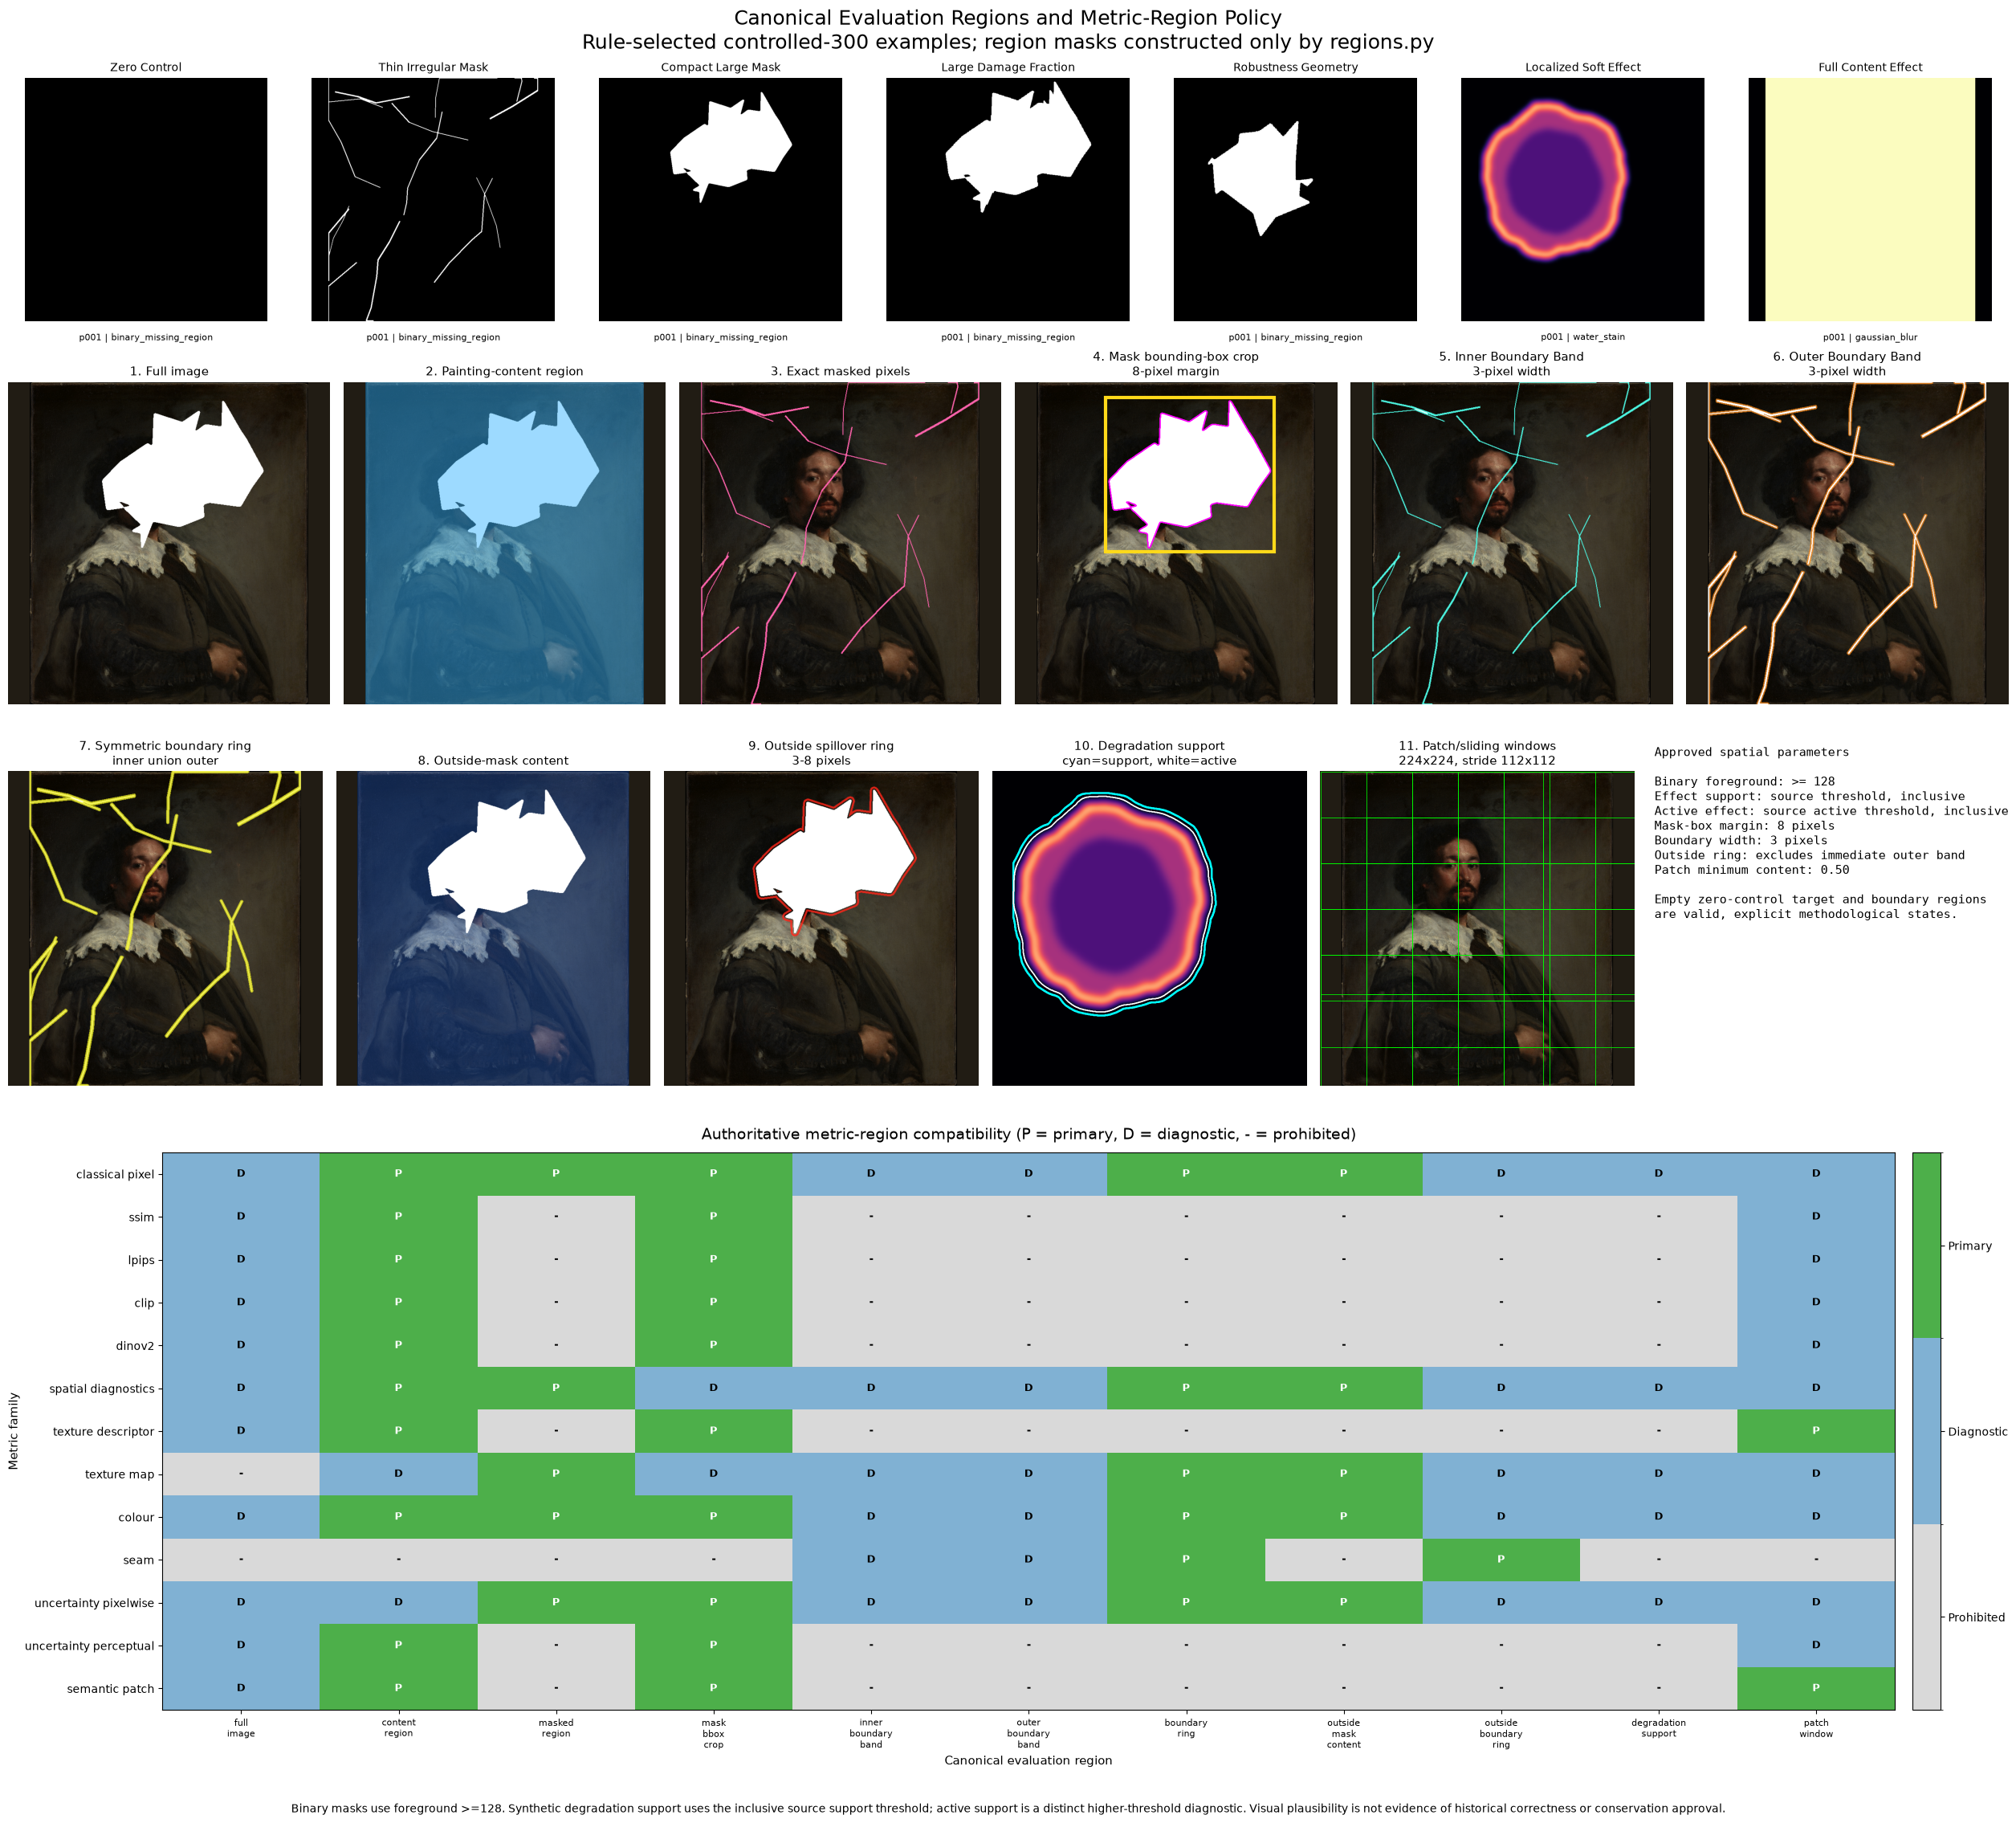

Representative cases rendered: 7
Canonical region identities covered: 11
Patch windows rendered: 36
Figure path: outputs/08_experiment_contracts_and_region_policy/figures/region_definitions.png
Figure format: PNG
Figure mode: RGBA
Figure dimensions: (4082, 3697)


In [22]:
from matplotlib.colors import (
    BoundaryNorm,
    ListedColormap,
)
from matplotlib.patches import Rectangle


# ---------------------------------------------------------------------------
# Canonical Batch 6 paths
# ---------------------------------------------------------------------------

REGION_FIGURE_PATH = OUTPUT_PATHS[
    "region_definitions"
]

EVALUATION_REPORT_PATH = OUTPUT_PATHS[
    "evaluation_contract"
]


# ---------------------------------------------------------------------------
# Representative-case context
# ---------------------------------------------------------------------------

representative_display_df = (
    representative_selection_df
    .merge(
        case_registry_df[
            [
                "case_id",
                "experiment_id",
                "painting_id",
                "damage_or_degradation_type",
                "realized_damage_fraction",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
)

figure_representative_case_ids = (
    representative_display_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

large_case_id = (
    "canonical__p001__loss_large"
)

scratch_case_id = (
    "canonical__p001__scratch_thin"
)

water_case_id = (
    "synthetic_degradation__p001__"
    "water_stain__moderate"
)

zero_control_case_id = (
    "canonical__p001__zero_control"
)

large_payload = (
    representative_region_payloads[
        large_case_id
    ]
)

scratch_payload = (
    representative_region_payloads[
        scratch_case_id
    ]
)

water_payload = (
    representative_region_payloads[
        water_case_id
    ]
)

zero_control_payload = (
    representative_region_payloads[
        zero_control_case_id
    ]
)


# ---------------------------------------------------------------------------
# Presentation-only image helpers
# ---------------------------------------------------------------------------

def load_display_rgb(
    relative_path,
):
    resolved_path = resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(
        resolved_path
    ) as image_handle:
        return np.asarray(
            image_handle.convert(
                "RGB"
            ),
            dtype=np.uint8,
        )


def render_region_overlay(
    base_rgb,
    region_mask,
    colour,
    alpha=0.48,
):
    rendered = (
        base_rgb
        .astype(np.float32)
        / 255.0
    )

    mask = np.asarray(
        region_mask,
        dtype=bool,
    )

    colour_array = np.asarray(
        colour,
        dtype=np.float32,
    )

    rendered[mask] = (
        (
            1.0
            - alpha
        )
        * rendered[mask]
        + alpha
        * colour_array
    )

    return np.clip(
        rendered,
        0.0,
        1.0,
    )


large_input_rgb = load_display_rgb(
    large_payload[
        "case"
    ][
        "input_image_path"
    ]
)

scratch_input_rgb = load_display_rgb(
    scratch_payload[
        "case"
    ][
        "input_image_path"
    ]
)

clean_p001_rgb = load_display_rgb(
    large_payload[
        "case"
    ][
        "clean_image_path"
    ]
)


# ---------------------------------------------------------------------------
# Patch-window visualization for p001
# ---------------------------------------------------------------------------

p001_content_mask = (
    large_payload[
        "regions"
    ][
        "content_region"
    ].mask
)

p001_patch_regions = patch_regions(
    clean_p001_rgb.shape[:2],
    patch_size=PATCH_SIZE,
    stride=PATCH_STRIDE,
    support_mask=p001_content_mask,
    minimum_support_fraction=(
        PATCH_MINIMUM_CONTENT_FRACTION
    ),
)


# ---------------------------------------------------------------------------
# Figure-to-region evidence registry
# ---------------------------------------------------------------------------

figure_region_coverage_df = pd.DataFrame(
    [
        {
            "region_id": "full_image",
            "panel_title": "Full image",
            "source_case_id": large_case_id,
        },
        {
            "region_id": "content_region",
            "panel_title": "Painting-content region",
            "source_case_id": large_case_id,
        },
        {
            "region_id": "masked_region",
            "panel_title": "Exact masked pixels",
            "source_case_id": scratch_case_id,
        },
        {
            "region_id": "mask_bbox_crop",
            "panel_title": "Mask bounding-box crop",
            "source_case_id": large_case_id,
        },
        {
            "region_id": "inner_boundary_band",
            "panel_title": "Inner boundary band",
            "source_case_id": scratch_case_id,
        },
        {
            "region_id": "outer_boundary_band",
            "panel_title": "Outer boundary band",
            "source_case_id": scratch_case_id,
        },
        {
            "region_id": "boundary_ring",
            "panel_title": "Symmetric boundary ring",
            "source_case_id": scratch_case_id,
        },
        {
            "region_id": "outside_mask_content",
            "panel_title": "Outside-mask content",
            "source_case_id": large_case_id,
        },
        {
            "region_id": "outside_boundary_ring",
            "panel_title": "Outside spillover ring",
            "source_case_id": large_case_id,
        },
        {
            "region_id": "degradation_support",
            "panel_title": "Degradation support",
            "source_case_id": water_case_id,
        },
        {
            "region_id": "patch_window",
            "panel_title": "Patch/sliding windows",
            "source_case_id": large_case_id,
        },
    ]
)


# ---------------------------------------------------------------------------
# Three-state metric-region matrix
# ---------------------------------------------------------------------------

ROLE_TO_VALUE = {
    "prohibited": 0,
    "diagnostic": 1,
    "primary": 2,
}

ROLE_TO_SYMBOL = {
    "prohibited": "-",
    "diagnostic": "D",
    "primary": "P",
}

metric_region_role_values_df = (
    metric_region_primary_matrix_df
    .map(
        lambda role: ROLE_TO_VALUE[
            str(role)
        ]
    )
)

metric_region_role_symbols_df = (
    metric_region_primary_matrix_df
    .map(
        lambda role: ROLE_TO_SYMBOL[
            str(role)
        ]
    )
)


# ---------------------------------------------------------------------------
# Render the canonical methodology figure
# ---------------------------------------------------------------------------

region_figure = plt.figure(
    figsize=(
        25,
        22,
    ),
    constrained_layout=True,
)

outer_grid = (
    region_figure
    .add_gridspec(
        4,
        1,
        height_ratios=[
            0.85,
            1.15,
            1.15,
            1.65,
        ],
    )
)

representative_grid = (
    outer_grid[0]
    .subgridspec(
        1,
        7,
        wspace=0.04,
    )
)

definition_grid_1 = (
    outer_grid[1]
    .subgridspec(
        1,
        6,
        wspace=0.04,
    )
)

definition_grid_2 = (
    outer_grid[2]
    .subgridspec(
        1,
        6,
        wspace=0.04,
    )
)

representative_axes = [
    region_figure.add_subplot(
        representative_grid[
            0,
            index,
        ]
    )
    for index in range(7)
]

definition_axes_1 = [
    region_figure.add_subplot(
        definition_grid_1[
            0,
            index,
        ]
    )
    for index in range(6)
]

definition_axes_2 = [
    region_figure.add_subplot(
        definition_grid_2[
            0,
            index,
        ]
    )
    for index in range(6)
]

policy_axis = (
    region_figure
    .add_subplot(
        outer_grid[3]
    )
)


# ---------------------------------------------------------------------------
# Top row: all seven rule-selected cases
# ---------------------------------------------------------------------------

for axis, representative_row in zip(
    representative_axes,
    representative_display_df
    .to_dict(
        orient="records"
    ),
):
    case_id = str(
        representative_row[
            "case_id"
        ]
    )

    payload = (
        representative_region_payloads[
            case_id
        ]
    )

    mask_gray = payload[
        "mask_gray"
    ]

    if (
        payload[
            "mask_semantics"
        ]
        == "grayscale_effect_support"
    ):
        axis.imshow(
            mask_gray,
            cmap="magma",
            vmin=0,
            vmax=255,
        )
    else:
        axis.imshow(
            mask_gray,
            cmap="gray",
            vmin=0,
            vmax=255,
        )

    axis.set_title(
        representative_row[
            "selection_role"
        ]
        .replace(
            "_",
            " ",
        )
        .title(),
        fontsize=10,
    )

    axis.text(
        0.5,
        -0.05,
        (
            f'{representative_row["painting_id"]} | '
            f'{representative_row["damage_or_degradation_type"]}'
        ),
        transform=axis.transAxes,
        ha="center",
        va="top",
        fontsize=8,
    )

    axis.axis(
        "off"
    )


# ---------------------------------------------------------------------------
# Region-definition panels
# ---------------------------------------------------------------------------

region_colours = {
    "content_region": (
        0.20,
        0.70,
        1.00,
    ),
    "masked_region": (
        1.00,
        0.15,
        0.55,
    ),
    "mask_bbox_crop": (
        1.00,
        0.85,
        0.10,
    ),
    "inner_boundary_band": (
        0.10,
        0.95,
        0.85,
    ),
    "outer_boundary_band": (
        1.00,
        0.55,
        0.10,
    ),
    "boundary_ring": (
        0.95,
        0.95,
        0.15,
    ),
    "outside_mask_content": (
        0.15,
        0.45,
        1.00,
    ),
    "outside_boundary_ring": (
        1.00,
        0.15,
        0.10,
    ),
}

definition_axes_1[0].imshow(
    large_input_rgb
)

definition_axes_1[0].set_title(
    "1. Full image",
    fontsize=11,
)

definition_axes_1[0].axis(
    "off"
)

definition_axes_1[1].imshow(
    render_region_overlay(
        large_input_rgb,
        large_payload[
            "regions"
        ][
            "content_region"
        ].mask,
        region_colours[
            "content_region"
        ],
    )
)

definition_axes_1[1].set_title(
    "2. Painting-content region",
    fontsize=11,
)

definition_axes_1[1].axis(
    "off"
)

definition_axes_1[2].imshow(
    render_region_overlay(
        scratch_input_rgb,
        scratch_payload[
            "regions"
        ][
            "masked_region"
        ].mask,
        region_colours[
            "masked_region"
        ],
        alpha=0.72,
    )
)

definition_axes_1[2].set_title(
    "3. Exact masked pixels",
    fontsize=11,
)

definition_axes_1[2].axis(
    "off"
)

definition_axes_1[3].imshow(
    large_input_rgb
)

large_bbox = (
    large_payload[
        "regions"
    ][
        "mask_bbox_crop"
    ].bbox
)

if large_bbox is not None:
    (
        bbox_x_min,
        bbox_y_min,
        bbox_x_max,
        bbox_y_max,
    ) = large_bbox

    definition_axes_1[3].add_patch(
        Rectangle(
            (
                bbox_x_min,
                bbox_y_min,
            ),
            (
                bbox_x_max
                - bbox_x_min
            ),
            (
                bbox_y_max
                - bbox_y_min
            ),
            fill=False,
            edgecolor=(
                region_colours[
                    "mask_bbox_crop"
                ]
            ),
            linewidth=3,
        )
    )

definition_axes_1[3].contour(
    large_payload[
        "regions"
    ][
        "masked_region"
    ].mask.astype(float),
    levels=[
        0.5,
    ],
    colors=[
        "magenta",
    ],
    linewidths=1.2,
)

definition_axes_1[3].set_title(
    (
        "4. Mask bounding-box crop\n"
        f"{MASK_BBOX_MARGIN_PIXELS}-pixel margin"
    ),
    fontsize=11,
)

definition_axes_1[3].axis(
    "off"
)

for axis, region_id, panel_number in [
    (
        definition_axes_1[4],
        "inner_boundary_band",
        5,
    ),
    (
        definition_axes_1[5],
        "outer_boundary_band",
        6,
    ),
]:
    axis.imshow(
        render_region_overlay(
            scratch_input_rgb,
            scratch_payload[
                "regions"
            ][
                region_id
            ].mask,
            region_colours[
                region_id
            ],
            alpha=0.78,
        )
    )

    axis.set_title(
        (
            f"{panel_number}. "
            f"{region_id.replace('_', ' ').title()}\n"
            f"{BOUNDARY_WIDTH_PIXELS}-pixel width"
        ),
        fontsize=11,
    )

    axis.axis(
        "off"
    )

definition_axes_2[0].imshow(
    render_region_overlay(
        scratch_input_rgb,
        scratch_payload[
            "regions"
        ][
            "boundary_ring"
        ].mask,
        region_colours[
            "boundary_ring"
        ],
        alpha=0.78,
    )
)

definition_axes_2[0].set_title(
    (
        "7. Symmetric boundary ring\n"
        "inner union outer"
    ),
    fontsize=11,
)

definition_axes_2[0].axis(
    "off"
)

definition_axes_2[1].imshow(
    render_region_overlay(
        large_input_rgb,
        large_payload[
            "regions"
        ][
            "outside_mask_content"
        ].mask,
        region_colours[
            "outside_mask_content"
        ],
        alpha=0.30,
    )
)

definition_axes_2[1].set_title(
    "8. Outside-mask content",
    fontsize=11,
)

definition_axes_2[1].axis(
    "off"
)

definition_axes_2[2].imshow(
    render_region_overlay(
        large_input_rgb,
        large_payload[
            "regions"
        ][
            "outside_boundary_ring"
        ].mask,
        region_colours[
            "outside_boundary_ring"
        ],
        alpha=0.82,
    )
)

definition_axes_2[2].set_title(
    (
        "9. Outside spillover ring\n"
        f"{BOUNDARY_WIDTH_PIXELS}-"
        f"{OUTSIDE_RING_WIDTH_PIXELS} pixels"
    ),
    fontsize=11,
)

definition_axes_2[2].axis(
    "off"
)

degradation_axis = (
    definition_axes_2[3]
)

degradation_axis.imshow(
    water_payload[
        "mask_gray"
    ],
    cmap="magma",
    vmin=0,
    vmax=255,
)

degradation_axis.contour(
    water_payload[
        "evaluation_mask"
    ].astype(float),
    levels=[
        0.5,
    ],
    colors=[
        "cyan",
    ],
    linewidths=1.8,
)

degradation_axis.contour(
    water_payload[
        "active_mask"
    ].astype(float),
    levels=[
        0.5,
    ],
    colors=[
        "white",
    ],
    linewidths=1.2,
)

degradation_axis.set_title(
    (
        "10. Degradation support\n"
        "cyan=support, white=active"
    ),
    fontsize=11,
)

degradation_axis.axis(
    "off"
)

patch_axis = (
    definition_axes_2[4]
)

patch_axis.imshow(
    clean_p001_rgb
)

for patch_region in (
    p001_patch_regions
):
    if patch_region.bbox is None:
        continue

    (
        patch_x_min,
        patch_y_min,
        patch_x_max,
        patch_y_max,
    ) = patch_region.bbox

    patch_axis.add_patch(
        Rectangle(
            (
                patch_x_min,
                patch_y_min,
            ),
            (
                patch_x_max
                - patch_x_min
            ),
            (
                patch_y_max
                - patch_y_min
            ),
            fill=False,
            edgecolor="lime",
            linewidth=0.65,
            alpha=0.85,
        )
    )

patch_axis.set_title(
    (
        "11. Patch/sliding windows\n"
        f"{PATCH_SIZE[1]}x{PATCH_SIZE[0]}, "
        f"stride {PATCH_STRIDE[1]}x{PATCH_STRIDE[0]}"
    ),
    fontsize=11,
)

patch_axis.axis(
    "off"
)

parameter_axis = (
    definition_axes_2[5]
)

parameter_axis.axis(
    "off"
)

parameter_axis.text(
    0.02,
    0.98,
    (
        "Approved spatial parameters\n\n"
        f"Binary foreground: >= {BINARY_MASK_THRESHOLD}\n"
        "Effect support: source threshold, inclusive\n"
        "Active effect: source active threshold, inclusive\n"
        f"Mask-box margin: {MASK_BBOX_MARGIN_PIXELS} pixels\n"
        f"Boundary width: {BOUNDARY_WIDTH_PIXELS} pixels\n"
        "Outside ring: excludes immediate outer band\n"
        f"Patch minimum content: "
        f"{PATCH_MINIMUM_CONTENT_FRACTION:.2f}\n\n"
        "Empty zero-control target and boundary regions\n"
        "are valid, explicit methodological states."
    ),
    ha="left",
    va="top",
    fontsize=11,
    family="monospace",
)


# ---------------------------------------------------------------------------
# Metric-region policy matrix
# ---------------------------------------------------------------------------

policy_colourmap = ListedColormap(
    [
        "#d9d9d9",
        "#80b1d3",
        "#4daf4a",
    ]
)

policy_norm = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5,
        2.5,
    ],
    policy_colourmap.N,
)

policy_image = policy_axis.imshow(
    metric_region_role_values_df.to_numpy(
        dtype=float
    ),
    aspect="auto",
    cmap=policy_colourmap,
    norm=policy_norm,
)

policy_axis.set_xticks(
    range(
        len(
            configured_region_ids
        )
    ),
    labels=[
        region_id.replace(
            "_",
            "\n",
        )
        for region_id
        in configured_region_ids
    ],
    fontsize=8,
)

policy_axis.set_yticks(
    range(
        len(
            configured_metric_families
        )
    ),
    labels=[
        metric_family.replace(
            "_",
            " ",
        )
        for metric_family
        in configured_metric_families
    ],
    fontsize=10,
)

for row_index in range(
    len(
        configured_metric_families
    )
):
    for column_index in range(
        len(
            configured_region_ids
        )
    ):
        policy_axis.text(
            column_index,
            row_index,
            metric_region_role_symbols_df.iloc[
                row_index,
                column_index,
            ],
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=(
                "white"
                if metric_region_role_values_df.iloc[
                    row_index,
                    column_index,
                ]
                == 2
                else "black"
            ),
        )

policy_axis.set_title(
    (
        "Authoritative metric-region compatibility "
        "(P = primary, D = diagnostic, - = prohibited)"
    ),
    fontsize=14,
    pad=12,
)

policy_axis.set_xlabel(
    "Canonical evaluation region",
    fontsize=11,
)

policy_axis.set_ylabel(
    "Metric family",
    fontsize=11,
)

policy_colourbar = (
    region_figure.colorbar(
        policy_image,
        ax=policy_axis,
        ticks=[
            0,
            1,
            2,
        ],
        fraction=0.018,
        pad=0.01,
    )
)

policy_colourbar.ax.set_yticklabels(
    [
        "Prohibited",
        "Diagnostic",
        "Primary",
    ]
)

region_figure.suptitle(
    (
        "Canonical Evaluation Regions and "
        "Metric-Region Policy\n"
        "Rule-selected controlled-300 examples; "
        "region masks constructed only by regions.py"
    ),
    fontsize=18,
)

region_figure.text(
    0.5,
    -0.025,
    (
        "Binary masks use foreground >=128. "
        "Synthetic degradation support uses the inclusive "
        "source support threshold; active support is a distinct "
        "higher-threshold diagnostic. Visual plausibility is not "
        "evidence of historical correctness or conservation approval."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
)


# ---------------------------------------------------------------------------
# Atomically persist and reload the canonical figure
# ---------------------------------------------------------------------------

import gc
import time

REGION_FIGURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

region_figure_staging_path = (
    REGION_FIGURE_PATH
    .with_name(
        (
            f"{REGION_FIGURE_PATH.stem}"
            f".staging{REGION_FIGURE_PATH.suffix}"
        )
    )
)

legacy_region_figure_temporary_path = (
    REGION_FIGURE_PATH
    .with_name(
        (
            f"{REGION_FIGURE_PATH.stem}"
            f".tmp{REGION_FIGURE_PATH.suffix}"
        )
    )
)

region_figure.savefig(
    region_figure_staging_path,
    dpi=160,
    pad_inches=0.30,
    bbox_inches="tight",
    facecolor="white",
)

# Render before closing the Matplotlib figure manager.
plt.show()

# Release Matplotlib/Pillow file handles before the Windows rename.
plt.close(
    region_figure
)

gc.collect()

# Retry the atomic replacement because Windows indexing or antivirus
# may hold a newly written PNG briefly.
for replacement_attempt in range(8):
    try:
        region_figure_staging_path.replace(
            REGION_FIGURE_PATH
        )
        break
    except PermissionError:
        if replacement_attempt == 7:
            raise

        time.sleep(
            0.25
        )

# Remove the temporary PNG left by the earlier interrupted execution.
if (
    legacy_region_figure_temporary_path.exists()
):
    for cleanup_attempt in range(8):
        try:
            legacy_region_figure_temporary_path.unlink()
            break
        except PermissionError:
            if cleanup_attempt == 7:
                raise

            gc.collect()

            time.sleep(
                0.25
            )

with Image.open(
    REGION_FIGURE_PATH
) as region_figure_handle:
    region_figure_format = (
        region_figure_handle.format
    )

    region_figure_mode = (
        region_figure_handle.mode
    )

    region_figure_dimensions = (
        region_figure_handle.size
    )

region_figure_sha256 = sha256_file(
    REGION_FIGURE_PATH
)

print(
    "Representative cases rendered:",
    len(
        figure_representative_case_ids
    ),
)

print(
    "Canonical region identities covered:",
    len(
        figure_region_coverage_df
    ),
)

print(
    "Patch windows rendered:",
    len(
        p001_patch_regions
    ),
)

print(
    "Figure path:",
    to_repo_relative(
        REGION_FIGURE_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Figure format:",
    region_figure_format,
)

print(
    "Figure mode:",
    region_figure_mode,
)

print(
    "Figure dimensions:",
    region_figure_dimensions,
)

In [23]:
# ---------------------------------------------------------------------------
# Compact report tables
# ---------------------------------------------------------------------------

eligibility_semantics_df = (
    model_eligibility_df
    .groupby(
        [
            "eligible",
            "input_semantics",
            "mask_semantics",
            "restoration_objective",
        ],
        as_index=False,
    )
    .agg(
        decision_count=(
            "case_id",
            "size",
        ),
        model_count=(
            "model_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "eligible",
            "decision_count",
        ],
        ascending=[
            False,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

synthetic_policy_report_df = (
    synthetic_family_policy_df[
        [
            "degradation_family",
            "source_case_count",
            "expected_eligible",
            "policy_group",
            "configured_reason",
        ]
    ]
    .copy()
)

region_report_df = (
    region_parameter_summary_df[
        [
            "region_id",
            "region_type",
            "spatial_support",
            "case_semantics",
            "parameters_json",
            "threshold_policy",
        ]
    ]
    .copy()
)

metric_policy_report_df = (
    metric_family_policy_summary_df[
        [
            "metric_family",
            "compatible_regions",
            "primary_regions",
            "diagnostic_regions",
            "prohibited_regions",
        ]
    ]
    .copy()
)

representative_report_df = (
    representative_display_df[
        [
            "case_id",
            "selection_role",
            "selection_rule",
            "experiment_id",
            "painting_id",
            "damage_or_degradation_type",
            "realized_damage_fraction",
        ]
    ]
    .copy()
)

report_output_contract_df = (
    OUTPUT_CONTRACT[
        [
            "output_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "downstream_consumers",
        ]
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Build the canonical methodological report
# ---------------------------------------------------------------------------

evaluation_report_text = f"""# Evaluation Contract and Region Policy

## Status and scope

- Notebook: `{NOTEBOOK_STEM}`
- Dataset: `{evaluation_config["dataset"]["dataset_id"]}`
- Dataset version: `{evaluation_config["dataset"]["dataset_version"]}`
- Dataset scope: `{evaluation_config["dataset"]["dataset_scope"]}`
- Contract configuration: `{evaluation_config["config_schema_version"]}`
- Contract version: `{evaluation_config["config_version"]}`
- Eligibility policy: `{evaluation_config["eligibility"]["policy_version"]}`
- Region policy: `{evaluation_config["regions"]["policy_version"]}`
- Experiment-contract helper: `{EXPERIMENT_CONTRACTS_MODULE_VERSION}`
- Canonical-region helper: `{REGIONS_MODULE_VERSION}`
- Normalized cases: `{len(case_registry_df)}`
- Model decisions: `{len(model_eligibility_df)}`
- Metric-region decisions: `{len(region_policy_df)}`

This report defines the authoritative experimental routing and spatial
evaluation contract for Notebooks 09-36, including Notebook 12A.

## Interpretation boundary

Visual plausibility is not equivalent to historical correctness,
conservation approval, or restoration trustworthiness.

The framework evaluates algorithmic outputs under controlled synthetic
missing-region damage and controlled procedural degradation. It does
not certify a restoration for conservation use, infer artist intent,
establish historical authenticity, or replace expert human review.

No universal trust score is defined. Reference fidelity, perceptual
similarity, feature-space consistency, texture, colour, seam,
outside-mask alteration, semantic evidence, and uncertainty remain
distinct forms of evidence.

## Normalized case registry

The registry contains only stable cross-experiment identifiers, paths,
core case semantics, damage/effect fractions, source-manifest lineage,
and status. Experiment-specific generation details remain in their
source tables.

Every accepted case traces to exactly one immediate source run manifest.

{case_registry_experiment_summary_df.to_markdown(index=False)}

The normalized registry contains:

- {len(binary_registry_df):,} binary missing-region cases;
- {len(degradation_registry_df):,} synthetic-degradation cases;
- {expected_canonical_zero_controls:,} canonical zero controls;
- {len(case_registry_df):,} unique case identifiers;
- repository-relative clean, input, and mask/effect paths.

Zero controls are explicit identity/no-op controls. Empty target,
bounding-box, and boundary regions are valid expected states for these
cases rather than missing data.

## Model eligibility and restoration semantics

Methodological eligibility is recorded independently for every
`(case_id, model_id)` combination. Runtime availability, installed
weights, hardware availability, execution success, and model
feasibility are separate from methodological eligibility.

{model_eligibility_summary_df.to_markdown(index=False)}

The eligibility table contains one explicit decision for each of
{EXPECTED_COUNTS["model_count"]} model identities and each of
{len(case_registry_df):,} cases.

SDXL remains a bounded 35-case feasibility study even though its
methodological eligibility is recorded across the complete registry.
HINT is the selected additional learned method intended for full
eligible-population execution.

{eligibility_semantics_df.to_markdown(index=False)}

All binary missing-region cases are eligible for inpainting evaluation.
For non-binary synthetic degradations, only localized water stain, dirt
and dust, partial transparency, and combined water stain/dirt cases are
eligible for supplementary masked-removal diagnostics.

That supplementary objective is not a physical conservation treatment
and must not be presented as one.

{synthetic_policy_report_df.to_markdown(index=False)}

Ineligible cases remain in the eligibility table with explicit reasons;
they are not silently discarded.

## Canonical region definitions

All spatial regions are constructed by the single authoritative
`src/restoration_eval/regions.py` helper.

{region_report_df.to_markdown(index=False)}

The approved spatial parameters are:

- binary mask foreground: values greater than or equal to
  `{BINARY_MASK_THRESHOLD}`;
- mask bounding-box margin: `{MASK_BBOX_MARGIN_PIXELS}` pixels;
- inner boundary width: `{BOUNDARY_WIDTH_PIXELS}` pixels;
- outer boundary width: `{BOUNDARY_WIDTH_PIXELS}` pixels;
- symmetric boundary ring: union of the disjoint inner and outer bands;
- outside spillover ring: pixels from
  `{BOUNDARY_WIDTH_PIXELS}` through
  `{OUTSIDE_RING_WIDTH_PIXELS}` pixels outside the mask, excluding the
  immediate outer band;
- patch size: `{PATCH_SIZE[1]} x {PATCH_SIZE[0]}`;
- patch stride: `{PATCH_STRIDE[1]} x {PATCH_STRIDE[0]}`;
- minimum patch content fraction:
  `{PATCH_MINIMUM_CONTENT_FRACTION:.2f}`;
- mask crops, boundaries, outside-mask regions, and patch support are
  clipped to permitted painting-content support.

For synthetic degradations, effect support and active support are
distinct:

1. degradation support uses the inclusive source
   `support_threshold`;
2. active support uses the inclusive source `active_threshold`;
3. active support must remain inside degradation support;
4. the grayscale effect mask remains an operator-influence record, not
   a physical conservation annotation.

## Representative validation

The region helper was applied to all {len(case_registry_df):,}
normalized cases. This created {len(region_records_df):,} applicable
case-region records:

- nine standard regions for every case;
- one additional degradation-support region for each of the
  {len(degradation_registry_df):,} synthetic-degradation cases.

The patch-window contract was additionally validated on the balanced
{len(patch_audit_df)}-painting focused-experiment cohort.

The methodology figure uses the following cases selected before
rendering:

{representative_report_df.to_markdown(index=False)}

The selection rules are explicit to reduce cherry-picking. The figure
also displays the complete 13-by-11 metric-region policy.

## Metric-region compatibility

Every combination of 13 metric families and 11 canonical region
identities is retained as an explicit primary, diagnostic, or
prohibited decision.

{metric_policy_report_df.to_markdown(index=False)}

The compact matrix below uses `P` for primary, `D` for diagnostic, and
`-` for prohibited.

{metric_region_role_symbols_df.to_markdown()}

### Refined local comparison policy

{refined_local_policy_df.to_markdown(index=False)}

The refined local comparison therefore uses:

- exact masked pixels for local MAE, MSE, PSNR, and related pixelwise
  diagnostics;
- mask bounding-box crops for SSIM, LPIPS, CLIP, and DINOv2;
- immediate boundary rings and outside spillover rings for seam
  diagnostics;
- outside-mask content for unintended-edit diagnostics.

Sparse masked-pixel SSIM is prohibited. SSIM requires an image-like
rectangular support and must not be computed on flattened or sparse
masked pixels merely to populate a result column.

The same image-like restriction applies to LPIPS, CLIP, DINOv2,
texture descriptors, perceptual uncertainty, and semantic patch
metrics where configured.

## Notebook 28 region-policy alternatives

Notebook 28 receives seven declared alternatives for region ablation.
An ablation never makes a mathematically incompatible metric-region
combination valid.

{ablation_policy_summary_df.to_markdown(index=False)}

The complete approved policy preserves all eleven canonical region
identities. Restricted ablations change spatial scope transparently
without creating a universal trust score.

## Input contract

{INPUT_CONTRACT.to_markdown(index=False)}

## Output and downstream contract

{report_output_contract_df.to_markdown(index=False)}

Downstream notebooks must consume the declared normalized artifacts
rather than scanning folders for plausible files.

Restoration notebooks must:

1. join cases by stable `case_id`;
2. join routing decisions by `(case_id, model_id)`;
3. skip ineligible execution routes with the recorded reason;
4. preserve zero controls as identity/no-op controls;
5. keep synthetic-degradation diagnostics distinct from missing-content
   restoration claims;
6. record runtime availability separately from methodological
   eligibility.

Metric notebooks must:

1. join the policy by `(metric_family, region_id)`;
2. reject prohibited combinations;
3. preserve region identifiers and threshold semantics;
4. use image-like rectangular support where required;
5. avoid reconstructing region masks with notebook-local logic.

## Validation evidence

Before this report was written:

- {len(case_registry_df):,} cases passed registry and path validation;
- {len(model_eligibility_df):,} model decisions passed schema and
  routing validation;
- {len(region_policy_df):,} metric-region decisions passed
  compatibility validation;
- all {len(region_case_audit_df):,} mask/effect files were reloaded
  with canonical geometry;
- all exact support remained inside painting content;
- all mask crops remained inside content and contained their masks;
- all inner, outer, symmetric, and spillover relationships passed;
- all {len(patch_audit_df)} patch-cohort paintings produced valid
  deterministic windows;
- all seven rule-selected representative payloads were available;
- {len(validation_checks_through_batch_5_df)} cumulative blocking
  checks had passed.

The normalized tables and consolidated validation evidence are
persisted and independently reloaded in Batch 7.

## Limitations

1. Region geometry is algorithmically defined and is not expert
   conservation annotation.
2. Boundary width, crop margin, effect thresholds, patch size, and
   stride are declared analysis parameters rather than physical
   properties of a painting.
3. Synthetic missing regions and procedural degradations simplify
   real deterioration processes.
4. A model being methodologically eligible does not mean that its
   runtime is available or that its result will be trustworthy.
5. Supplementary degradation inpainting does not represent a physical
   conservation intervention.
6. Pixelwise, perceptual, feature, texture, colour, seam, semantic, and
   uncertainty metrics each expose limited evidence.
7. Metric agreement does not establish historical correctness.
8. Metric disagreement must remain visible rather than being hidden by
   a universal aggregate score.
9. The controlled-300 dataset and balanced 35-painting focused subsets
   do not represent the full distribution of artists, periods,
   materials, techniques, or conservation conditions.
10. Human conservation review remains necessary for real-world
    interpretation.

## Methodological conclusion

This contract separates case identity, methodological model routing,
spatial support, and metric compatibility into explicit normalized
handoffs. It prevents invalid restoration routes and prohibited
metric-region computations from being inferred implicitly by later
notebooks.

Visual plausibility remains evidence for inspection, not evidence of
historical or restoration trustworthiness.
"""


# ---------------------------------------------------------------------------
# Atomically persist and inspect the report
# ---------------------------------------------------------------------------

EVALUATION_REPORT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

evaluation_report_temporary_path = (
    EVALUATION_REPORT_PATH
    .with_name(
        (
            f"{EVALUATION_REPORT_PATH.name}"
            ".tmp"
        )
    )
)

evaluation_report_temporary_path.write_text(
    evaluation_report_text,
    encoding="utf-8",
)

evaluation_report_temporary_path.replace(
    EVALUATION_REPORT_PATH
)

evaluation_report_reloaded_text = (
    EVALUATION_REPORT_PATH
    .read_text(
        encoding="utf-8"
    )
)

evaluation_report_sha256 = sha256_file(
    EVALUATION_REPORT_PATH
)

report_required_headings = [
    "## Interpretation boundary",
    "## Normalized case registry",
    "## Model eligibility and restoration semantics",
    "## Canonical region definitions",
    "## Metric-region compatibility",
    "## Notebook 28 region-policy alternatives",
    "## Input contract",
    "## Output and downstream contract",
    "## Validation evidence",
    "## Limitations",
]

missing_report_headings = [
    heading
    for heading in report_required_headings
    if heading
    not in evaluation_report_reloaded_text
]

report_required_phrases = [
    "Visual plausibility is not equivalent",
    "Runtime availability",
    "not a physical conservation treatment",
    "effect support and active support are distinct",
    "Sparse masked-pixel SSIM is prohibited",
    "No universal trust score",
    "Notebook 28",
    "Human conservation review",
    "regions.py",
    "Notebooks 09-36",
]

normalized_evaluation_report_search_text = (
    " ".join(
        evaluation_report_reloaded_text
        .lower()
        .split()
    )
)

missing_report_phrases = [
    phrase
    for phrase in report_required_phrases
    if (
        " ".join(
            phrase
            .lower()
            .split()
        )
        not in normalized_evaluation_report_search_text
    )
]

print(
    "Evaluation report path:",
    to_repo_relative(
        EVALUATION_REPORT_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Evaluation report characters:",
    len(
        evaluation_report_reloaded_text
    ),
)

print(
    "Missing required headings:",
    missing_report_headings,
)

print(
    "Missing required phrases:",
    missing_report_phrases,
)

Evaluation report path: outputs/08_experiment_contracts_and_region_policy/reports/evaluation_contract.md
Evaluation report characters: 37603
Missing required headings: []
Missing required phrases: []


In [24]:
# ---------------------------------------------------------------------------
# Rebuild cumulative validation for safe Batch 6 reruns
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()

for validation_record in (
    validation_checks_through_batch_5_df
    .to_dict(
        orient="records"
    )
):
    VALIDATION.add(
        **validation_record
    )


BATCH_6_STAGE = (
    "batch_6_analysis_visualization_report"
)


def add_batch_6_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_6_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Analysis inputs remain complete
# ---------------------------------------------------------------------------

add_batch_6_check(
    check_id="analysis_contract_cardinalities",
    description=(
        "The visualization and report use the complete validated "
        "case, eligibility, and region-policy tables."
    ),
    expected={
        "cases": EXPECTED_COUNTS[
            "case_registry_rows"
        ],
        "eligibility_decisions": EXPECTED_COUNTS[
            "model_eligibility_rows"
        ],
        "policy_rows": EXPECTED_COUNTS[
            "region_policy_rows"
        ],
    },
    observed={
        "cases": len(
            case_registry_df
        ),
        "eligibility_decisions": len(
            model_eligibility_df
        ),
        "policy_rows": len(
            region_policy_df
        ),
    },
    passed=(
        len(case_registry_df)
        == EXPECTED_COUNTS[
            "case_registry_rows"
        ]
        and len(model_eligibility_df)
        == EXPECTED_COUNTS[
            "model_eligibility_rows"
        ]
        and len(region_policy_df)
        == EXPECTED_COUNTS[
            "region_policy_rows"
        ]
    ),
)


# ---------------------------------------------------------------------------
# 2. All representative selections are rendered
# ---------------------------------------------------------------------------

missing_figure_representatives = sorted(
    set(
        representative_selection_df[
            "case_id"
        ].astype(str)
    )
    - set(
        figure_representative_case_ids
    )
)

add_batch_6_check(
    check_id="representative_visual_coverage",
    description=(
        "All seven deterministically selected representative "
        "cases are included in the methodology figure."
    ),
    expected={
        "selected_cases": 7,
        "missing_cases": 0,
    },
    observed={
        "selected_cases": len(
            figure_representative_case_ids
        ),
        "missing_cases": len(
            missing_figure_representatives
        ),
    },
    passed=(
        len(
            figure_representative_case_ids
        )
        == 7
        and not missing_figure_representatives
    ),
    details=missing_figure_representatives,
)


# ---------------------------------------------------------------------------
# 3. All eleven region identities are visualized
# ---------------------------------------------------------------------------

observed_figure_region_ids = set(
    figure_region_coverage_df[
        "region_id"
    ].astype(str)
)

expected_figure_region_ids = set(
    configured_region_ids
)

add_batch_6_check(
    check_id="canonical_region_figure_coverage",
    description=(
        "The canonical figure explicitly covers all eleven "
        "configured region identities."
    ),
    expected=sorted(
        expected_figure_region_ids
    ),
    observed=sorted(
        observed_figure_region_ids
    ),
    passed=(
        len(
            figure_region_coverage_df
        )
        == 11
        and observed_figure_region_ids
        == expected_figure_region_ids
    ),
)


# ---------------------------------------------------------------------------
# 4. Complete three-state metric-region matrix
# ---------------------------------------------------------------------------

observed_policy_values = sorted(
    set(
        metric_region_role_values_df
        .to_numpy()
        .ravel()
        .tolist()
    )
)

add_batch_6_check(
    check_id="metric_policy_visualization",
    description=(
        "The figure contains the complete 13-by-11 primary, "
        "diagnostic, and prohibited policy matrix."
    ),
    expected={
        "shape": [
            13,
            11,
        ],
        "values": [
            0,
            1,
            2,
        ],
        "missing_values": 0,
    },
    observed={
        "shape": list(
            metric_region_role_values_df.shape
        ),
        "values": (
            observed_policy_values
        ),
        "missing_values": int(
            metric_region_role_values_df
            .isna()
            .sum()
            .sum()
        ),
    },
    passed=(
        metric_region_role_values_df.shape
        == (
            13,
            11,
        )
        and observed_policy_values
        == [
            0,
            1,
            2,
        ]
        and not metric_region_role_values_df
        .isna()
        .any()
        .any()
    ),
)


# ---------------------------------------------------------------------------
# 5. Canonical figure artifact
# ---------------------------------------------------------------------------

add_batch_6_check(
    check_id="region_definition_figure",
    description=(
        "The canonical region figure exists, reloads as a "
        "high-resolution PNG, and belongs to Notebook 08."
    ),
    expected={
        "exists": True,
        "format": "PNG",
        "minimum_width": 3000,
        "minimum_height": 3000,
        "inside_output_root": True,
    },
    observed={
        "exists": (
            REGION_FIGURE_PATH.is_file()
        ),
        "format": (
            region_figure_format
        ),
        "mode": (
            region_figure_mode
        ),
        "dimensions": (
            region_figure_dimensions
        ),
        "size_bytes": int(
            REGION_FIGURE_PATH
            .stat()
            .st_size
        ),
        "inside_output_root": (
            REGION_FIGURE_PATH
            .resolve()
            .is_relative_to(
                OUTPUT_ROOT.resolve()
            )
        ),
    },
    passed=(
        REGION_FIGURE_PATH.is_file()
        and REGION_FIGURE_PATH
        .stat()
        .st_size
        > 0
        and region_figure_format
        == "PNG"
        and region_figure_dimensions[0]
        >= 3000
        and region_figure_dimensions[1]
        >= 3000
        and REGION_FIGURE_PATH
        .resolve()
        .is_relative_to(
            OUTPUT_ROOT.resolve()
        )
    ),
)


# ---------------------------------------------------------------------------
# 6. Evaluation-contract report artifact
# ---------------------------------------------------------------------------

add_batch_6_check(
    check_id="evaluation_contract_report",
    description=(
        "The canonical report exists, reloads exactly, is "
        "substantive, and belongs to Notebook 08."
    ),
    expected={
        "exists": True,
        "minimum_characters": 5000,
        "reload_matches": True,
        "inside_output_root": True,
    },
    observed={
        "exists": (
            EVALUATION_REPORT_PATH.is_file()
        ),
        "characters": len(
            evaluation_report_reloaded_text
        ),
        "reload_matches": (
            evaluation_report_reloaded_text
            == evaluation_report_text
        ),
        "inside_output_root": (
            EVALUATION_REPORT_PATH
            .resolve()
            .is_relative_to(
                OUTPUT_ROOT.resolve()
            )
        ),
    },
    passed=(
        EVALUATION_REPORT_PATH.is_file()
        and len(
            evaluation_report_reloaded_text
        )
        >= 5000
        and evaluation_report_reloaded_text
        == evaluation_report_text
        and EVALUATION_REPORT_PATH
        .resolve()
        .is_relative_to(
            OUTPUT_ROOT.resolve()
        )
    ),
)


# ---------------------------------------------------------------------------
# 7. Required methodological report content
# ---------------------------------------------------------------------------

add_batch_6_check(
    check_id="evaluation_report_content",
    description=(
        "The report contains every required section and "
        "methodological interpretation boundary."
    ),
    expected={
        "missing_headings": 0,
        "missing_phrases": 0,
    },
    observed={
        "missing_headings": len(
            missing_report_headings
        ),
        "missing_phrases": len(
            missing_report_phrases
        ),
    },
    passed=(
        not missing_report_headings
        and not missing_report_phrases
    ),
    details={
        "missing_headings": (
            missing_report_headings
        ),
        "missing_phrases": (
            missing_report_phrases
        ),
    },
)


# ---------------------------------------------------------------------------
# 8. Artifact hashes and ownership
# ---------------------------------------------------------------------------

batch_6_hashes_valid = bool(
    len(
        region_figure_sha256
    )
    == 64
    and len(
        evaluation_report_sha256
    )
    == 64
)

add_batch_6_check(
    check_id="batch_6_artifact_identity",
    description=(
        "Both Batch 6 artifacts have SHA-256 identities and "
        "resolve inside the exact Notebook 08 output root."
    ),
    expected={
        "valid_hashes": True,
        "owned_artifacts": 2,
    },
    observed={
        "valid_hashes": (
            batch_6_hashes_valid
        ),
        "owned_artifacts": int(
            sum(
                path.resolve().is_relative_to(
                    OUTPUT_ROOT.resolve()
                )
                for path in [
                    REGION_FIGURE_PATH,
                    EVALUATION_REPORT_PATH,
                ]
            )
        ),
    },
    passed=(
        batch_6_hashes_valid
        and all(
            path.resolve().is_relative_to(
                OUTPUT_ROOT.resolve()
            )
            for path in [
                REGION_FIGURE_PATH,
                EVALUATION_REPORT_PATH,
            ]
        )
    ),
)


# ---------------------------------------------------------------------------
# 9. Exact Batch 6 filesystem state
# ---------------------------------------------------------------------------

batch_6_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

expected_batch_6_paths = {
    REGION_FIGURE_PATH.resolve(),
    EVALUATION_REPORT_PATH.resolve(),
}

observed_batch_6_paths = {
    path.resolve()
    for path in batch_6_output_files
}

unexpected_batch_6_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in batch_6_output_files
    if path.resolve()
    not in expected_batch_6_paths
)

missing_batch_6_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in [
        REGION_FIGURE_PATH,
        EVALUATION_REPORT_PATH,
    ]
    if not path.is_file()
)

add_batch_6_check(
    check_id="batch_6_filesystem_state",
    description=(
        "After Batch 6 the output root contains exactly one "
        "canonical PNG and one canonical Markdown report."
    ),
    expected={
        "total_files": 2,
        "unexpected_files": 0,
        "missing_files": 0,
    },
    observed={
        "total_files": len(
            batch_6_output_files
        ),
        "unexpected_files": len(
            unexpected_batch_6_paths
        ),
        "missing_files": len(
            missing_batch_6_paths
        ),
    },
    passed=(
        len(
            batch_6_output_files
        )
        == 2
        and observed_batch_6_paths
        == expected_batch_6_paths
        and not unexpected_batch_6_paths
        and not missing_batch_6_paths
    ),
    details={
        "unexpected_files": (
            unexpected_batch_6_paths
        ),
        "missing_files": (
            missing_batch_6_paths
        ),
    },
)


# ---------------------------------------------------------------------------
# 10. Canonical tables remain deferred to Batch 7
# ---------------------------------------------------------------------------

premature_structured_outputs = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in batch_6_output_files
    if path.suffix.lower()
    in {
        ".csv",
        ".json",
    }
]

add_batch_6_check(
    check_id="structured_persistence_deferred",
    description=(
        "CSV and JSON handoff artifacts remain deferred until "
        "the Batch 7 persistence and reload gate."
    ),
    expected={
        "premature_structured_outputs": 0,
    },
    observed={
        "premature_structured_outputs": len(
            premature_structured_outputs
        ),
    },
    passed=(
        not premature_structured_outputs
    ),
    details=premature_structured_outputs,
)


# ---------------------------------------------------------------------------
# Batch 6 completion gate
# ---------------------------------------------------------------------------

validation_checks_through_batch_6_df = (
    VALIDATION.to_dataframe()
)

batch_6_checks_df = (
    validation_checks_through_batch_6_df[
        validation_checks_through_batch_6_df[
            "validation_stage"
        ]
        == BATCH_6_STAGE
    ]
    .reset_index(drop=True)
)

if len(batch_6_checks_df) != 10:
    raise RuntimeError(
        "Batch 6 must contain exactly 10 checks; "
        f"observed {len(batch_6_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print(
    "Batch 6 analysis and reporting gate passed."
)

print(
    "Batch 6 checks:",
    len(
        batch_6_checks_df
    ),
)

print(
    "Batch 6 passed:",
    int(
        batch_6_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Cumulative checks:",
    len(
        validation_checks_through_batch_6_df
    ),
)

Batch 6 analysis and reporting gate passed.
Batch 6 checks: 10
Batch 6 passed: 10
Cumulative checks: 101


In [25]:
print(
    "Batch 6 validation checks:"
)

display(
    batch_6_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nRule-selected representative cases:"
)

display(
    representative_report_df
)

print(
    "\nCanonical region coverage:"
)

display(
    figure_region_coverage_df
)

print(
    "\nMetric-family compatibility summary:"
)

display(
    metric_policy_report_df
)

print(
    "\nRefined local comparison policy:"
)

display(
    refined_local_policy_df
)

print(
    "\nNotebook 28 ablation-policy summary:"
)

display(
    ablation_policy_summary_df
)

print(
    "\nPersisted Batch 6 artifacts:"
)

display(
    pd.DataFrame(
        [
            {
                "artifact": (
                    "region_definitions"
                ),
                "relative_path": (
                    to_repo_relative(
                        REGION_FIGURE_PATH,
                        PROJECT_ROOT,
                    )
                ),
                "format": (
                    region_figure_format
                ),
                "dimensions": (
                    " x ".join(
                        str(value)
                        for value
                        in region_figure_dimensions
                    )
                ),
                "sha256": (
                    region_figure_sha256
                ),
            },
            {
                "artifact": (
                    "evaluation_contract"
                ),
                "relative_path": (
                    to_repo_relative(
                        EVALUATION_REPORT_PATH,
                        PROJECT_ROOT,
                    )
                ),
                "format": "Markdown",
                "dimensions": (
                    f"{len(evaluation_report_reloaded_text)} characters"
                ),
                "sha256": (
                    evaluation_report_sha256
                ),
            },
        ]
    )
)

print(
    "\nBatch 6 completed successfully."
)

print(
    "Representative cases rendered:",
    len(
        figure_representative_case_ids
    ),
)

print(
    "Region identities visualized:",
    len(
        figure_region_coverage_df
    ),
)

print(
    "Metric-region decisions visualized:",
    int(
        metric_region_role_values_df
        .size
    ),
)

print(
    "Persisted artifacts:",
    len(
        batch_6_output_files
    ),
)

print(
    "Next approved stage: Batch 7 - "
    "canonical table persistence, schema registry, "
    "validation evidence, and provisional manifests."
)

Batch 6 validation checks:


,check_id,expected,observed,passed
0,analysis_contract_cardinalities,"{""cases"": 3425, ""eligibility_decisions"": 17125...","{""cases"": 3425, ""eligibility_decisions"": 17125...",True
1,representative_visual_coverage,"{""missing_cases"": 0, ""selected_cases"": 7}","{""missing_cases"": 0, ""selected_cases"": 7}",True
2,canonical_region_figure_coverage,"[""boundary_ring"", ""content_region"", ""degradati...","[""boundary_ring"", ""content_region"", ""degradati...",True
3,metric_policy_visualization,"{""missing_values"": 0, ""shape"": [13, 11], ""valu...","{""missing_values"": 0, ""shape"": [13, 11], ""valu...",True
4,region_definition_figure,"{""exists"": true, ""format"": ""PNG"", ""inside_outp...","{""dimensions"": [4082, 3697], ""exists"": true, ""...",True
5,evaluation_contract_report,"{""exists"": true, ""inside_output_root"": true, ""...","{""characters"": 37603, ""exists"": true, ""inside_...",True
6,evaluation_report_content,"{""missing_headings"": 0, ""missing_phrases"": 0}","{""missing_headings"": 0, ""missing_phrases"": 0}",True
7,batch_6_artifact_identity,"{""owned_artifacts"": 2, ""valid_hashes"": true}","{""owned_artifacts"": 2, ""valid_hashes"": true}",True
8,batch_6_filesystem_state,"{""missing_files"": 0, ""total_files"": 2, ""unexpe...","{""missing_files"": 0, ""total_files"": 2, ""unexpe...",True
9,structured_persistence_deferred,"{""premature_structured_outputs"": 0}","{""premature_structured_outputs"": 0}",True



Rule-selected representative cases:


,case_id,selection_role,selection_rule,experiment_id,painting_id,damage_or_degradation_type,realized_damage_fraction
0,canonical__p001__zero_control,zero_control,Pinned p001 canonical empty-mask control.,canonical_missing_region,p001,binary_missing_region,0.000000
1,canonical__p001__scratch_thin,thin_irregular_mask,Pinned p001 canonical thin-scratch geometry.,canonical_missing_region,p001,binary_missing_region,0.021717
2,canonical__p001__loss_large,compact_large_mask,Pinned p001 canonical large-loss geometry.,canonical_missing_region,p001,binary_missing_region,0.139030
3,damage_size__p001__loss_large__size_20pct,large_damage_fraction,"Largest p001 damage-size target, then stable c...",damage_size_sensitivity,p001,binary_missing_region,0.200000
4,mask_robustness__p001__loss_large__target_12p5...,robustness_geometry,Lexicographically first p001 mask-robustness c...,mask_robustness,p001,binary_missing_region,0.125000
5,synthetic_degradation__p001__water_stain__mode...,localized_soft_effect,Pinned moderate localized water-stain support.,synthetic_degradation,p001,water_stain,0.417262
6,synthetic_degradation__p001__gaussian_blur__mo...,full_content_effect,Pinned moderate full-content Gaussian-blur sup...,synthetic_degradation,p001,gaussian_blur,1.000000



Canonical region coverage:


...


Notebook 28 ablation-policy summary:


,ablation_policy_id,configured_region_count,configured_regions,metric_region_rows,compatible_metric_region_rows,metric_family_count
0,boundary_regions,4,"inner_boundary_band, outer_boundary_band, boun...",52,24,13
1,complete_approved_policy,11,"full_image, content_region, masked_region, mas...",143,86,13
2,content_region_only,1,content_region,13,12,13
3,full_image_only,1,full_image,13,11,13
4,mask_bbox_only,1,mask_bbox_crop,13,12,13
5,masked_pixels_where_valid,2,"masked_region, degradation_support",26,10,13
6,outside_mask_only,2,"outside_mask_content, outside_boundary_ring",26,11,13



Persisted Batch 6 artifacts:


,artifact,relative_path,format,dimensions,sha256
0,region_definitions,outputs/08_experiment_contracts_and_region_pol...,PNG,4082 x 3697,0380ebcab7b9b8d528a08e980ec4ba8e52b4ed46c4a227...
1,evaluation_contract,outputs/08_experiment_contracts_and_region_pol...,Markdown,37603 characters,6f67e721f25af7c8fbd1af31bcebba6ac8d84e5c41494f...



Batch 6 completed successfully.
Representative cases rendered: 7
Region identities visualized: 11
Metric-region decisions visualized: 143
Persisted artifacts: 2
Next approved stage: Batch 7 - canonical table persistence, schema registry, validation evidence, and provisional manifests.


## Batch 7 - Canonical Persistence and Provisional Handoff

This batch persists the validated Notebook 08 handoff:

- `data/case_registry.csv`;
- `data/model_eligibility.csv`;
- `data/region_policy.csv`;
- `data/schema_registry.json`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- provisional `manifests/run_manifest.json`.

Together with the Batch 6 figure and report, the Notebook 08 output root will contain exactly nine canonical files.

This batch independently reloads and validates:

- all 3,425 normalized cases;
- all 17,125 case-model eligibility decisions;
- all 143 metric-region policy decisions;
- the five-schema downstream registry;
- all 101 consolidated scientific checks;
- the full-resolution region-definition figure;
- the evaluation-contract report;
- the seven-record artifact manifest;
- the provisional run manifest;
- the exact declared output-file set.

The 101 consolidated scientific checks remain separate from the Batch 7 persistence and manifest-handoff checks.

The run manifest remains in a `running` state until Batch 8 performs the final roadmap-completion audit, updates the project-path registry, and rewrites the manifest as completed.

In [26]:
from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


EXPECTED_CONSOLIDATED_VALIDATION_ROWS = 101
EXPECTED_SCHEMA_REGISTRY_RECORDS = 5
EXPECTED_ARTIFACT_RECORD_COUNT = 7
EXPECTED_TOTAL_OUTPUT_FILE_COUNT = 9


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The consolidated Notebook 08 validation "
        "gate has not passed."
    )

validation_checks_df = (
    VALIDATION.to_dataframe()
)

if len(
    validation_checks_df
) != EXPECTED_CONSOLIDATED_VALIDATION_ROWS:
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_CONSOLIDATED_VALIDATION_ROWS} "
        "consolidated validation rows are required; "
        f"found {len(validation_checks_df)}."
    )

if len(
    case_registry_df
) != EXPECTED_COUNTS[
    "case_registry_rows"
]:
    raise RuntimeError(
        "The case registry does not contain "
        f"the expected "
        f"{EXPECTED_COUNTS['case_registry_rows']:,} rows."
    )

if len(
    model_eligibility_df
) != EXPECTED_COUNTS[
    "model_eligibility_rows"
]:
    raise RuntimeError(
        "The model-eligibility table does not contain "
        f"the expected "
        f"{EXPECTED_COUNTS['model_eligibility_rows']:,} rows."
    )

if len(
    region_policy_df
) != EXPECTED_COUNTS[
    "region_policy_rows"
]:
    raise RuntimeError(
        "The region-policy table does not "
        "contain the expected 143 rows."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in (
    OUTPUT_PATHS.items()
):
    try:
        validated_output_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_output_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(
                        output_path
                    ),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as error:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(
                    output_path
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate "
        "Notebook 08 ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Build the downstream-facing schema registry
# ---------------------------------------------------------------------------

schema_registry_payload = (
    build_schema_registry_payload()
)

schema_registry_records = (
    schema_registry_payload[
        "schemas"
    ]
)

expected_schema_versions = {
    "case_registry": (
        CASE_REGISTRY_SCHEMA.version
    ),
    "model_eligibility": (
        MODEL_ELIGIBILITY_SCHEMA.version
    ),
    "region_policy": (
        REGION_POLICY_SCHEMA.version
    ),
    "artifact_manifest": (
        ARTIFACT_MANIFEST_SCHEMA.version
    ),
    "validation_checks": (
        VALIDATION_CHECKS_SCHEMA.version
    ),
}


# ---------------------------------------------------------------------------
# Atomic canonical CSV persistence
# ---------------------------------------------------------------------------

canonical_table_specs = [
    (
        case_registry_df,
        OUTPUT_PATHS[
            "case_registry"
        ],
    ),
    (
        model_eligibility_df,
        OUTPUT_PATHS[
            "model_eligibility"
        ],
    ),
    (
        region_policy_df,
        OUTPUT_PATHS[
            "region_policy"
        ],
    ),
    (
        validation_checks_df,
        OUTPUT_PATHS[
            "validation_checks"
        ],
    ),
]

for dataframe, output_path in (
    canonical_table_specs
):
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = (
        output_path.with_suffix(
            output_path.suffix
            + ".tmp"
        )
    )

    try:
        dataframe.to_csv(
            temporary_path,
            index=False,
        )

        temporary_path.replace(
            output_path
        )

    finally:
        temporary_path.unlink(
            missing_ok=True
        )


# ---------------------------------------------------------------------------
# Atomic schema-registry JSON persistence
# ---------------------------------------------------------------------------

OUTPUT_PATHS[
    "schema_registry"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

schema_registry_temporary_path = (
    OUTPUT_PATHS[
        "schema_registry"
    ]
    .with_suffix(
        (
            OUTPUT_PATHS[
                "schema_registry"
            ].suffix
            + ".tmp"
        )
    )
)

try:
    schema_registry_temporary_path.write_text(
        (
            json.dumps(
                schema_registry_payload,
                indent=2,
                ensure_ascii=False,
            )
            + "\n"
        ),
        encoding="utf-8",
    )

    schema_registry_temporary_path.replace(
        OUTPUT_PATHS[
            "schema_registry"
        ]
    )

finally:
    schema_registry_temporary_path.unlink(
        missing_ok=True
    )


# ---------------------------------------------------------------------------
# Independent reload of canonical tables
# ---------------------------------------------------------------------------

case_registry_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "case_registry"
    ],
    low_memory=False,
)

model_eligibility_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "model_eligibility"
    ],
    low_memory=False,
)

region_policy_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "region_policy"
    ],
    low_memory=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

with OUTPUT_PATHS[
    "schema_registry"
].open(
    "r",
    encoding="utf-8",
) as schema_registry_file:
    schema_registry_reloaded = json.load(
        schema_registry_file
    )


# ---------------------------------------------------------------------------
# Reload schema validation
# ---------------------------------------------------------------------------

case_registry_reload_result = (
    validate_dataframe(
        case_registry_reloaded_df,
        CASE_REGISTRY_SCHEMA,
        allow_extra_columns=False,
    )
)

model_eligibility_reload_result = (
    validate_dataframe(
        model_eligibility_reloaded_df,
        MODEL_ELIGIBILITY_SCHEMA,
        allow_extra_columns=False,
    )
)

region_policy_reload_result = (
    validate_dataframe(
        region_policy_reloaded_df,
        REGION_POLICY_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Stable-identity evidence
# ---------------------------------------------------------------------------

expected_case_ids = set(
    case_registry_df[
        "case_id"
    ].astype(str)
)

reloaded_case_ids = set(
    case_registry_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_eligibility_keys = {
    (
        str(row.case_id),
        str(row.model_id),
    )
    for row in (
        model_eligibility_df
        .itertuples(
            index=False
        )
    )
}

reloaded_eligibility_keys = {
    (
        str(row.case_id),
        str(row.model_id),
    )
    for row in (
        model_eligibility_reloaded_df
        .itertuples(
            index=False
        )
    )
}

expected_policy_keys = {
    (
        str(row.metric_family),
        str(row.region_id),
    )
    for row in (
        region_policy_df
        .itertuples(
            index=False
        )
    )
}

reloaded_policy_keys = {
    (
        str(row.metric_family),
        str(row.region_id),
    )
    for row in (
        region_policy_reloaded_df
        .itertuples(
            index=False
        )
    )
}

expected_validation_keys = {
    (
        str(row.validation_stage),
        str(row.check_id),
    )
    for row in (
        validation_checks_df
        .itertuples(
            index=False
        )
    )
}

reloaded_validation_keys = {
    (
        str(row.validation_stage),
        str(row.check_id),
    )
    for row in (
        validation_checks_reloaded_df
        .itertuples(
            index=False
        )
    )
}

all_reloaded_validation_checks_passed = bool(
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq(
        "true"
    )
    .all()
)


# ---------------------------------------------------------------------------
# Schema-registry evidence
# ---------------------------------------------------------------------------

reloaded_schema_versions = {
    str(schema_record["name"]): str(
        schema_record[
            "version"
        ]
    )
    for schema_record in (
        schema_registry_reloaded[
            "schemas"
        ]
    )
}

schema_registry_matches_memory = (
    schema_registry_reloaded
    == schema_registry_payload
)


# ---------------------------------------------------------------------------
# Reload the Batch 6 figure and report
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "region_definitions"
    ]
) as figure_file:
    figure_file.load()

    persisted_region_figure_evidence = {
        "format": str(
            figure_file.format
        ),
        "mode": str(
            figure_file.mode
        ),
        "width": int(
            figure_file.width
        ),
        "height": int(
            figure_file.height
        ),
        "size_bytes": int(
            OUTPUT_PATHS[
                "region_definitions"
            ]
            .stat()
            .st_size
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "region_definitions"
            ]
        ),
    }

persisted_evaluation_report_text = (
    OUTPUT_PATHS[
        "evaluation_contract"
    ]
    .read_text(
        encoding="utf-8"
    )
)

persisted_report_search_text = (
    " ".join(
        persisted_evaluation_report_text
        .lower()
        .split()
    )
)

persisted_report_missing_phrases = [
    phrase
    for phrase in report_required_phrases
    if (
        " ".join(
            phrase
            .lower()
            .split()
        )
        not in persisted_report_search_text
    )
]

persisted_evaluation_report_evidence = {
    "size_bytes": int(
        OUTPUT_PATHS[
            "evaluation_contract"
        ]
        .stat()
        .st_size
    ),
    "character_count": len(
        persisted_evaluation_report_text
    ),
    "sha256": sha256_file(
        OUTPUT_PATHS[
            "evaluation_contract"
        ]
    ),
    "matches_batch_6_text": (
        persisted_evaluation_report_text
        == evaluation_report_text
    ),
    "missing_required_headings": [
        heading
        for heading in report_required_headings
        if heading
        not in persisted_evaluation_report_text
    ],
    "missing_required_phrases": (
        persisted_report_missing_phrases
    ),
}

print(
    "Persisted case registry:",
    case_registry_reloaded_df.shape,
)

print(
    "Persisted model eligibility:",
    model_eligibility_reloaded_df.shape,
)

print(
    "Persisted region policy:",
    region_policy_reloaded_df.shape,
)

print(
    "Persisted schema records:",
    len(
        schema_registry_reloaded[
            "schemas"
        ]
    ),
)

print(
    "Persisted consolidated validation:",
    validation_checks_reloaded_df.shape,
)

Persisted case registry: (3425, 14)
Persisted model eligibility: (17125, 7)
Persisted region policy: (143, 15)
Persisted schema records: 5
Persisted consolidated validation: (101, 8)


In [27]:
PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


def add_persistence_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Output ownership
# ---------------------------------------------------------------------------

add_persistence_check(
    check_id="output_path_ownership",
    description=(
        "Every declared output remains inside "
        "the exact Notebook 08 output root."
    ),
    expected=[],
    observed=(
        output_ownership_failures
    ),
    passed=not (
        output_ownership_failures
    ),
)


# ---------------------------------------------------------------------------
# 2. Case-registry CSV
# ---------------------------------------------------------------------------

case_registry_reload_passed = bool(
    case_registry_reload_result.passed
    and not (
        case_registry_reload_result
        .unexpected_columns
    )
    and len(
        case_registry_reloaded_df
    )
    == EXPECTED_COUNTS[
        "case_registry_rows"
    ]
    and reloaded_case_ids
    == expected_case_ids
    and case_registry_reloaded_df[
        "case_id"
    ].is_unique
    and case_registry_reloaded_df[
        "status"
    ].eq(
        "passed"
    ).all()
)

add_persistence_check(
    check_id="case_registry_csv_reload",
    description=(
        "case_registry.csv reloads under case_registry.v1 "
        "with every unique normalized case."
    ),
    expected={
        "rows": EXPECTED_COUNTS[
            "case_registry_rows"
        ],
        "schema_passed": True,
        "case_ids_match": True,
        "duplicate_case_ids": 0,
        "failed_rows": 0,
    },
    observed={
        "rows": len(
            case_registry_reloaded_df
        ),
        "schema": (
            case_registry_reload_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_case_ids
            == expected_case_ids
        ),
        "duplicate_case_ids": int(
            case_registry_reloaded_df[
                "case_id"
            ].duplicated().sum()
        ),
        "failed_rows": int(
            case_registry_reloaded_df[
                "status"
            ].ne(
                "passed"
            ).sum()
        ),
    },
    passed=case_registry_reload_passed,
)


# ---------------------------------------------------------------------------
# 3. Model-eligibility CSV
# ---------------------------------------------------------------------------

expected_eligible_decision_count = int(
    EXPECTED_COUNTS[
        "eligible_cases_per_model"
    ]
    * EXPECTED_COUNTS[
        "model_count"
    ]
)

expected_ineligible_decision_count = int(
    EXPECTED_COUNTS[
        "model_eligibility_rows"
    ]
    - expected_eligible_decision_count
)

model_eligibility_reload_passed = bool(
    model_eligibility_reload_result.passed
    and not (
        model_eligibility_reload_result
        .unexpected_columns
    )
    and len(
        model_eligibility_reloaded_df
    )
    == EXPECTED_COUNTS[
        "model_eligibility_rows"
    ]
    and reloaded_eligibility_keys
    == expected_eligibility_keys
    and int(
        model_eligibility_reloaded_df[
            "eligible"
        ].sum()
    )
    == expected_eligible_decision_count
)

add_persistence_check(
    check_id="model_eligibility_csv_reload",
    description=(
        "model_eligibility.csv reloads under "
        "model_eligibility.v1 with every explicit "
        "case-model routing decision."
    ),
    expected={
        "rows": EXPECTED_COUNTS[
            "model_eligibility_rows"
        ],
        "schema_passed": True,
        "keys_match": True,
        "eligible_decisions": (
            expected_eligible_decision_count
        ),
        "ineligible_decisions": (
            expected_ineligible_decision_count
        ),
    },
    observed={
        "rows": len(
            model_eligibility_reloaded_df
        ),
        "schema": (
            model_eligibility_reload_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_eligibility_keys
            == expected_eligibility_keys
        ),
        "eligible_decisions": int(
            model_eligibility_reloaded_df[
                "eligible"
            ].sum()
        ),
        "ineligible_decisions": int(
            (
                ~model_eligibility_reloaded_df[
                    "eligible"
                ]
            ).sum()
        ),
    },
    passed=model_eligibility_reload_passed,
)

# ---------------------------------------------------------------------------
# 4. Region-policy CSV
# ---------------------------------------------------------------------------

region_policy_reload_passed = bool(
    region_policy_reload_result.passed
    and not (
        region_policy_reload_result
        .unexpected_columns
    )
    and len(
        region_policy_reloaded_df
    )
    == EXPECTED_COUNTS[
        "region_policy_rows"
    ]
    and reloaded_policy_keys
    == expected_policy_keys
    and int(
        region_policy_reloaded_df[
            "compatible"
        ].sum()
    )
    == 86
    and (
        region_policy_reloaded_df[
            "status"
        ]
        == "approved"
    ).all()
)

add_persistence_check(
    check_id="region_policy_csv_reload",
    description=(
        "region_policy.csv reloads under region_policy.v1 "
        "with the complete approved 13-by-11 policy."
    ),
    expected={
        "rows": 143,
        "schema_passed": True,
        "keys_match": True,
        "compatible_rows": 86,
        "prohibited_rows": 57,
        "nonapproved_rows": 0,
    },
    observed={
        "rows": len(
            region_policy_reloaded_df
        ),
        "schema": (
            region_policy_reload_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_policy_keys
            == expected_policy_keys
        ),
        "compatible_rows": int(
            region_policy_reloaded_df[
                "compatible"
            ].sum()
        ),
        "prohibited_rows": int(
            (
                ~region_policy_reloaded_df[
                    "compatible"
                ]
            ).sum()
        ),
        "nonapproved_rows": int(
            region_policy_reloaded_df[
                "status"
            ].ne(
                "approved"
            ).sum()
        ),
    },
    passed=region_policy_reload_passed,
)


# ---------------------------------------------------------------------------
# 5. Schema-registry JSON
# ---------------------------------------------------------------------------

schema_registry_reload_passed = bool(
    schema_registry_matches_memory
    and schema_registry_reloaded[
        "schema_registry_version"
    ]
    == "schema_registry.v1"
    and schema_registry_reloaded[
        "producer_module"
    ]
    == (
        "restoration_eval."
        "experiment_contracts"
    )
    and schema_registry_reloaded[
        "producer_module_version"
    ]
    == EXPERIMENT_CONTRACTS_MODULE_VERSION
    and len(
        schema_registry_reloaded[
            "schemas"
        ]
    )
    == EXPECTED_SCHEMA_REGISTRY_RECORDS
    and reloaded_schema_versions
    == expected_schema_versions
)

add_persistence_check(
    check_id="schema_registry_json_reload",
    description=(
        "schema_registry.json reloads unchanged with "
        "the five downstream-facing schema contracts."
    ),
    expected={
        "schema_registry_version": (
            "schema_registry.v1"
        ),
        "schema_records": 5,
        "schema_versions": (
            expected_schema_versions
        ),
        "matches_memory": True,
    },
    observed={
        "schema_registry_version": (
            schema_registry_reloaded.get(
                "schema_registry_version"
            )
        ),
        "schema_records": len(
            schema_registry_reloaded.get(
                "schemas",
                [],
            )
        ),
        "schema_versions": (
            reloaded_schema_versions
        ),
        "matches_memory": (
            schema_registry_matches_memory
        ),
    },
    passed=schema_registry_reload_passed,
)


# ---------------------------------------------------------------------------
# 6. Consolidated validation CSV
# ---------------------------------------------------------------------------

validation_csv_reload_passed = bool(
    validation_reload_result.passed
    and not (
        validation_reload_result
        .unexpected_columns
    )
    and len(
        validation_checks_reloaded_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and reloaded_validation_keys
    == expected_validation_keys
    and all_reloaded_validation_checks_passed
)

add_persistence_check(
    check_id="validation_checks_csv_reload",
    description=(
        "checks.csv reloads under validation_checks.v1 "
        "with all 101 unique passing consolidated checks."
    ),
    expected={
        "rows": 101,
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema": (
            validation_reload_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": (
            all_reloaded_validation_checks_passed
        ),
    },
    passed=validation_csv_reload_passed,
)


# ---------------------------------------------------------------------------
# 7. Canonical figure
# ---------------------------------------------------------------------------

figure_reload_passed = bool(
    persisted_region_figure_evidence[
        "format"
    ]
    == "PNG"
    and persisted_region_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and persisted_region_figure_evidence[
        "width"
    ]
    == region_figure_dimensions[
        0
    ]
    and persisted_region_figure_evidence[
        "height"
    ]
    == region_figure_dimensions[
        1
    ]
    and persisted_region_figure_evidence[
        "sha256"
    ]
    == region_figure_sha256
)

add_persistence_check(
    check_id="region_definition_figure_reload",
    description=(
        "The canonical region-definition figure reloads "
        "at full resolution and retains its Batch 6 checksum."
    ),
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "dimensions": list(
            region_figure_dimensions
        ),
        "sha256": (
            region_figure_sha256
        ),
    },
    observed=(
        persisted_region_figure_evidence
    ),
    passed=figure_reload_passed,
)


# ---------------------------------------------------------------------------
# 8. Evaluation-contract report
# ---------------------------------------------------------------------------

report_reload_passed = bool(
    persisted_evaluation_report_evidence[
        "size_bytes"
    ]
    > 0
    and persisted_evaluation_report_evidence[
        "character_count"
    ]
    >= 5000
    and persisted_evaluation_report_evidence[
        "sha256"
    ]
    == evaluation_report_sha256
    and persisted_evaluation_report_evidence[
        "matches_batch_6_text"
    ]
    and not persisted_evaluation_report_evidence[
        "missing_required_headings"
    ]
    and not persisted_evaluation_report_evidence[
        "missing_required_phrases"
    ]
)

add_persistence_check(
    check_id="evaluation_contract_report_reload",
    description=(
        "The evaluation-contract report reloads unchanged "
        "with all required methodological boundaries."
    ),
    expected={
        "nonempty": True,
        "minimum_characters": 5000,
        "matches_batch_6_text": True,
        "missing_required_headings": 0,
        "missing_required_phrases": 0,
        "sha256": (
            evaluation_report_sha256
        ),
    },
    observed=(
        persisted_evaluation_report_evidence
    ),
    passed=report_reload_passed,
)


# ---------------------------------------------------------------------------
# Canonical persistence gate
# ---------------------------------------------------------------------------

persistence_checks_df = (
    PERSISTENCE_VALIDATION
    .to_dataframe()
)

if len(
    persistence_checks_df
) != 8:
    raise RuntimeError(
        "Batch 7 must produce exactly eight "
        "canonical-persistence checks."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

print(
    "Canonical persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "Persisted case registry:",
    case_registry_reloaded_df.shape,
)

print(
    "Persisted model eligibility:",
    model_eligibility_reloaded_df.shape,
)

print(
    "Persisted region policy:",
    region_policy_reloaded_df.shape,
)

print(
    "Persisted schema records:",
    len(
        schema_registry_reloaded[
            "schemas"
        ]
    ),
)

print(
    "Persisted consolidated checks:",
    validation_checks_reloaded_df.shape,
)

Canonical persistence validation passed: True


,check_id,severity,expected,observed,passed
0,output_path_ownership,blocking,[],[],True
1,case_registry_csv_reload,blocking,"{""case_ids_match"": true, ""duplicate_case_ids"":...","{""case_ids_match"": true, ""duplicate_case_ids"":...",True
2,model_eligibility_csv_reload,blocking,"{""eligible_decisions"": 13100, ""ineligible_deci...","{""eligible_decisions"": 13100, ""ineligible_deci...",True
3,region_policy_csv_reload,blocking,"{""compatible_rows"": 86, ""keys_match"": true, ""n...","{""compatible_rows"": 86, ""keys_match"": true, ""n...",True
4,schema_registry_json_reload,blocking,"{""matches_memory"": true, ""schema_records"": 5, ...","{""matches_memory"": true, ""schema_records"": 5, ...",True
5,validation_checks_csv_reload,blocking,"{""all_passed"": true, ""keys_match"": true, ""rows...","{""all_passed"": true, ""keys_match"": true, ""rows...",True
6,region_definition_figure_reload,blocking,"{""allowed_modes"": [""RGB"", ""RGBA""], ""dimensions...","{""format"": ""PNG"", ""height"": 3697, ""mode"": ""RGB...",True
7,evaluation_contract_report_reload,blocking,"{""matches_batch_6_text"": true, ""minimum_charac...","{""character_count"": 37603, ""matches_batch_6_te...",True


Persisted case registry: (3425, 14)
Persisted model eligibility: (17125, 7)
Persisted region policy: (143, 15)
Persisted schema records: 5
Persisted consolidated checks: (101, 8)


In [28]:
# ---------------------------------------------------------------------------
# Normalized output metadata
# ---------------------------------------------------------------------------

dataset_scope = str(
    evaluation_config[
        "dataset"
    ][
        "dataset_scope"
    ]
)

experiment_id = str(
    evaluation_config[
        "dataset"
    ][
        "experiment_id"
    ]
)

output_metadata = {
    "case_registry": {
        "artifact_type": (
            "dataset_table"
        ),
        "artifact_role": (
            "primary_cross_experiment_registry"
        ),
        "schema_version": (
            CASE_REGISTRY_SCHEMA.version
        ),
    },
    "model_eligibility": {
        "artifact_type": (
            "routing_table"
        ),
        "artifact_role": (
            "authoritative_model_routing"
        ),
        "schema_version": (
            MODEL_ELIGIBILITY_SCHEMA.version
        ),
    },
    "region_policy": {
        "artifact_type": (
            "policy_table"
        ),
        "artifact_role": (
            "authoritative_metric_region_policy"
        ),
        "schema_version": (
            REGION_POLICY_SCHEMA.version
        ),
    },
    "schema_registry": {
        "artifact_type": (
            "schema_registry"
        ),
        "artifact_role": (
            "machine_readable_schema_handoff"
        ),
        "schema_version": (
            "schema_registry.v1"
        ),
    },
    "region_definitions": {
        "artifact_type": "figure",
        "artifact_role": (
            "methodology_visualization"
        ),
        "schema_version": (
            "figure.region_definitions.v1"
        ),
    },
    "evaluation_contract": {
        "artifact_type": (
            "methodology_report"
        ),
        "artifact_role": (
            "evaluation_contract"
        ),
        "schema_version": (
            "evaluation_contract.v1"
        ),
    },
    "validation_checks": {
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
    },
}


# ---------------------------------------------------------------------------
# Seven externally meaningful artifact records
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": "case_registry",
        "path": OUTPUT_PATHS[
            "case_registry"
        ],
        "row_count": len(
            case_registry_reloaded_df
        ),
    },
    {
        "artifact_key": "model_eligibility",
        "path": OUTPUT_PATHS[
            "model_eligibility"
        ],
        "row_count": len(
            model_eligibility_reloaded_df
        ),
    },
    {
        "artifact_key": "region_policy",
        "path": OUTPUT_PATHS[
            "region_policy"
        ],
        "row_count": len(
            region_policy_reloaded_df
        ),
    },
    {
        "artifact_key": "schema_registry",
        "path": OUTPUT_PATHS[
            "schema_registry"
        ],
        "row_count": len(
            schema_registry_reloaded[
                "schemas"
            ]
        ),
    },
    {
        "artifact_key": "region_definitions",
        "path": OUTPUT_PATHS[
            "region_definitions"
        ],
        "row_count": None,
    },
    {
        "artifact_key": "evaluation_contract",
        "path": OUTPUT_PATHS[
            "evaluation_contract"
        ],
        "row_count": None,
    },
    {
        "artifact_key": "validation_checks",
        "path": OUTPUT_PATHS[
            "validation_checks"
        ],
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=(
            specification[
                "artifact_key"
            ]
        ),
        producer_notebook=(
            NOTEBOOK_STEM
        ),
        path=(
            specification[
                "path"
            ]
        ),
        artifact_type=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "artifact_type"
            ]
        ),
        artifact_role=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "artifact_role"
            ]
        ),
        schema_version=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "schema_version"
            ]
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_id,
        validation_status="passed",
        row_count=(
            specification[
                "row_count"
            ]
        ),
        project_root=PROJECT_ROOT,
    )
    for specification in (
        artifact_specifications
    )
]

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if len(
    artifact_manifest_df
) != EXPECTED_ARTIFACT_RECORD_COUNT:
    raise RuntimeError(
        "The artifact manifest does not contain "
        "the expected seven records."
    )

write_artifact_manifest(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Universal run-manifest input and output contracts
# ---------------------------------------------------------------------------

run_inputs = json.loads(
    INPUT_CONTRACT.to_json(
        orient="records"
    )
)

run_outputs = [
    {
        "output_key": str(
            output_row.output_key
        ),
        "relative_path": str(
            output_row.relative_path
        ),
        "format": str(
            output_row.format
        ),
        "schema_version": str(
            output_row.schema_version
        ),
        "expected_cardinality": int(
            output_row.expected_cardinality
        ),
        "artifact_role": str(
            output_row.artifact_role
        ),
    }
    for output_row in (
        OUTPUT_CONTRACT.itertuples(
            index=False
        )
    )
]


# ---------------------------------------------------------------------------
# Configuration and upstream lineage
# ---------------------------------------------------------------------------

configuration_paths = [
    to_repo_relative(
        EVALUATION_CONFIG_PATH,
        PROJECT_ROOT,
    ),
]

configuration_checksums_by_path = (
    configuration_checksums(
        [
            EVALUATION_CONFIG_PATH,
        ],
        PROJECT_ROOT,
    )
)

upstream_run_ids = {
    stem: str(
        manifest[
            "run_id"
        ]
    )
    for stem, manifest in (
        upstream_run_manifests.items()
    )
}

source_manifest_checksums = {
    experiment_id_value: sha256_file(
        manifest_path
    )
    for experiment_id_value, manifest_path in (
        SOURCE_RUN_MANIFEST_PATHS.items()
    )
}

upstream_content_fingerprints = sorted(
    {
        str(
            manifest.get(
                "dataset_versions",
                {},
            ).get(
                "content_fingerprint",
                "",
            )
        )
        for manifest in (
            upstream_run_manifests.values()
        )
        if str(
            manifest.get(
                "dataset_versions",
                {},
            ).get(
                "content_fingerprint",
                "",
            )
        )
    }
)


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

expected_run_counts = {
    "source_experiments": len(
        SOURCE_CONFIG_BY_EXPERIMENT
    ),
    "cases": EXPECTED_COUNTS[
        "case_registry_rows"
    ],
    "binary_cases": (
        expected_binary_case_count
    ),
    "synthetic_degradation_cases": (
        expected_degradation_case_count
    ),
    "zero_controls": (
        expected_canonical_zero_controls
    ),
    "models": EXPECTED_COUNTS[
        "model_count"
    ],
    "model_eligibility_decisions": (
        EXPECTED_COUNTS[
            "model_eligibility_rows"
        ]
    ),
    "eligible_decisions": (
        expected_eligible_decision_count
    ),
    "ineligible_decisions": (
        expected_ineligible_decision_count
    ),
    "regions": 11,
    "metric_families": 13,
    "region_policy_rows": 143,
    "compatible_policy_rows": 86,
    "prohibited_policy_rows": 57,
    "schema_records": 5,
    "validation_rows": 101,
    "artifact_records": 7,
    "canonical_figures": 1,
    "methodology_reports": 1,
    "total_output_files": 9,
}

observed_run_counts = {
    "source_experiments": int(
        case_registry_reloaded_df[
            "experiment_id"
        ].nunique()
    ),
    "cases": len(
        case_registry_reloaded_df
    ),
    "binary_cases": int(
        case_registry_reloaded_df[
            "experiment_id"
        ]
        .isin(
            {
                "canonical_missing_region",
                "damage_size_sensitivity",
                "mask_robustness",
            }
        )
        .sum()
    ),
    "synthetic_degradation_cases": int(
        (
            case_registry_reloaded_df[
                "experiment_id"
            ]
            == "synthetic_degradation"
        ).sum()
    ),
    "zero_controls": int(
        case_registry_reloaded_df[
            "case_id"
        ]
        .astype(str)
        .str.contains(
            "zero_control",
            regex=False,
        )
        .sum()
    ),
    "models": int(
        model_eligibility_reloaded_df[
            "model_id"
        ].nunique()
    ),
    "model_eligibility_decisions": len(
        model_eligibility_reloaded_df
    ),
    "eligible_decisions": int(
        model_eligibility_reloaded_df[
            "eligible"
        ].sum()
    ),
    "ineligible_decisions": int(
        (
            ~model_eligibility_reloaded_df[
                "eligible"
            ]
        ).sum()
    ),
    "regions": int(
        region_policy_reloaded_df[
            "region_id"
        ].nunique()
    ),
    "metric_families": int(
        region_policy_reloaded_df[
            "metric_family"
        ].nunique()
    ),
    "region_policy_rows": len(
        region_policy_reloaded_df
    ),
    "compatible_policy_rows": int(
        region_policy_reloaded_df[
            "compatible"
        ].sum()
    ),
    "prohibited_policy_rows": int(
        (
            ~region_policy_reloaded_df[
                "compatible"
            ]
        ).sum()
    ),
    "schema_records": len(
        schema_registry_reloaded[
            "schemas"
        ]
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": int(
        OUTPUT_PATHS[
            "region_definitions"
        ].is_file()
    ),
    "methodology_reports": int(
        OUTPUT_PATHS[
            "evaluation_contract"
        ].is_file()
    ),
}


# ---------------------------------------------------------------------------
# Known limitations
# ---------------------------------------------------------------------------

known_limitations = [
    (
        "The cross-experiment case registry intentionally "
        "contains only stable core fields; generation-specific "
        "details remain in their source experiment tables."
    ),
    (
        "Methodological model eligibility is separate from "
        "runtime availability, installed weights, hardware "
        "availability, execution success, and result quality."
    ),
    (
        "Supplementary inpainting-style diagnostics for "
        "selected synthetic degradations do not represent "
        "physical conservation treatments."
    ),
    (
        "Region margins, thresholds, boundary widths, and "
        "patch parameters are declared analysis choices rather "
        "than physical painting properties."
    ),
    (
        "Algorithmic region masks are not expert conservation "
        "annotations or material-damage ground truth."
    ),
    (
        "Sparse masked-pixel SSIM is prohibited because SSIM "
        "requires image-like rectangular support."
    ),
    (
        "Metric-region compatibility prevents invalid routing "
        "but does not establish that any metric measures "
        "historical correctness or conservation readiness."
    ),
    (
        "The controlled-300 dataset and balanced 35-painting "
        "focused subsets are not population-representative "
        "samples of artists, periods, materials, or "
        "conservation states."
    ),
    (
        "No universal trust score is defined; disagreements "
        "between evidence families must remain visible."
    ),
    (
        "Visual plausibility is not equivalent to historical "
        "correctness, conservation approval, or restoration "
        "trustworthiness; human review remains necessary."
    ),
]


# ---------------------------------------------------------------------------
# Provisional running-state manifest
# ---------------------------------------------------------------------------

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            evaluation_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            evaluation_config[
                "dataset"
            ][
                "dataset_version"
            ]
        ),
        "dataset_scope": dataset_scope,
        "experiment_id": experiment_id,
        "evaluation_config_schema": (
            evaluation_config[
                "config_schema_version"
            ]
        ),
        "evaluation_config_version": (
            evaluation_config[
                "config_version"
            ]
        ),
        "case_registry_schema": (
            CASE_REGISTRY_SCHEMA.version
        ),
        "model_eligibility_schema": (
            MODEL_ELIGIBILITY_SCHEMA.version
        ),
        "region_policy_schema": (
            REGION_POLICY_SCHEMA.version
        ),
        "schema_registry_version": (
            schema_registry_reloaded[
                "schema_registry_version"
            ]
        ),
        "eligibility_policy_version": (
            evaluation_config[
                "eligibility"
            ][
                "policy_version"
            ]
        ),
        "region_policy_version": (
            evaluation_config[
                "regions"
            ][
                "policy_version"
            ]
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
        "upstream_content_fingerprints": (
            upstream_content_fingerprints
        ),
        "source_manifest_checksums": (
            source_manifest_checksums
        ),
        "experiment_contract_helper_sha256": (
            sha256_file(
                EXPERIMENT_CONTRACT_HELPER_PATH
            )
        ),
        "region_helper_sha256": (
            sha256_file(
                REGION_HELPER_PATH
            )
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=(
        known_limitations
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            (
                f"{stem}.artifacts"
            )
            for stem in (
                UPSTREAM_NOTEBOOK_STEMS
            )
        ]
        + [
            (
                f"{stem}.run_manifest"
            )
            for stem in (
                UPSTREAM_NOTEBOOK_STEMS
            )
        ]
        + [
            "evaluation_contract_config",
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [
            "canonical_missing_region",
            "damage_size_sensitivity",
            "mask_robustness",
            "synthetic_degradation",
            experiment_id,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    run_manifest[
        "run_id"
    ]
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "run_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_df
    ),
)

print(
    "Provisional run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

Artifact manifest written: outputs/08_experiment_contracts_and_region_policy/manifests/artifacts.csv
Provisional run manifest written: outputs/08_experiment_contracts_and_region_policy/manifests/run_manifest.json
Artifact records: 7
Provisional run ID: run_b83466f07ebb4b55928229587922334a
Run status: running


In [29]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifact_manifest"
        ]
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact-manifest contract
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "case_registry",
    "model_eligibility",
    "region_policy",
    "schema_registry",
    "region_definitions",
    "evaluation_contract",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as error:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        run_manifest_reloaded
    )
)

run_manifest_json_normalized = json.loads(
    json.dumps(
        run_manifest,
        ensure_ascii=False,
    )
)

run_manifest_matches_memory = (
    run_manifest_reloaded
    == run_manifest_json_normalized
)

run_manifest_state_passed = bool(
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and run_manifest_reloaded[
        "completed_at_utc"
    ]
    == ""
    and run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "upstream_run_ids"
    ]
    == upstream_run_ids
    and run_manifest_reloaded[
        "validation_summary"
    ][
        "consolidated"
    ][
        "check_count"
    ]
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and run_manifest_reloaded[
        "validation_summary"
    ][
        "canonical_persistence"
    ][
        "check_count"
    ]
    == 8
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
)


# ---------------------------------------------------------------------------
# Exact nine-file output contract
# ---------------------------------------------------------------------------

expected_output_relative_paths = set(
    OUTPUT_CONTRACT[
        "relative_path"
    ].astype(str)
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        observed_output_relative_paths
    )
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or ".staging"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

exact_output_set_passed = bool(
    len(
        observed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and observed_output_relative_paths
    == expected_output_relative_paths
    and not missing_output_paths
    and not undeclared_output_paths
    and not temporary_output_paths
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation gate
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION = (
    ValidationCollector()
)


def add_manifest_handoff_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return MANIFEST_HANDOFF_VALIDATION.add(
        validation_stage=(
            "manifest_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Artifact-manifest schema and keys
# ---------------------------------------------------------------------------

add_manifest_handoff_check(
    check_id="artifact_manifest_contract",
    description=(
        "artifacts.csv satisfies artifact_manifest.v1 "
        "and contains exactly the seven declared "
        "Notebook 08 artifact records."
    ),
    expected={
        "records": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
        "schema_passed": True,
    },
    observed={
        "records": len(
            artifact_manifest_reloaded_df
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
        "schema": (
            artifact_manifest_reload_result
            .to_dict()
        ),
    },
    passed=(
        artifact_manifest_reload_result.passed
        and not (
            artifact_manifest_reload_result
            .unexpected_columns
        )
        and len(
            artifact_manifest_reloaded_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and observed_artifact_keys
        == expected_artifact_keys
        and artifact_manifest_reloaded_df[
            "validation_status"
        ].eq(
            "passed"
        ).all()
    ),
)


# ---------------------------------------------------------------------------
# 2. Artifact paths and checksums
# ---------------------------------------------------------------------------

add_manifest_handoff_check(
    check_id="artifact_paths_and_checksums",
    description=(
        "Every artifact-manifest path exists inside "
        "the Notebook 08 output root and matches its "
        "recorded checksum."
    ),
    expected={
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "path_failures": len(
            artifact_path_failures
        ),
        "checksum_failures": len(
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
    details={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
)


# ---------------------------------------------------------------------------
# 3. Provisional run manifest
# ---------------------------------------------------------------------------

add_manifest_handoff_check(
    check_id="provisional_run_manifest",
    description=(
        "run_manifest.json reloads under run_manifest.v1 "
        "with all seven upstream run IDs and the expected "
        "provisional state."
    ),
    expected={
        "missing_required_keys": 0,
        "upstream_runs": 7,
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "upstream_runs": len(
            run_manifest_reloaded.get(
                "dataset_versions",
                {},
            ).get(
                "upstream_run_ids",
                {},
            )
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)


# ---------------------------------------------------------------------------
# 4. Exact output file set
# ---------------------------------------------------------------------------

add_manifest_handoff_check(
    check_id="exact_output_file_set",
    description=(
        "The Notebook 08 output root contains exactly "
        "the nine declared canonical files without missing, "
        "undeclared, or temporary artifacts."
    ),
    expected={
        "total_files": 9,
        "missing_paths": 0,
        "undeclared_paths": 0,
        "temporary_paths": 0,
    },
    observed={
        "total_files": len(
            observed_output_relative_paths
        ),
        "missing_paths": len(
            missing_output_paths
        ),
        "undeclared_paths": len(
            undeclared_output_paths
        ),
        "temporary_paths": len(
            temporary_output_paths
        ),
    },
    passed=exact_output_set_passed,
    details={
        "missing_paths": (
            missing_output_paths
        ),
        "undeclared_paths": (
            undeclared_output_paths
        ),
        "temporary_paths": (
            temporary_output_paths
        ),
    },
)


# ---------------------------------------------------------------------------
# Batch 7 completion gate
# ---------------------------------------------------------------------------

manifest_handoff_checks_df = (
    MANIFEST_HANDOFF_VALIDATION
    .to_dataframe()
)

if len(
    manifest_handoff_checks_df
) != 4:
    raise RuntimeError(
        "Batch 7 must produce exactly four "
        "manifest-handoff checks."
    )

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()

print(
    "Manifest handoff validation passed:",
    MANIFEST_HANDOFF_VALIDATION.overall_passed,
)

display(
    manifest_handoff_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nCanonical artifact manifest:"
)

display(
    artifact_manifest_reloaded_df
)

print(
    "\nObserved output files:"
)

display(
    pd.DataFrame(
        {
            "relative_path": sorted(
                observed_output_relative_paths
            )
        }
    )
)

print(
    "\nBatch 7 completed successfully."
)

print(
    "Consolidated scientific checks:",
    len(
        validation_checks_reloaded_df
    ),
)

print(
    "Canonical persistence checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Manifest handoff checks:",
    len(
        manifest_handoff_checks_df
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_reloaded_df
    ),
)

print(
    "Exact Notebook 08 files:",
    len(
        observed_output_relative_paths
    ),
)

print(
    "Provisional run status:",
    run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Next approved stage: Batch 8 - "
    "final roadmap completion gate, completed run manifest, "
    "and project-path registry update."
)

Manifest handoff validation passed: True


,check_id,severity,expected,observed,passed
0,artifact_manifest_contract,blocking,"{""artifact_keys"": [""case_registry"", ""evaluatio...","{""artifact_keys"": [""case_registry"", ""evaluatio...",True
1,artifact_paths_and_checksums,blocking,"{""checksum_failures"": 0, ""path_failures"": 0}","{""checksum_failures"": 0, ""path_failures"": 0}",True
2,provisional_run_manifest,blocking,"{""completion_gate_passed"": false, ""matches_mem...","{""completion_gate_passed"": false, ""matches_mem...",True
3,exact_output_file_set,blocking,"{""missing_paths"": 0, ""temporary_paths"": 0, ""to...","{""missing_paths"": 0, ""temporary_paths"": 0, ""to...",True



Canonical artifact manifest:


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_3bcdbbcae89acf5eeaaf,case_registry,08_experiment_contracts_and_region_policy,dataset_table,primary_cross_experiment_registry,outputs/08_experiment_contracts_and_region_pol...,csv,controlled_300,cross_experiment_evaluation,case_registry.v1,3425.0,1,1734032,d57a7be1afb23d935c8c809fb0e6744c7ccb73dd2231c6...,passed
1,artifact_8f4a89981317d72eed1b,model_eligibility,08_experiment_contracts_and_region_policy,routing_table,authoritative_model_routing,outputs/08_experiment_contracts_and_region_pol...,csv,controlled_300,cross_experiment_evaluation,model_eligibility.v1,17125.0,1,4942499,21b407af7199c51ddc1ca8ba9d6dbcdd4faf02bbfeaa60...,passed
2,artifact_4782e533b1d1bb2ac5ee,region_policy,08_experiment_contracts_and_region_policy,policy_table,authoritative_metric_region_policy,outputs/08_experiment_contracts_and_region_pol...,csv,controlled_300,cross_experiment_evaluation,region_policy.v1,143.0,1,51385,17f30040897fb72900abb6f2aa1b5559f80b38d0b52b0c...,passed
3,artifact_9c17939ff3036ddb5f16,schema_registry,08_experiment_contracts_and_region_policy,schema_registry,machine_readable_schema_handoff,outputs/08_experiment_contracts_and_region_pol...,json,controlled_300,cross_experiment_evaluation,schema_registry.v1,5.0,1,4835,82a4ff7b37c91c1aabc58a070f39e6996379103b549e13...,passed
4,artifact_a62d6c61981f6401b25b,region_definitions,08_experiment_contracts_and_region_policy,figure,methodology_visualization,outputs/08_experiment_contracts_and_region_pol...,png,controlled_300,cross_experiment_evaluation,figure.region_definitions.v1,NaN,1,5516045,0380ebcab7b9b8d528a08e980ec4ba8e52b4ed46c4a227...,passed
5,artifact_814c25c0be51b0fcf283,evaluation_contract,08_experiment_contracts_and_region_policy,methodology_report,evaluation_contract,outputs/08_experiment_contracts_and_region_pol...,md,controlled_300,cross_experiment_evaluation,evaluation_contract.v1,NaN,1,38004,6f67e721f25af7c8fbd1af31bcebba6ac8d84e5c41494f...,passed
6,artifact_dd24f6df9d010fd8eccf,validation_checks,08_experiment_contracts_and_region_policy,validation_table,validation_evidence,outputs/08_experiment_contracts_and_region_pol...,csv,controlled_300,cross_experiment_evaluation,validation_checks.v1,101.0,1,38616,9946f703f15060ac3889a2bdea58fa5c029edabc7ec58f...,passed



Observed output files:


,relative_path
0,outputs/08_experiment_contracts_and_region_pol...
1,outputs/08_experiment_contracts_and_region_pol...
2,outputs/08_experiment_contracts_and_region_pol...
3,outputs/08_experiment_contracts_and_region_pol...
4,outputs/08_experiment_contracts_and_region_pol...
5,outputs/08_experiment_contracts_and_region_pol...
6,outputs/08_experiment_contracts_and_region_pol...
7,outputs/08_experiment_contracts_and_region_pol...
8,outputs/08_experiment_contracts_and_region_pol...



Batch 7 completed successfully.
Consolidated scientific checks: 101
Canonical persistence checks: 8
Manifest handoff checks: 4
Artifact records: 7
Exact Notebook 08 files: 9
Provisional run status: running
Next approved stage: Batch 8 - final roadmap completion gate, completed run manifest, and project-path registry update.


## Batch 8 - Final Completion Gate and Project Registry

This batch performs the final Notebook 08 completion audit.

It will:

- reload every canonical Notebook 08 table, JSON handoff, figure, report, and manifest;
- verify all seven upstream notebooks remain completed;
- verify the 3,425-case registry, source-manifest lineage, stable identifiers, and normalized paths;
- verify all 17,125 explicit model-routing decisions and restoration semantics;
- verify the complete five-model contract, including selected HINT;
- verify invalid synthetic-degradation routes remain prohibited;
- verify all eleven canonical region definitions and all-case region-validation evidence;
- verify thresholds, margins, boundary widths, spillover rules, and patch parameters;
- verify the complete 13-by-11 metric-region policy;
- verify sparse masked-pixel SSIM remains explicitly prohibited;
- verify all seven Notebook 28 ablation policies;
- verify the schema registry, methodology figure, and evaluation-contract report;
- map every Notebook 08 roadmap responsibility to implementation evidence;
- verify the seven-record artifact manifest and exact nine-file output set;
- register seven validated Notebook 08 artifacts in the global project-path registry;
- rewrite the provisional run manifest with completed status;
- validate every final completion layer.

The project inventory is not refreshed inside this notebook. It will be refreshed once after the completed notebook has been inspected.

In [30]:
from restoration_eval.paths import (
    PROJECT_PATHS_MARKDOWN_PATH,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Reload every canonical Notebook 08 handoff
# ---------------------------------------------------------------------------

final_case_registry_df = pd.read_csv(
    OUTPUT_PATHS[
        "case_registry"
    ],
    low_memory=False,
)

final_model_eligibility_df = pd.read_csv(
    OUTPUT_PATHS[
        "model_eligibility"
    ],
    low_memory=False,
)

final_region_policy_df = pd.read_csv(
    OUTPUT_PATHS[
        "region_policy"
    ],
    low_memory=False,
)

final_validation_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

final_artifact_manifest_df = pd.read_csv(
    OUTPUT_PATHS[
        "artifact_manifest"
    ]
)

with OUTPUT_PATHS[
    "schema_registry"
].open(
    "r",
    encoding="utf-8",
) as schema_file:
    final_schema_registry = json.load(
        schema_file
    )

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as manifest_file:
    final_precompletion_run_manifest = json.load(
        manifest_file
    )

final_evaluation_report_text = (
    OUTPUT_PATHS[
        "evaluation_contract"
    ]
    .read_text(
        encoding="utf-8"
    )
)

final_upstream_run_manifests = {
    stem: json.loads(
        path.read_text(
            encoding="utf-8-sig"
        )
    )
    for stem, path in (
        UPSTREAM_RUN_MANIFEST_PATHS.items()
    )
}


# ---------------------------------------------------------------------------
# Exact schema validation
# ---------------------------------------------------------------------------

final_case_schema_result = (
    validate_dataframe(
        final_case_registry_df,
        CASE_REGISTRY_SCHEMA,
        allow_extra_columns=False,
    )
)

final_eligibility_schema_result = (
    validate_dataframe(
        final_model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        allow_extra_columns=False,
    )
)

final_policy_schema_result = (
    validate_dataframe(
        final_region_policy_df,
        REGION_POLICY_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Upstream completion state
# ---------------------------------------------------------------------------

incomplete_upstream_runs = {
    stem: {
        "run_status": manifest.get(
            "run_status"
        ),
        "completion_gate_passed": (
            manifest.get(
                "completion_gate_passed"
            )
        ),
    }
    for stem, manifest in (
        final_upstream_run_manifests.items()
    )
    if (
        manifest.get(
            "run_status"
        )
        != "completed"
        or manifest.get(
            "completion_gate_passed"
        )
        is not True
    )
}

final_upstream_completion_passed = bool(
    len(
        final_upstream_run_manifests
    )
    == 7
    and not incomplete_upstream_runs
)


# ---------------------------------------------------------------------------
# Stable identifiers, paths, and source-manifest lineage
# ---------------------------------------------------------------------------

final_case_identifier_passed = bool(
    len(
        final_case_registry_df
    )
    == EXPECTED_COUNTS[
        "case_registry_rows"
    ]
    and final_case_registry_df[
        "case_id"
    ].is_unique
)

final_case_path_columns = [
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "source_manifest_path",
]

final_non_normalized_paths = []

for column_name in (
    final_case_path_columns
):
    for stored_path in (
        final_case_registry_df[
            column_name
        ].astype(str)
    ):
        path_object = Path(
            stored_path
        )

        if (
            not stored_path
            or path_object.is_absolute()
            or ".." in path_object.parts
            or "\\" in stored_path
        ):
            final_non_normalized_paths.append(
                {
                    "column": column_name,
                    "path": stored_path,
                }
            )

final_missing_case_paths = []

for column_name in [
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
]:
    for stored_path in sorted(
        set(
            final_case_registry_df[
                column_name
            ].astype(str)
        )
    ):
        if not resolve_repo_path(
            stored_path,
            PROJECT_ROOT,
            must_exist=False,
        ).is_file():
            final_missing_case_paths.append(
                {
                    "column": column_name,
                    "path": stored_path,
                }
            )

final_source_manifest_sets = {
    experiment_id_value: set(
        experiment_df[
            "source_manifest_path"
        ].astype(str)
    )
    for experiment_id_value, experiment_df in (
        final_case_registry_df
        .groupby(
            "experiment_id"
        )
    )
}

expected_source_manifest_sets = {
    experiment_id_value: {
        source_manifest_paths_storage[
            experiment_id_value
        ]
    }
    for experiment_id_value in (
        SOURCE_CONFIG_BY_EXPERIMENT
    )
}

final_source_traceability_passed = bool(
    final_source_manifest_sets
    == expected_source_manifest_sets
    and all(
        len(
            source_paths
        )
        == 1
        for source_paths in (
            final_source_manifest_sets
            .values()
        )
    )
)


# ---------------------------------------------------------------------------
# Registry boundary and experiment coverage
# ---------------------------------------------------------------------------

expected_case_registry_columns = list(
    CASE_REGISTRY_SCHEMA
    .required_columns
)

final_registry_boundary_passed = bool(
    list(
        final_case_registry_df.columns
    )
    == expected_case_registry_columns
)

final_experiment_counts = (
    final_case_registry_df[
        "experiment_id"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

expected_experiment_counts = {
    experiment_id: int(
        source_config[
            "expected_rows"
        ]
    )
    for experiment_id, source_config
    in SOURCE_CONFIG_BY_EXPERIMENT.items()
}

final_experiment_coverage_passed = bool(
    final_experiment_counts
    == expected_experiment_counts
)


# ---------------------------------------------------------------------------
# Model eligibility and routing semantics
# ---------------------------------------------------------------------------

final_eligibility_context_df = (
    final_model_eligibility_df
    .merge(
        final_case_registry_df[
            [
                "case_id",
                "experiment_id",
                "damage_or_degradation_type",
            ]
        ],
        on="case_id",
        how="left",
        validate="many_to_one",
    )
)

final_model_decision_summary_df = (
    final_model_eligibility_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        decisions=(
            "case_id",
            "size",
        ),
        eligible=(
            "eligible",
            "sum",
        ),
    )
)

final_model_decision_summary_df[
    "eligible"
] = (
    final_model_decision_summary_df[
        "eligible"
    ].astype(int)
)

final_model_decision_summary_df[
    "ineligible"
] = (
    final_model_decision_summary_df[
        "decisions"
    ]
    - final_model_decision_summary_df[
        "eligible"
    ]
)

expected_per_model_decisions = int(
    EXPECTED_COUNTS[
        "case_registry_rows"
    ]
)

expected_per_model_eligible = int(
    EXPECTED_COUNTS[
        "eligible_cases_per_model"
    ]
)

expected_per_model_ineligible = int(
    expected_per_model_decisions
    - expected_per_model_eligible
)

final_model_counts_passed = bool(
    len(
        final_model_eligibility_df
    )
    == EXPECTED_COUNTS[
        "model_eligibility_rows"
    ]
    and not final_model_eligibility_df
    .duplicated(
        [
            "case_id",
            "model_id",
        ]
    ).any()
    and len(
        final_model_decision_summary_df
    )
    == EXPECTED_COUNTS[
        "model_count"
    ]
    and (
        final_model_decision_summary_df[
            "decisions"
        ]
        == expected_per_model_decisions
    ).all()
    and (
        final_model_decision_summary_df[
            "eligible"
        ]
        == expected_per_model_eligible
    ).all()
    and (
        final_model_decision_summary_df[
            "ineligible"
        ]
        == expected_per_model_ineligible
    ).all()
)

final_semantic_columns = [
    "eligibility_reason",
    "input_semantics",
    "mask_semantics",
    "restoration_objective",
]

final_blank_semantic_rows = int(
    final_model_eligibility_df[
        final_semantic_columns
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column: (
            column.str.strip()
            == ""
        )
    )
    .any(
        axis=1
    )
    .sum()
)

final_vague_semantic_rows = int(
    final_model_eligibility_df[
        final_semantic_columns
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column: (
            column.str.contains(
                "where applicable",
                case=False,
                regex=False,
            )
        )
    )
    .any(
        axis=1
    )
    .sum()
)

final_semantics_passed = bool(
    final_blank_semantic_rows
    == 0
    and final_vague_semantic_rows
    == 0
)

final_binary_eligibility_df = (
    final_eligibility_context_df[
        final_eligibility_context_df[
            "experiment_id"
        ].isin(
            {
                "canonical_missing_region",
                "damage_size_sensitivity",
                "mask_robustness",
            }
        )
    ]
)

final_synthetic_eligibility_df = (
    final_eligibility_context_df[
        final_eligibility_context_df[
            "experiment_id"
        ]
        == "synthetic_degradation"
    ]
)

final_observed_eligible_synthetic_families = set(
    final_synthetic_eligibility_df[
        final_synthetic_eligibility_df[
            "eligible"
        ]
    ][
        "damage_or_degradation_type"
    ].astype(str)
)

final_invalid_synthetic_routes_df = (
    final_synthetic_eligibility_df[
        (
            final_synthetic_eligibility_df[
                "eligible"
            ]
        )
        & (
            ~final_synthetic_eligibility_df[
                "damage_or_degradation_type"
            ].isin(
                eligible_synthetic_families
            )
        )
    ]
)

final_routing_policy_passed = bool(
    final_binary_eligibility_df[
        "eligible"
    ].all()
    and final_observed_eligible_synthetic_families
    == eligible_synthetic_families
    and final_invalid_synthetic_routes_df.empty
    and int(
        final_synthetic_eligibility_df[
            "eligible"
        ].sum()
    )
    == expected_eligible_synthetic_decision_count
    and int(
        (
            ~final_synthetic_eligibility_df[
                "eligible"
            ]
        ).sum()
    )
    == expected_ineligible_synthetic_decision_count
)


# ---------------------------------------------------------------------------
# Region-policy and all-case region-validation evidence
# ---------------------------------------------------------------------------

final_metric_families = set(
    final_region_policy_df[
        "metric_family"
    ].astype(str)
)

final_region_ids = set(
    final_region_policy_df[
        "region_id"
    ].astype(str)
)

final_region_policy_matrix_passed = bool(
    len(
        final_region_policy_df
    )
    == 143
    and not final_region_policy_df
    .duplicated(
        [
            "metric_family",
            "region_id",
        ]
    ).any()
    and len(
        final_metric_families
    )
    == 13
    and len(
        final_region_ids
    )
    == 11
    and (
        final_region_policy_df
        .groupby(
            "metric_family"
        )
        .size()
        == 11
    ).all()
    and final_region_policy_df[
        "compatibility_reason"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .all()
)

final_region_parameters_df = (
    final_region_policy_df[
        [
            "region_id",
            "parameters_json",
        ]
    ]
    .drop_duplicates()
)

final_observed_region_parameters = {
    str(row.region_id): json.loads(
        str(
            row.parameters_json
        )
    )
    for row in (
        final_region_parameters_df
        .itertuples(
            index=False
        )
    )
    if str(
        row.region_id
    )
    in expected_region_parameters
}

final_region_parameter_passed = bool(
    final_observed_region_parameters
    == expected_region_parameters
)

final_sparse_ssim_df = (
    final_region_policy_df[
        (
            final_region_policy_df[
                "metric_family"
            ]
            == "ssim"
        )
        & (
            final_region_policy_df[
                "region_id"
            ]
            == "masked_region"
        )
    ]
)

final_sparse_ssim_passed = bool(
    len(
        final_sparse_ssim_df
    )
    == 1
    and not bool(
        final_sparse_ssim_df.iloc[
            0
        ][
            "compatible"
        ]
    )
    and (
        "sparse masked pixels"
        in str(
            final_sparse_ssim_df.iloc[
                0
            ][
                "compatibility_reason"
            ]
        ).lower()
    )
)

final_ablation_region_sets = {
    policy_id: set(
        final_region_policy_df[
            final_region_policy_df[
                "ablation_policy_ids_json"
            ]
            .map(
                lambda stored_value: (
                    policy_id
                    in json.loads(
                        str(
                            stored_value
                        )
                    )
                )
            )
        ][
            "region_id"
        ].astype(str)
    )
    for policy_id in (
        configured_ablation_policies
    )
}

final_ablation_policy_passed = bool(
    len(
        final_ablation_region_sets
    )
    == 7
    and all(
        final_ablation_region_sets[
            policy_id
        ]
        == set(
            configured_regions
        )
        for policy_id, configured_regions in (
            configured_ablation_policies
            .items()
        )
    )
)

final_validation_passed_rows_df = (
    final_validation_df[
        final_validation_df[
            "passed"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(
            "true"
        )
    ]
)

final_batch_5_region_checks_df = (
    final_validation_passed_rows_df[
        final_validation_passed_rows_df[
            "validation_stage"
        ]
        == "batch_5_region_validation"
    ]
)

final_region_construction_passed = bool(
    len(
        final_batch_5_region_checks_df
    )
    == 20
    and {
        "all_cases_region_audited",
        "normalized_region_record_count",
        "standard_region_coverage",
        "degradation_support_coverage",
        "mask_support_inside_content",
        "mask_bbox_content_clipping",
        "boundary_region_consistency",
        "outside_mask_content_exact",
        "outside_spillover_ring",
        "zero_control_regions",
        "synthetic_threshold_semantics",
        "patch_region_contract",
        "helper_policy_region_alignment",
    }
    <= set(
        final_batch_5_region_checks_df[
            "check_id"
        ].astype(str)
    )
)


# ---------------------------------------------------------------------------
# Schema registry, figure, report, and validation
# ---------------------------------------------------------------------------

rebuilt_schema_registry = (
    build_schema_registry_payload()
)

final_schema_registry_passed = bool(
    final_schema_registry
    == rebuilt_schema_registry
    and len(
        final_schema_registry[
            "schemas"
        ]
    )
    == 5
)

with Image.open(
    OUTPUT_PATHS[
        "region_definitions"
    ]
) as final_figure_handle:
    final_figure_handle.load()

    final_figure_evidence = {
        "format": str(
            final_figure_handle.format
        ),
        "mode": str(
            final_figure_handle.mode
        ),
        "width": int(
            final_figure_handle.width
        ),
        "height": int(
            final_figure_handle.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "region_definitions"
            ]
        ),
    }

final_figure_passed = bool(
    final_figure_evidence[
        "format"
    ]
    == "PNG"
    and final_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and final_figure_evidence[
        "width"
    ]
    >= 3000
    and final_figure_evidence[
        "height"
    ]
    >= 3000
)

final_report_search_text = (
    " ".join(
        final_evaluation_report_text
        .lower()
        .split()
    )
)

final_report_missing_headings = [
    heading
    for heading in (
        report_required_headings
    )
    if heading
    not in final_evaluation_report_text
]

final_report_missing_phrases = [
    phrase
    for phrase in (
        report_required_phrases
    )
    if (
        " ".join(
            phrase
            .lower()
            .split()
        )
        not in final_report_search_text
    )
]

final_report_passed = bool(
    len(
        final_evaluation_report_text
    )
    >= 5000
    and not final_report_missing_headings
    and not final_report_missing_phrases
)

final_consolidated_validation_passed = bool(
    final_validation_schema_result.passed
    and not (
        final_validation_schema_result
        .unexpected_columns
    )
    and len(
        final_validation_df
    )
    == 101
    and len(
        final_validation_passed_rows_df
    )
    == 101
    and not final_validation_df
    .duplicated(
        [
            "validation_stage",
            "check_id",
        ]
    ).any()
)


# ---------------------------------------------------------------------------
# Artifact-manifest and exact output verification
# ---------------------------------------------------------------------------

final_expected_artifact_keys = {
    "case_registry",
    "model_eligibility",
    "region_policy",
    "schema_registry",
    "region_definitions",
    "evaluation_contract",
    "validation_checks",
}

final_observed_artifact_keys = set(
    final_artifact_manifest_df[
        "artifact_key"
    ].astype(str)
)

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as error:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )

final_artifact_manifest_passed = bool(
    final_artifact_schema_result.passed
    and not (
        final_artifact_schema_result
        .unexpected_columns
    )
    and len(
        final_artifact_manifest_df
    )
    == 7
    and final_observed_artifact_keys
    == final_expected_artifact_keys
    and final_artifact_manifest_df[
        "validation_status"
    ].eq(
        "passed"
    ).all()
    and not final_artifact_path_failures
    and not final_artifact_checksum_failures
)

final_expected_output_paths = set(
    OUTPUT_CONTRACT[
        "relative_path"
    ].astype(str)
)

final_observed_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

final_missing_output_paths = sorted(
    final_expected_output_paths
    - final_observed_output_paths
)

final_undeclared_output_paths = sorted(
    final_observed_output_paths
    - final_expected_output_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        final_observed_output_paths
    )
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or ".staging"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

final_exact_output_set_passed = bool(
    len(
        final_observed_output_paths
    )
    == 9
    and final_observed_output_paths
    == final_expected_output_paths
    and not final_missing_output_paths
    and not final_undeclared_output_paths
    and not final_temporary_output_paths
)


# ---------------------------------------------------------------------------
# Responsibility boundary
# ---------------------------------------------------------------------------

prohibited_notebook_08_columns = {
    "restoration_id",
    "restored_path",
    "candidate_id",
    "candidate_index",
    "psnr",
    "ssim_value",
    "lpips",
    "clip_score",
    "dinov2_score",
    "ranking",
    "universal_trust_score",
}

final_scientific_columns = (
    set(
        final_case_registry_df.columns
    )
    | set(
        final_model_eligibility_df.columns
    )
    | set(
        final_region_policy_df.columns
    )
)

final_responsibility_boundary_passed = bool(
    not (
        prohibited_notebook_08_columns
        & final_scientific_columns
    )
    and (
        "no universal trust score"
        in final_report_search_text
    )
    and (
        "visual plausibility is not equivalent"
        in final_report_search_text
    )
)


# ---------------------------------------------------------------------------
# Completion-requirement table
# ---------------------------------------------------------------------------

completion_requirements = []


def add_completion_requirement(
    requirement_id,
    description,
    passed,
    evidence,
):
    completion_requirements.append(
        {
            "requirement_id": (
                requirement_id
            ),
            "description": (
                description
            ),
            "status": (
                "passed"
                if bool(
                    passed
                )
                else "failed"
            ),
            "passed": bool(
                passed
            ),
            "evidence": evidence,
        }
    )


add_completion_requirement(
    "approved_configuration",
    (
        "The approved versioned Controlled-300 "
        "evaluation-contract configuration and helper "
        "identities remain valid."
    ),
    (
        evaluation_config[
            "config_schema_version"
        ]
        == "evaluation_contract_config.v1"
        and evaluation_config[
            "config_version"
        ]
        == "2.0.0"
        and evaluation_config[
            "dataset"
        ][
            "dataset_scope"
        ]
        == "controlled_300"
        and EXPERIMENT_CONTRACTS_MODULE_VERSION
        == "1.1.0"
        and REGIONS_MODULE_VERSION
        == "1.1.0"
    ),
    (
        f"config_schema="
        f"{evaluation_config['config_schema_version']}; "
        f"config_version="
        f"{evaluation_config['config_version']}; "
        f"dataset_scope="
        f"{evaluation_config['dataset']['dataset_scope']}; "
        f"contract_helper="
        f"{EXPERIMENT_CONTRACTS_MODULE_VERSION}; "
        f"region_helper={REGIONS_MODULE_VERSION}"
    ),
)

add_completion_requirement(
    "upstream_completion",
    (
        "All seven declared upstream notebook runs "
        "remain completed."
    ),
    final_upstream_completion_passed,
    (
        f"runs={len(final_upstream_run_manifests)}; "
        f"incomplete={incomplete_upstream_runs}"
    ),
)

add_completion_requirement(
    "case_registry_contract",
    (
        "case_registry.csv satisfies case_registry.v1 "
        f"with the approved "
        f"{EXPECTED_COUNTS['case_registry_rows']:,}-case "
        "Controlled-300 experiment design."
    ),
    (
        final_case_schema_result.passed
        and not (
            final_case_schema_result
            .unexpected_columns
        )
        and final_case_identifier_passed
        and final_experiment_coverage_passed
    ),
    (
        f"rows={len(final_case_registry_df)}; "
        f"experiments={final_experiment_counts}; "
        f"schema={final_case_schema_result.to_dict()}"
    ),
)

add_completion_requirement(
    "source_manifest_traceability",
    (
        "Every accepted case traces to exactly one "
        "approved immediate source manifest."
    ),
    final_source_traceability_passed,
    (
        f"observed={final_source_manifest_sets}; "
        f"expected={expected_source_manifest_sets}"
    ),
)

add_completion_requirement(
    "case_paths_and_identifiers",
    (
        "Core case identifiers are unique and every "
        "declared case path is normalized and exists."
    ),
    (
        final_case_identifier_passed
        and not final_non_normalized_paths
        and not final_missing_case_paths
    ),
    (
        f"duplicate_case_ids="
        f"{int(final_case_registry_df['case_id'].duplicated().sum())}; "
        f"non_normalized={len(final_non_normalized_paths)}; "
        f"missing={len(final_missing_case_paths)}"
    ),
)

add_completion_requirement(
    "normalized_registry_boundary",
    (
        "The cross-experiment registry retains only "
        "its approved fourteen core fields."
    ),
    final_registry_boundary_passed,
    (
        f"columns={list(final_case_registry_df.columns)}"
    ),
)

add_completion_requirement(
    "model_eligibility_contract",
    (
        "model_eligibility.csv contains all "
        f"{EXPECTED_COUNTS['model_eligibility_rows']:,} "
        "unique case-model decisions across five models, "
        f"with {EXPECTED_COUNTS['eligible_cases_per_model']:,} "
        "eligible cases per model."
    ),
    (
        final_eligibility_schema_result.passed
        and not (
            final_eligibility_schema_result
            .unexpected_columns
        )
        and final_model_counts_passed
    ),
    (
        final_model_decision_summary_df
        .to_dict(
            orient="records"
        )
    ),
)

add_completion_requirement(
    "eligibility_semantics",
    (
        "Every routing decision records explicit input, "
        "mask, objective, and reason semantics."
    ),
    (
        final_semantics_passed
    ),
    (
        f"blank_rows={final_blank_semantic_rows}; "
        f"vague_rows={final_vague_semantic_rows}"
    ),
)

add_completion_requirement(
    "invalid_routing_prevention",
    (
        "All binary cases remain eligible while only "
        "the four approved synthetic families receive "
        "supplementary inpainting routing."
    ),
    final_routing_policy_passed,
    (
        f"eligible_synthetic_families="
        f"{sorted(final_observed_eligible_synthetic_families)}; "
        f"invalid_routes={len(final_invalid_synthetic_routes_df)}"
    ),
)

add_completion_requirement(
    "canonical_region_definitions",
    (
        "The policy and helper expose exactly the eleven "
        "approved canonical region identities."
    ),
    (
        final_region_ids
        == set(
            configured_region_ids
        )
        and len(
            final_region_ids
        )
        == 11
    ),
    (
        f"regions={sorted(final_region_ids)}"
    ),
)

add_completion_requirement(
    "canonical_region_validation",
    (
        "All-case region construction, content clipping, "
        "boundary, spillover, threshold, and patch checks pass."
    ),
    final_region_construction_passed,
    (
        f"batch_5_checks="
        f"{len(final_batch_5_region_checks_df)}"
    ),
)

add_completion_requirement(
    "region_parameters_and_thresholds",
    (
        "Mask-box, boundary, spillover, threshold, and "
        "patch parameters match the approved configuration."
    ),
    final_region_parameter_passed,
    (
        f"observed={final_observed_region_parameters}; "
        f"expected={expected_region_parameters}"
    ),
)

add_completion_requirement(
    "metric_region_policy",
    (
        "region_policy.csv contains every explicit "
        "13-by-11 compatible or prohibited decision."
    ),
    (
        final_policy_schema_result.passed
        and not (
            final_policy_schema_result
            .unexpected_columns
        )
        and final_region_policy_matrix_passed
    ),
    (
        f"rows={len(final_region_policy_df)}; "
        f"compatible="
        f"{int(final_region_policy_df['compatible'].sum())}; "
        f"prohibited="
        f"{int((~final_region_policy_df['compatible']).sum())}"
    ),
)

add_completion_requirement(
    "sparse_ssim_prohibition",
    (
        "Sparse masked-pixel SSIM remains explicitly prohibited."
    ),
    final_sparse_ssim_passed,
    (
        final_sparse_ssim_df[
            [
                "compatible",
                "compatibility_reason",
            ]
        ]
        .to_dict(
            orient="records"
        )
    ),
)

add_completion_requirement(
    "notebook_28_ablation_policies",
    (
        "All seven approved Notebook 28 region-policy "
        "alternatives are represented exactly."
    ),
    final_ablation_policy_passed,
    (
        {
            policy_id: sorted(
                region_ids
            )
            for policy_id, region_ids in (
                final_ablation_region_sets
                .items()
            )
        }
    ),
)

add_completion_requirement(
    "schema_registry",
    (
        "schema_registry.json contains the five exact "
        "downstream-facing schema contracts."
    ),
    final_schema_registry_passed,
    (
        f"records="
        f"{len(final_schema_registry['schemas'])}; "
        f"version="
        f"{final_schema_registry['schema_registry_version']}"
    ),
)

add_completion_requirement(
    "methodology_figure_and_report",
    (
        "The canonical region figure and evaluation-contract "
        "report retain their required content."
    ),
    (
        final_figure_passed
        and final_report_passed
    ),
    (
        f"figure={final_figure_evidence}; "
        f"report_characters="
        f"{len(final_evaluation_report_text)}; "
        f"missing_headings={final_report_missing_headings}; "
        f"missing_phrases={final_report_missing_phrases}"
    ),
)

add_completion_requirement(
    "consolidated_validation",
    (
        "The persisted validation table contains all "
        "101 unique passing scientific checks."
    ),
    final_consolidated_validation_passed,
    (
        f"rows={len(final_validation_df)}; "
        f"schema={final_validation_schema_result.to_dict()}"
    ),
)

add_completion_requirement(
    "artifact_manifest",
    (
        "The seven-record artifact manifest satisfies "
        "schema, path, checksum, and status requirements."
    ),
    final_artifact_manifest_passed,
    (
        f"records={len(final_artifact_manifest_df)}; "
        f"path_failures={len(final_artifact_path_failures)}; "
        f"checksum_failures="
        f"{len(final_artifact_checksum_failures)}"
    ),
)

add_completion_requirement(
    "exact_output_and_responsibility_boundary",
    (
        "The output root contains exactly nine declared "
        "files and Notebook 08 does not compute restoration "
        "outputs, scientific metrics, rankings, or a "
        "universal trust score."
    ),
    (
        final_exact_output_set_passed
        and final_responsibility_boundary_passed
    ),
    (
        f"files={len(final_observed_output_paths)}; "
        f"missing={final_missing_output_paths}; "
        f"undeclared={final_undeclared_output_paths}; "
        f"temporary={final_temporary_output_paths}; "
        f"prohibited_columns="
        f"{sorted(prohibited_notebook_08_columns & final_scientific_columns)}"
    ),
)


completion_gate_df = pd.DataFrame(
    completion_requirements
)

if len(
    completion_gate_df
) != 20:
    raise RuntimeError(
        "Batch 8 must define exactly 20 "
        "pre-registry completion requirements."
    )

PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ].all()
)

if not PRE_REGISTRY_COMPLETION_PASSED:
    failed_completion_requirements = (
        completion_gate_df.loc[
            ~completion_gate_df[
                "passed"
            ],
            [
                "requirement_id",
                "evidence",
            ],
        ]
    )

    raise RuntimeError(
        "Notebook 08 pre-registry completion "
        "gate failed:\n"
        f"{failed_completion_requirements}"
    )

print(
    "Pre-registry completion requirements:"
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print(
    "Passed requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        completion_gate_df
    ),
)

print(
    "Final output files:",
    len(
        final_observed_output_paths
    ),
)

Pre-registry completion requirements:


,requirement_id,description,status,evidence
0,approved_configuration,The approved versioned Controlled-300 evaluati...,passed,config_schema=evaluation_contract_config.v1; c...
1,upstream_completion,All seven declared upstream notebook runs rema...,passed,runs=7; incomplete={}
2,case_registry_contract,case_registry.csv satisfies case_registry.v1 w...,passed,rows=3425; experiments={'canonical_missing_reg...
3,source_manifest_traceability,Every accepted case traces to exactly one appr...,passed,observed={'canonical_missing_region': {'output...
4,case_paths_and_identifiers,Core case identifiers are unique and every dec...,passed,duplicate_case_ids=0; non_normalized=0; missing=0
5,normalized_registry_boundary,The cross-experiment registry retains only its...,passed,"columns=['case_id', 'dataset_id', 'dataset_sco..."
6,model_eligibility_contract,"model_eligibility.csv contains all 17,125 uniq...",passed,"[{'model_id': 'hint_places2', 'decisions': 342..."
7,eligibility_semantics,"Every routing decision records explicit input,...",passed,blank_rows=0; vague_rows=0
8,invalid_routing_prevention,All binary cases remain eligible while only th...,passed,"eligible_synthetic_families=['dirt_dust', 'par..."
9,canonical_region_definitions,The policy and helper expose exactly the eleve...,passed,"regions=['boundary_ring', 'content_region', 'd..."


Passed requirements: 20 / 20
Final output files: 9


In [31]:
if not (
    PRE_REGISTRY_COMPLETION_PASSED
    and PERSISTENCE_VALIDATION.overall_passed
    and MANIFEST_HANDOFF_VALIDATION.overall_passed
):
    raise RuntimeError(
        "Project-path registry update is blocked "
        "because a required validation gate has "
        "not passed."
    )


# ---------------------------------------------------------------------------
# Map Notebook 08 artifact keys to global registry keys
# ---------------------------------------------------------------------------

registry_key_mapping = {
    "case_registry": (
        "experiment_contracts.case_registry"
    ),
    "model_eligibility": (
        "experiment_contracts.model_eligibility"
    ),
    "region_policy": (
        "experiment_contracts.region_policy"
    ),
    "schema_registry": (
        "experiment_contracts.schema_registry"
    ),
    "region_definitions": (
        "experiment_contracts.figure_region_definitions"
    ),
    "evaluation_contract": (
        "experiment_contracts.report"
    ),
    "validation_checks": (
        "validation."
        "08_experiment_contracts_and_region_policy"
    ),
}

registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    source_artifact_key = str(
        artifact_row.artifact_key
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                registry_key_mapping[
                    source_artifact_key
                ]
            ),
            "producer_notebook": (
                NOTEBOOK_STEM
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": (
                experiment_id
            ),
            "validation_status": "passed",
            "row_count": (
                ""
                if pd.isna(
                    artifact_row.row_count
                )
                else int(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Atomically update JSON and Markdown registry views
# ---------------------------------------------------------------------------

project_paths_registry_before = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry_before,
        registry_artifact_records,
    )
)

written_registry_json_path, (
    written_registry_markdown_path
) = write_project_paths_registry(
    updated_project_paths_registry,
    PROJECT_ROOT,
)

project_paths_registry_after = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_validation_errors = (
    validate_project_paths_registry(
        project_paths_registry_after
    )
)

registry_artifacts_by_key = {
    str(
        artifact[
            "artifact_key"
        ]
    ): artifact
    for artifact in (
        project_paths_registry_after[
            "artifacts"
        ]
    )
}

expected_registry_keys = set(
    registry_key_mapping.values()
)

missing_registry_keys = sorted(
    expected_registry_keys
    - set(
        registry_artifacts_by_key
    )
)

registry_record_failures = []

artifact_manifest_by_source_key = (
    final_artifact_manifest_df
    .set_index(
        "artifact_key"
    )
)

for (
    source_artifact_key,
    registry_artifact_key,
) in registry_key_mapping.items():
    registry_record = (
        registry_artifacts_by_key.get(
            registry_artifact_key
        )
    )

    if registry_record is None:
        continue

    source_record = (
        artifact_manifest_by_source_key
        .loc[
            source_artifact_key
        ]
    )

    expected_fields = {
        "producer_notebook": (
            NOTEBOOK_STEM
        ),
        "relative_path": str(
            source_record[
                "relative_path"
            ]
        ),
        "schema_version": str(
            source_record[
                "schema_version"
            ]
        ),
        "dataset_scope": (
            dataset_scope
        ),
        "experiment_scope": (
            experiment_id
        ),
        "validation_status": "passed",
        "file_count": int(
            source_record[
                "file_count"
            ]
        ),
        "checksum": str(
            source_record[
                "checksum"
            ]
        ),
    }

    mismatched_fields = {
        field: {
            "expected": expected_value,
            "observed": (
                registry_record.get(
                    field
                )
            ),
        }
        for field, expected_value in (
            expected_fields.items()
        )
        if registry_record.get(
            field
        )
        != expected_value
    }

    if mismatched_fields:
        registry_record_failures.append(
            {
                "artifact_key": (
                    registry_artifact_key
                ),
                "mismatched_fields": (
                    mismatched_fields
                ),
            }
        )


# ---------------------------------------------------------------------------
# Registry-update validation
# ---------------------------------------------------------------------------

REGISTRY_UPDATE_VALIDATION = (
    ValidationCollector()
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="registry_schema",
    check_description=(
        "The updated project-path registry reloads "
        "under project_paths.v1 without errors."
    ),
    severity="blocking",
    expected={
        "errors": 0,
    },
    observed={
        "errors": len(
            registry_validation_errors
        ),
    },
    passed=not registry_validation_errors,
    details=registry_validation_errors,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="notebook_08_registry_keys",
    check_description=(
        "All seven approved Notebook 08 registry "
        "keys are present exactly once."
    ),
    severity="blocking",
    expected={
        "keys": sorted(
            expected_registry_keys
        ),
        "missing_keys": 0,
    },
    observed={
        "keys": sorted(
            expected_registry_keys
            & set(
                registry_artifacts_by_key
            )
        ),
        "missing_keys": (
            missing_registry_keys
        ),
    },
    passed=not missing_registry_keys,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="notebook_08_registry_records",
    check_description=(
        "Every Notebook 08 registry record matches "
        "its artifact-manifest path, schema, scope, "
        "file count, status, and checksum."
    ),
    severity="blocking",
    expected={
        "record_failures": 0,
    },
    observed={
        "record_failures": len(
            registry_record_failures
        ),
    },
    passed=not registry_record_failures,
    details=registry_record_failures,
)

registry_update_checks_df = (
    REGISTRY_UPDATE_VALIDATION
    .to_dataframe()
)

REGISTRY_UPDATE_VALIDATION.raise_for_blocking()

print(
    "Project registry update passed:",
    REGISTRY_UPDATE_VALIDATION.overall_passed,
)

display(
    registry_update_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "Registry JSON:",
    to_repo_relative(
        written_registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        written_registry_markdown_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registered Notebook 08 artifacts:",
    len(
        expected_registry_keys
    ),
)

print(
    "Total registered project artifacts:",
    len(
        project_paths_registry_after[
            "artifacts"
        ]
    ),
)

Project registry update passed: True


,check_id,severity,expected,observed,passed
0,registry_schema,blocking,"{""errors"": 0}","{""errors"": 0}",True
1,notebook_08_registry_keys,blocking,"{""keys"": [""experiment_contracts.case_registry""...","{""keys"": [""experiment_contracts.case_registry""...",True
2,notebook_08_registry_records,blocking,"{""record_failures"": 0}","{""record_failures"": 0}",True


Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md
Registered Notebook 08 artifacts: 7
Total registered project artifacts: 230


In [32]:
# ---------------------------------------------------------------------------
# Write the completed run manifest
# ---------------------------------------------------------------------------

completed_at_utc = utc_now_iso()

completed_run_manifest = dict(
    final_precompletion_run_manifest
)

completed_run_manifest[
    "run_status"
] = "completed"

completed_run_manifest[
    "completed_at_utc"
] = completed_at_utc

completed_run_manifest[
    "refactor_status"
] = "complete"

completed_run_manifest[
    "validation_status"
] = "passed"

completed_run_manifest[
    "completion_gate_passed"
] = True

completed_run_manifest[
    "observed_counts"
] = dict(
    completed_run_manifest[
        "observed_counts"
    ]
)

completed_run_manifest[
    "observed_counts"
][
    "total_output_files"
] = len(
    final_observed_output_paths
)

completed_run_manifest[
    "observed_counts"
][
    "registered_project_artifacts"
] = len(
    expected_registry_keys
)

completed_run_manifest[
    "validation_summary"
] = {
    "consolidated": (
        VALIDATION.summary()
    ),
    "canonical_persistence": (
        PERSISTENCE_VALIDATION
        .summary()
    ),
    "manifest_handoff": (
        MANIFEST_HANDOFF_VALIDATION
        .summary()
    ),
    "completion_gate": {
        "status": "passed",
        "passed": True,
        "requirement_count": len(
            completion_gate_df
        ),
        "failed_requirement_ids": [],
    },
    "registry_update": (
        REGISTRY_UPDATE_VALIDATION
        .summary()
    ),
    "final_completion_gate": {
        "status": "pending",
        "passed": False,
    },
}

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    completed_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload completed manifest
# ---------------------------------------------------------------------------

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as completed_manifest_file:
    completed_manifest_reloaded = json.load(
        completed_manifest_file
    )

completed_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        completed_manifest_reloaded
    )
)

completed_manifest_state_passed = bool(
    not completed_manifest_missing_keys
    and completed_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and completed_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and completed_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        completed_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and completed_manifest_reloaded[
        "refactor_status"
    ]
    == "complete"
    and completed_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and completed_manifest_reloaded[
        "completion_gate_passed"
    ]
    is True
)


# ---------------------------------------------------------------------------
# Recheck exact output set after manifest rewrite
# ---------------------------------------------------------------------------

post_completion_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

post_completion_exact_output_passed = bool(
    post_completion_output_paths
    == final_expected_output_paths
    and len(
        post_completion_output_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
)


# ---------------------------------------------------------------------------
# Recheck artifact records after all final writes
# ---------------------------------------------------------------------------

post_completion_artifact_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    artifact_path = resolve_repo_path(
        str(
            artifact_row.relative_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(
            artifact_row.checksum
        )
    ):
        post_completion_artifact_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": str(
                    artifact_row.checksum
                ),
                "observed": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = (
    ValidationCollector()
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="completed_run_manifest",
    check_description=(
        "The final run manifest reloads under "
        "run_manifest.v1 with completed status and "
        "the original stable run ID."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "completion_gate_passed": True,
        "missing_required_keys": 0,
    },
    observed={
        "run_status": (
            completed_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            completed_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            completed_manifest_missing_keys
        ),
    },
    passed=completed_manifest_state_passed,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="all_validation_layers",
    check_description=(
        "Scientific, persistence, manifest, roadmap, "
        "and registry validation layers all pass."
    ),
    severity="blocking",
    expected={
        "all_layers_passed": True,
    },
    observed={
        "scientific": (
            VALIDATION.overall_passed
        ),
        "persistence": (
            PERSISTENCE_VALIDATION
            .overall_passed
        ),
        "manifest_handoff": (
            MANIFEST_HANDOFF_VALIDATION
            .overall_passed
        ),
        "completion_requirements": (
            PRE_REGISTRY_COMPLETION_PASSED
        ),
        "registry_update": (
            REGISTRY_UPDATE_VALIDATION
            .overall_passed
        ),
    },
    passed=(
        VALIDATION.overall_passed
        and PERSISTENCE_VALIDATION
        .overall_passed
        and MANIFEST_HANDOFF_VALIDATION
        .overall_passed
        and PRE_REGISTRY_COMPLETION_PASSED
        and REGISTRY_UPDATE_VALIDATION
        .overall_passed
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="final_artifact_integrity",
    check_description=(
        "All seven artifact-manifest records retain "
        "their final path checksums."
    ),
    severity="blocking",
    expected={
        "checksum_failures": 0,
    },
    observed={
        "checksum_failures": len(
            post_completion_artifact_failures
        ),
    },
    passed=not (
        post_completion_artifact_failures
    ),
    details=(
        post_completion_artifact_failures
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="final_exact_output_set",
    check_description=(
        "The completed Notebook 08 output root still "
        "contains exactly the nine declared files."
    ),
    severity="blocking",
    expected={
        "total_files": 9,
        "exact_set": True,
    },
    observed={
        "total_files": len(
            post_completion_output_paths
        ),
        "exact_set": (
            post_completion_output_paths
            == final_expected_output_paths
        ),
    },
    passed=(
        post_completion_exact_output_passed
    ),
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION
    .to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Record the passed final gate in the run manifest
# ---------------------------------------------------------------------------

completed_run_manifest[
    "validation_summary"
][
    "final_completion_gate"
] = (
    FINAL_COMPLETION_VALIDATION
    .summary()
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    completed_run_manifest,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as final_manifest_file:
    final_run_manifest = json.load(
        final_manifest_file
    )

final_manifest_matches_memory = bool(
    final_run_manifest
    == json.loads(
        json.dumps(
            completed_run_manifest,
            ensure_ascii=False,
        )
    )
)

if not final_manifest_matches_memory:
    raise RuntimeError(
        "The final completed run manifest does not "
        "match its validated in-memory representation."
    )

FINAL_NOTEBOOK_COMPLETION_PASSED = bool(
    FINAL_COMPLETION_VALIDATION
    .overall_passed
    and final_manifest_matches_memory
    and final_run_manifest[
        "run_status"
    ]
    == "completed"
    and final_run_manifest[
        "completion_gate_passed"
    ]
    is True
)

if not FINAL_NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 08 final completion gate failed."
    )


# ---------------------------------------------------------------------------
# Final rendered completion summary
# ---------------------------------------------------------------------------

print(
    "Final completion checks:"
)

display(
    final_completion_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nFinal roadmap-completion table:"
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print(
    "\nNotebook 08 completion gate passed:",
    FINAL_NOTEBOOK_COMPLETION_PASSED,
)

print(
    "Run status:",
    final_run_manifest[
        "run_status"
    ],
)

print(
    "Run ID:",
    final_run_manifest[
        "run_id"
    ],
)

print(
    "Consolidated scientific checks:",
    len(
        final_validation_df
    ),
)

print(
    "Canonical persistence checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Manifest-handoff checks:",
    len(
        manifest_handoff_checks_df
    ),
)

print(
    "Roadmap completion requirements:",
    len(
        completion_gate_df
    ),
)

print(
    "Registry-update checks:",
    len(
        registry_update_checks_df
    ),
)

print(
    "Final completion checks:",
    len(
        final_completion_checks_df
    ),
)

print(
    "Registered Notebook 08 artifacts:",
    len(
        expected_registry_keys
    ),
)

print(
    "Final Notebook 08 output files:",
    len(
        post_completion_output_paths
    ),
)

print(
    "\nNotebook 08 is ready for final inspection, "
    "header-status update, and project inventory refresh."
)

Final completion checks:


,check_id,severity,expected,observed,passed
0,completed_run_manifest,blocking,"{""completion_gate_passed"": true, ""missing_requ...","{""completion_gate_passed"": true, ""missing_requ...",True
1,all_validation_layers,blocking,"{""all_layers_passed"": true}","{""completion_requirements"": true, ""manifest_ha...",True
2,final_artifact_integrity,blocking,"{""checksum_failures"": 0}","{""checksum_failures"": 0}",True
3,final_exact_output_set,blocking,"{""exact_set"": true, ""total_files"": 9}","{""exact_set"": true, ""total_files"": 9}",True



Final roadmap-completion table:


,requirement_id,description,status,evidence
0,approved_configuration,The approved versioned Controlled-300 evaluati...,passed,config_schema=evaluation_contract_config.v1; c...
1,upstream_completion,All seven declared upstream notebook runs rema...,passed,runs=7; incomplete={}
2,case_registry_contract,case_registry.csv satisfies case_registry.v1 w...,passed,rows=3425; experiments={'canonical_missing_reg...
3,source_manifest_traceability,Every accepted case traces to exactly one appr...,passed,observed={'canonical_missing_region': {'output...
4,case_paths_and_identifiers,Core case identifiers are unique and every dec...,passed,duplicate_case_ids=0; non_normalized=0; missing=0
5,normalized_registry_boundary,The cross-experiment registry retains only its...,passed,"columns=['case_id', 'dataset_id', 'dataset_sco..."
6,model_eligibility_contract,"model_eligibility.csv contains all 17,125 uniq...",passed,"[{'model_id': 'hint_places2', 'decisions': 342..."
7,eligibility_semantics,"Every routing decision records explicit input,...",passed,blank_rows=0; vague_rows=0
8,invalid_routing_prevention,All binary cases remain eligible while only th...,passed,"eligible_synthetic_families=['dirt_dust', 'par..."
9,canonical_region_definitions,The policy and helper expose exactly the eleve...,passed,"regions=['boundary_ring', 'content_region', 'd..."



Notebook 08 completion gate passed: True
Run status: completed
Run ID: run_b83466f07ebb4b55928229587922334a
Consolidated scientific checks: 101
Canonical persistence checks: 8
Manifest-handoff checks: 4
Roadmap completion requirements: 20
Registry-update checks: 3
Final completion checks: 4
Registered Notebook 08 artifacts: 7
Final Notebook 08 output files: 9

Notebook 08 is ready for final inspection, header-status update, and project inventory refresh.
